## Level 5 Sensitivity Analysis: Full System (30 Parameters)

Morris screening to identify the most important parameters across all levels:
- **Level 1**: Metal diffusivity & solubility (Arrhenius)
- **Level 2**: Oxide barrier properties
- **Level 3**: Oxide defect paths
- **Level 4**: Metal microstructure (GB + trapping)

In [1]:
from SALib.sample import morris as morris_sampler
from SALib.analyze import morris as morris_analyzer
from SALib.plotting import morris as morris_plotter
from SALib.sample import saltelli as sobol_sampler
from SALib.analyze import sobol as sobol_analyzer
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# =============================================================================
# LEVEL 5 SENSITIVITY ANALYSIS SETUP
# =============================================================================
from validation.sensitivity_level1 import (
    morris_sensitivity_level5,
    sobol_sensitivity_level5,
    plot_morris_results,
    plot_sobol_results,
    SUGGESTED_RANGES_LEVEL5,
    DEFAULT_PARAMS_LEVEL5,
    VALID_OUTPUT_METRICS_L5
)

# Check what we have
print(f"Number of parameters in SUGGESTED_RANGES_LEVEL5: {len(SUGGESTED_RANGES_LEVEL5)}")
print(f"\nParameters:")
for i, (param, bounds) in enumerate(SUGGESTED_RANGES_LEVEL5.items(), 1):
    print(f"  {i:2d}. {param:<25s}: [{bounds[0]:.2e}, {bounds[1]:.2e}]")

print(f"\nValid output metrics: {VALID_OUTPUT_METRICS_L5}")

Number of parameters in SUGGESTED_RANGES_LEVEL5: 27

Parameters:
   1. D_0                      : [1.00e-08, 1.00e-05]
   2. E_D                      : [4.00e+04, 7.00e+04]
   3. K_s0                     : [1.00e-10, 1.00e-07]
   4. H_s                      : [-4.00e+04, 0.00e+00]
   5. metal_thickness          : [5.00e-04, 5.00e-03]
   6. P_upstream               : [1.00e+03, 1.00e+06]
   7. D_ox_0                   : [1.00e-08, 1.00e-04]
   8. E_D_ox                   : [1.20e+05, 2.00e+05]
   9. K_ox_0                   : [1.00e-06, 1.00e-02]
  10. H_sol_ox                 : [1.50e+05, 2.20e+05]
  11. oxide_thickness          : [1.00e-08, 1.00e-05]
  12. defect_fraction          : [1.00e-04, 1.00e-01]
  13. crack_thickness_factor   : [1.00e-02, 5.00e-01]
  14. gb_diffusivity_factor    : [1.00e+00, 1.00e+02]
  15. grain_size               : [1.00e-07, 1.00e-04]
  16. gb_thickness             : [3.00e-10, 1.00e-09]
  17. gb_enhancement_factor    : [1.00e+01, 1.00e+03]
  18. lattice_de

In [3]:
# =============================================================================
# SETUP - RUN ONCE AFTER KERNEL RESTART
# =============================================================================
import numpy as np
import random
import importlib

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Force reload of modules
import validation.sensitivity_level1 as sens_module
importlib.reload(sens_module)

# Import everything needed
from validation.sensitivity_level1 import (
    morris_sensitivity_level5,
    sobol_sensitivity_level5,
    plot_morris_results,
    plot_sobol_results,
    SUGGESTED_RANGES_LEVEL5,
    DEFAULT_PARAMS_LEVEL5,
    VALID_OUTPUT_METRICS_L5
)

print("✓ Setup complete")
print(f"  Parameters: {len(SUGGESTED_RANGES_LEVEL5)}")
print(f"  Output metrics: {VALID_OUTPUT_METRICS_L5}")

✓ Setup complete
  Parameters: 27
  Output metrics: ['flux', 'PRF', 'D_eff', 'D_modification', 'permeability', 'P_interface', 'flux_intact', 'flux_defect', 'log_flux', 'log_D_eff', 'log_permeability']


In [4]:
# =============================================================================
# MORRIS ANALYSIS: ALL VALID OUTPUT METRICS
# =============================================================================
# Run Morris screening for each output metric and store results

morris_results = {}

for output_metric in VALID_OUTPUT_METRICS_L5:
    print(f"\n{'#'*70}")
    print(f"# Running Morris for: {output_metric}")
    print(f"{'#'*70}")
    
    Si, problem, Y = morris_sensitivity_level5(
        SUGGESTED_RANGES_LEVEL5,
        N_trajectories=500,
        num_levels=4,
        seed=42,
        output_metric=output_metric
        
    )
    
    morris_results[output_metric] = {
        'Si': Si,
        'problem': problem,
        'Y': Y
    }
    
print("\n" + "="*70)
print("✓ Morris analysis complete for all output metrics!")
print("="*70)


######################################################################
# Running Morris for: flux
######################################################################

MORRIS SENSITIVITY ANALYSIS - LEVEL 5 (Complete Hierarchical Model)
Running 14000 Morris samples...
Parameters (27): D_0, E_D, K_s0, H_s, metal_thickness, P_upstream, D_ox_0, E_D_ox, K_ox_0, H_sol_ox, oxide_thickness, defect_fraction, crack_thickness_factor, gb_diffusivity_factor, grain_size, gb_thickness, gb_enhancement_factor, lattice_density, sites_per_area, trap_dislocation_E_b, trap_dislocation_N_T, trap_gb_E_b, trap_vacancy_E_b, trap_vacancy_N_T, trap_carbide_E_b, trap_carbide_N_T, temperature
Output metric: flux



/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:621: UserWarning: Temperature 806.3 K is outside data range [873.1, 1273.2] K. Extrapolation may be inaccurate.
  warnings.warn(f"Temperature {T_kelvin:.1f} K is outside data range "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1951: UserWarning: GB traps already in trap_list, not adding automatically
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.01×) and trapping (0.85×) nearly cancel. Small parameter changes could significantly affect results.
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.00×) and trapping (0.99×) nearly cancel. Small parameter changes could significantly affect resul

  Completed 100/14000 samples
  Completed 200/14000 samples


/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:613: UserWarning: Temperature 573.0 K is far outside data range [873.1, 1273.2] K. Clamping to nearest data limit for interpolation.
  warnings.warn(
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1232: UserWarning: Reduction factor 1.22e-03 < 0.01. Diffusion essentially stopped - model may be inappropriate.
  warnings.warn(f"Reduction factor {reduction_factor:.2e} < 0.01. "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.01×) and trapping (1.00×) nearly cancel. Small parameter changes could significantly affect results.
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.03×) and trapping (1.00×) nearly cancel. Smal

  Completed 300/14000 samples
  Completed 400/14000 samples
  Completed 500/14000 samples
  Completed 600/14000 samples
  Completed 700/14000 samples
  Completed 800/14000 samples


...

  Completed 12200/14000 samples
  Completed 12300/14000 samples
  Completed 12400/14000 samples
  Completed 12500/14000 samples
  Completed 12600/14000 samples
  Completed 12700/14000 samples
  Completed 12800/14000 samples
  Completed 12900/14000 samples
  Completed 13000/14000 samples
  Completed 13100/14000 samples
  Completed 13200/14000 samples


/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.03×) and trapping (0.93×) nearly cancel. Small parameter changes could significantly affect results.
  warnings.warn(msg)


  Completed 13300/14000 samples
  Completed 13400/14000 samples
  Completed 13500/14000 samples
  Completed 13600/14000 samples


/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1232: UserWarning: Reduction factor 8.87e-04 < 0.01. Diffusion essentially stopped - model may be inappropriate.
  warnings.warn(f"Reduction factor {reduction_factor:.2e} < 0.01. "


  Completed 13700/14000 samples
  Completed 13800/14000 samples
  Completed 13900/14000 samples
  Completed 14000/14000 samples

✓ All 14000 samples produced valid outputs

✓ Morris analysis complete
  Output range: [2.17e-20, 1.46e+07]
  Output span: 671341499172766838369026048.0× variation

  Top 10 most influential parameters:
    1. temperature: μ* = 5.19e+05
    2. oxide_thickness: μ* = 4.97e+05
    3. P_upstream: μ* = 3.15e+05
    4. H_sol_ox: μ* = 1.95e+05
    5. E_D_ox: μ* = 1.64e+05
    6. defect_fraction: μ* = 1.31e+04
    7. grain_size: μ* = 2.39e-04
    8. gb_thickness: μ* = 1.18e-04
    9. H_s: μ* = 7.92e-05
    10. E_D: μ* = 7.73e-05

######################################################################
# Running Morris for: PRF
######################################################################

MORRIS SENSITIVITY ANALYSIS - LEVEL 5 (Complete Hierarchical Model)
Running 14000 Morris samples...
Parameters (27): D_0, E_D, K_s0, H_s, metal_thickness, P_upstream, D_ox_0,

In [5]:
morris_results

{'flux': {'Si': {'names': array(['D_0', 'E_D', 'K_s0', 'H_s', 'metal_thickness', 'P_upstream',
          'D_ox_0', 'E_D_ox', 'K_ox_0', 'H_sol_ox', 'oxide_thickness',
          'defect_fraction', 'crack_thickness_factor',
          'gb_diffusivity_factor', 'grain_size', 'gb_thickness',
          'gb_enhancement_factor', 'lattice_density', 'sites_per_area',
          'trap_dislocation_E_b', 'trap_dislocation_N_T', 'trap_gb_E_b',
          'trap_vacancy_E_b', 'trap_vacancy_N_T', 'trap_carbide_E_b',
          'trap_carbide_N_T', 'temperature'], dtype='<U22'),
   'mu': masked_array(data=[0.0, 7.729858950311633e-05, 0.0, 7.915493642891314e-05,
                      4.8486316302296566e-05, 315137.3993248762, 0.0,
                      164093.78056265367, 0.0, 195018.4825568089,
                      -496851.42287886044, -13077.038204009903, 0.0, 0.0,
                      0.00023871535081111735, -0.00011794999471992834, 0.0,
                      6.295472523384631e-15, -4.065508771690203e-23,


OUTPUT: flux


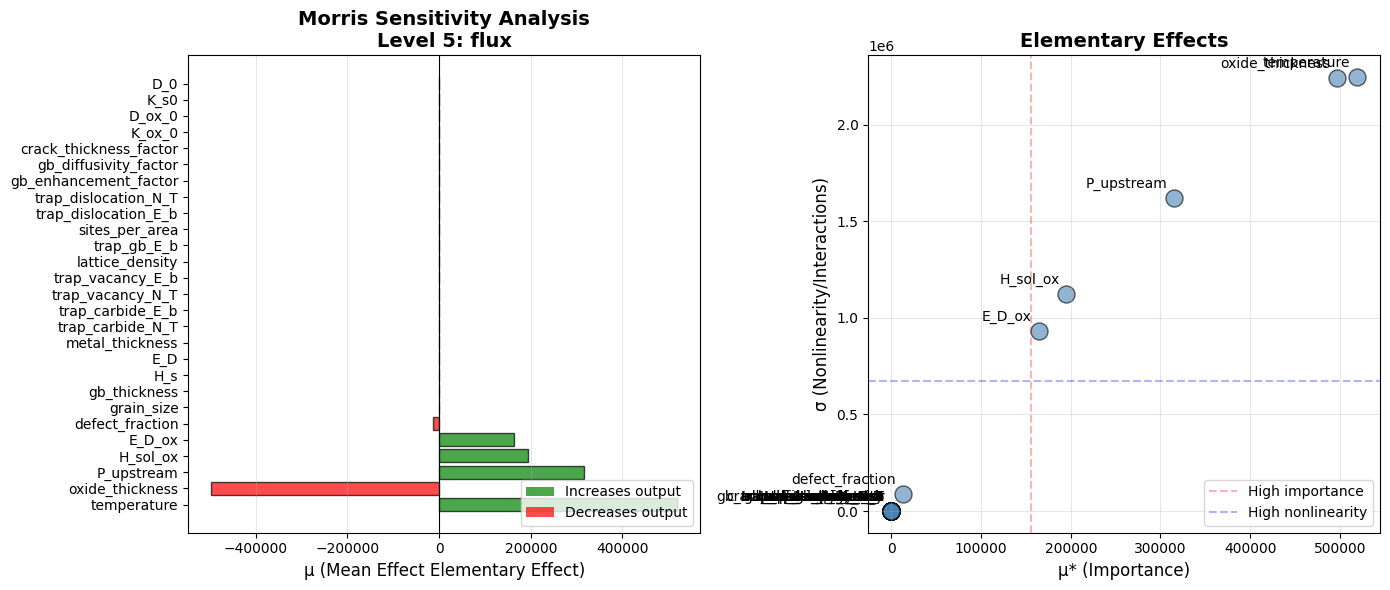


MORRIS SENSITIVITY RESULTS - Level 5: flux
             Parameter             μ           μ*            σ Direction
           temperature  5.188149e+05 5.188149e+05 2.247635e+06         ↑
       oxide_thickness -4.968514e+05 4.968514e+05 2.242419e+06         ↓
            P_upstream  3.151374e+05 3.151374e+05 1.618879e+06         ↑
              H_sol_ox  1.950185e+05 1.950652e+05 1.124878e+06         ↑
                E_D_ox  1.640938e+05 1.641687e+05 9.322712e+05         ↑
       defect_fraction -1.307704e+04 1.307704e+04 8.881007e+04         ↓
            grain_size  2.387154e-04 2.387154e-04 2.463541e-03         ↑
          gb_thickness -1.179500e-04 1.179500e-04 1.863371e-03         ↓
                   H_s  7.915494e-05 7.915494e-05 1.487039e-03         ↑
                   E_D  7.729859e-05 7.729859e-05 1.323863e-03         ↑
       metal_thickness  4.848632e-05 4.848632e-05 5.746995e-04         ↑
      trap_carbide_N_T  3.251729e-05 3.251729e-05 6.638588e-04         ↑
      t

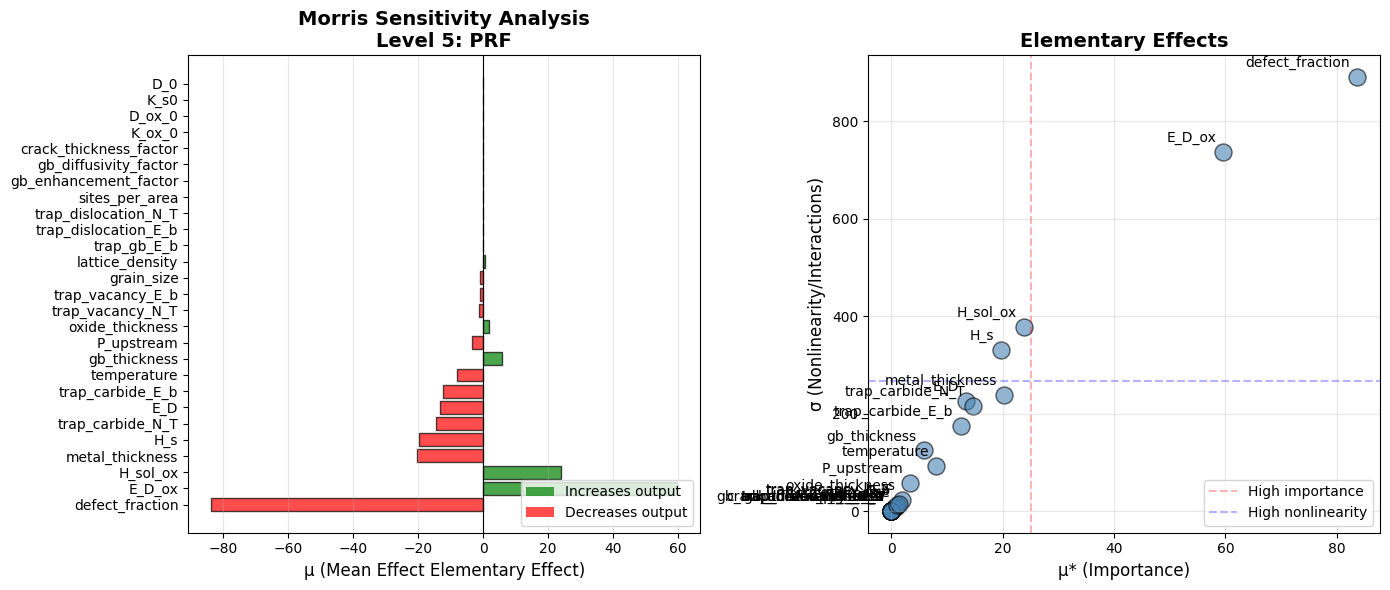


MORRIS SENSITIVITY RESULTS - Level 5: PRF
             Parameter             μ           μ*            σ Direction
       defect_fraction -8.358123e+01 8.358123e+01 8.907511e+02         ↓
                E_D_ox  5.964087e+01 5.964087e+01 7.361452e+02         ↑
              H_sol_ox  2.386003e+01 2.386004e+01 3.785286e+02         ↑
       metal_thickness -2.022369e+01 2.022369e+01 2.378119e+02         ↓
                   H_s -1.975338e+01 1.975339e+01 3.311517e+02         ↓
      trap_carbide_N_T -1.459401e+01 1.459402e+01 2.163742e+02         ↓
                   E_D -1.332736e+01 1.332736e+01 2.264308e+02         ↓
      trap_carbide_E_b -1.241414e+01 1.241414e+01 1.753497e+02         ↓
           temperature -8.012189e+00 8.012225e+00 9.234534e+01         ↓
          gb_thickness  5.779538e+00 5.779540e+00 1.243146e+02         ↑
            P_upstream -3.337026e+00 3.337031e+00 5.717347e+01         ↓
       oxide_thickness  1.982781e+00 1.982792e+00 2.294844e+01         ↑
      tr

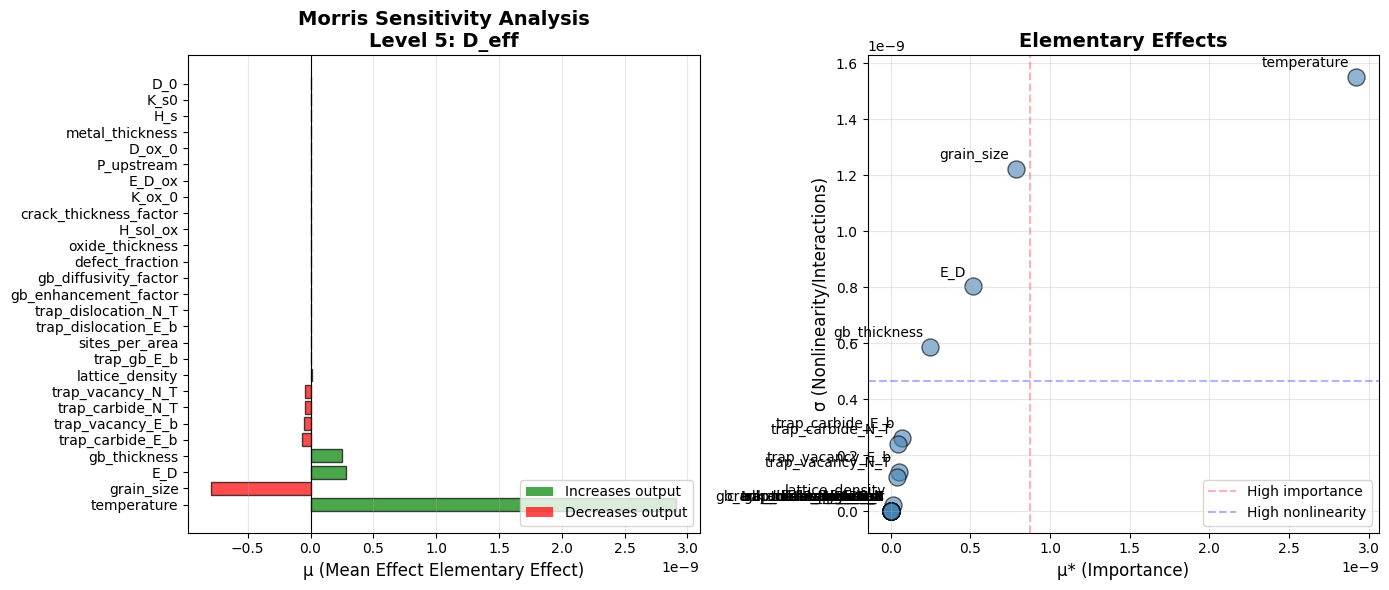


MORRIS SENSITIVITY RESULTS - Level 5: D_eff
             Parameter             μ           μ*            σ Direction
           temperature  2.911529e-09 2.918284e-09 1.550531e-09         ↑
            grain_size -7.885136e-10 7.885136e-10 1.223180e-09         ↓
                   E_D  2.808610e-10 5.175668e-10 8.023578e-10         ↑
          gb_thickness  2.487004e-10 2.487004e-10 5.870746e-10         ↑
      trap_carbide_E_b -6.813178e-11 6.813178e-11 2.613081e-10         ↓
      trap_vacancy_E_b -5.243615e-11 5.243615e-11 1.405464e-10         ↓
      trap_carbide_N_T -4.513935e-11 4.513935e-11 2.400707e-10         ↓
      trap_vacancy_N_T -4.168103e-11 4.168103e-11 1.200414e-10         ↓
       lattice_density  1.133918e-11 1.133918e-11 2.329518e-11         ↑
           trap_gb_E_b -3.767854e-19 3.767854e-19 1.471340e-18         ↓
        sites_per_area -3.609458e-19 3.609458e-19 1.373329e-18         ↓
  trap_dislocation_E_b -2.375657e-20 2.375657e-20 4.504548e-20         ↓
  trap

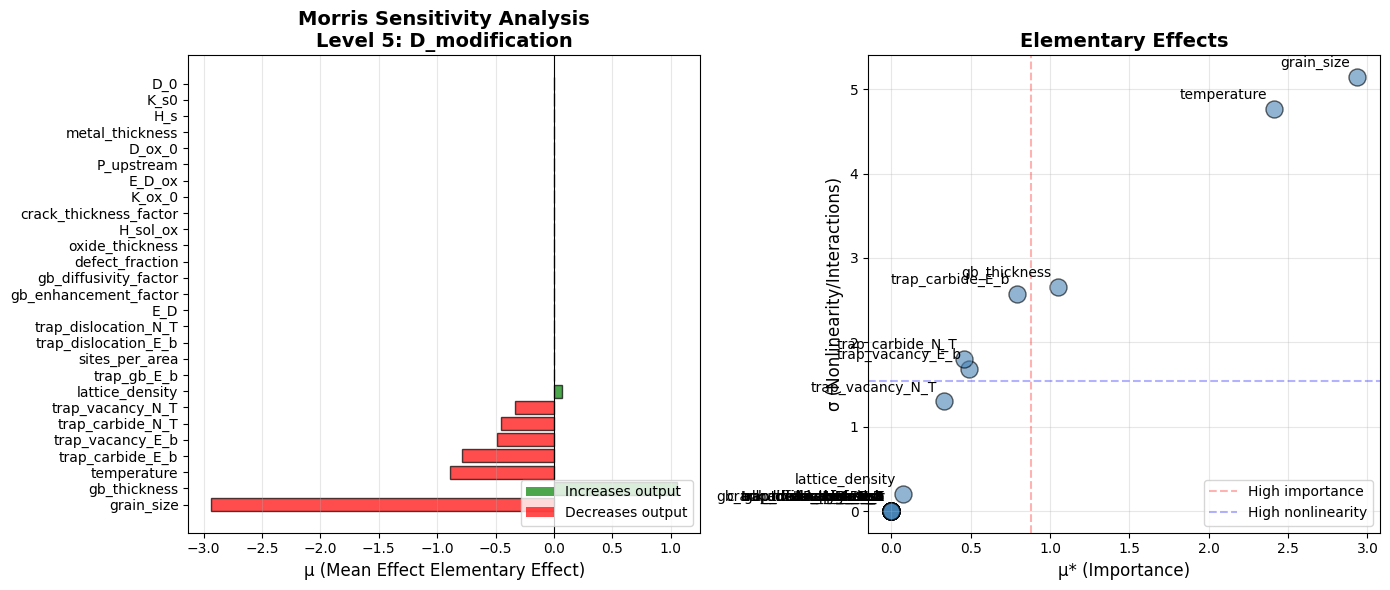


MORRIS SENSITIVITY RESULTS - Level 5: D_modification
             Parameter             μ           μ*            σ Direction
            grain_size -2.932449e+00 2.932449e+00 5.144304e+00         ↓
          gb_thickness  1.051602e+00 1.051602e+00 2.656563e+00         ↑
           temperature -8.864189e-01 2.411147e+00 4.765213e+00         ↓
      trap_carbide_E_b -7.914260e-01 7.914260e-01 2.567683e+00         ↓
      trap_vacancy_E_b -4.878156e-01 4.878156e-01 1.678382e+00         ↓
      trap_carbide_N_T -4.577751e-01 4.577751e-01 1.798297e+00         ↓
      trap_vacancy_N_T -3.306423e-01 3.306423e-01 1.298542e+00         ↓
       lattice_density  7.189324e-02 7.189324e-02 2.020207e-01         ↑
           trap_gb_E_b -6.757407e-09 6.757407e-09 4.970767e-08         ↓
        sites_per_area -5.375858e-09 5.375858e-09 6.267863e-08         ↓
  trap_dislocation_E_b -1.708032e-10 1.708032e-10 6.904962e-10         ↓
  trap_dislocation_N_T -1.013803e-10 1.013803e-10 4.085630e-10        

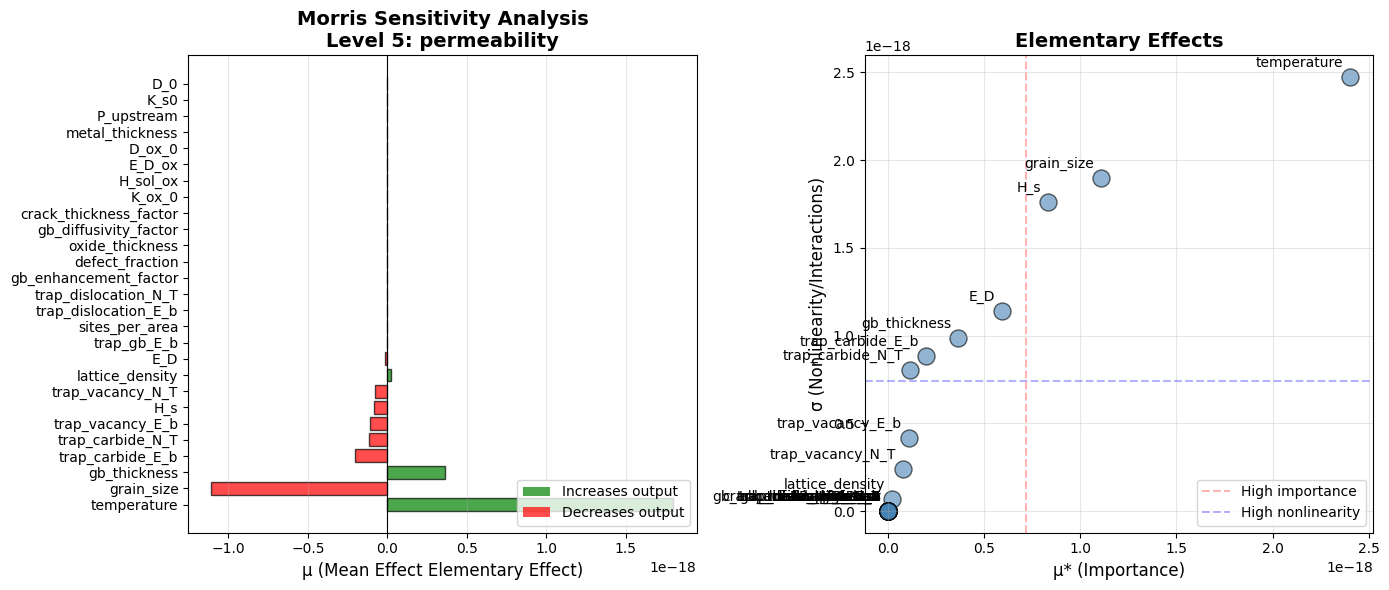


MORRIS SENSITIVITY RESULTS - Level 5: permeability
             Parameter             μ           μ*            σ Direction
           temperature  1.799725e-18 2.401059e-18 2.472920e-18         ↑
            grain_size -1.107129e-18 1.107129e-18 1.895154e-18         ↓
          gb_thickness  3.650117e-19 3.650117e-19 9.879504e-19         ↑
      trap_carbide_E_b -2.011662e-19 2.011662e-19 8.834502e-19         ↓
      trap_carbide_N_T -1.171193e-19 1.171193e-19 8.025972e-19         ↓
      trap_vacancy_E_b -1.103191e-19 1.103191e-19 4.141457e-19         ↓
                   H_s -8.258341e-20 8.332871e-19 1.761357e-18         ↓
      trap_vacancy_N_T -7.672864e-20 7.672864e-20 2.369354e-19         ↓
       lattice_density  2.247134e-20 2.247134e-20 6.798070e-20         ↑
                   E_D -1.557954e-20 5.928663e-19 1.141509e-18         ↓
           trap_gb_E_b -9.461630e-28 9.461630e-28 5.252409e-27         ↓
        sites_per_area -5.413684e-28 5.413684e-28 2.642835e-27         ↓

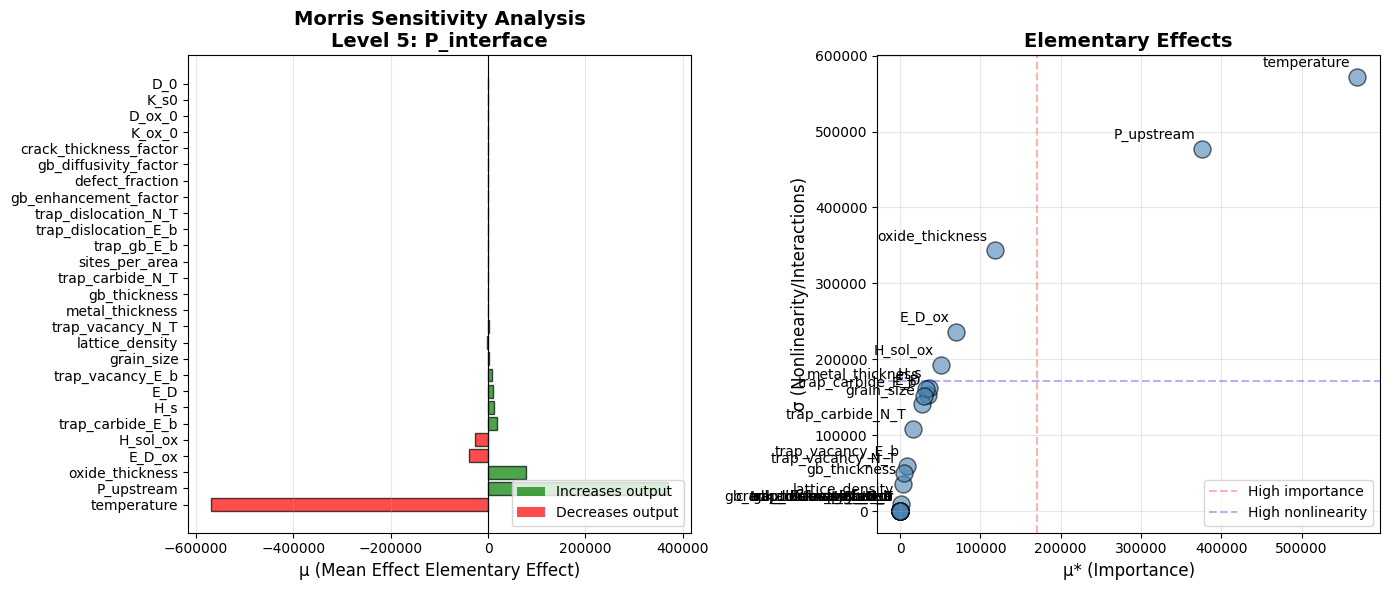


MORRIS SENSITIVITY RESULTS - Level 5: P_interface
             Parameter             μ           μ*             σ Direction
           temperature -5.691699e+05 5.691699e+05 571923.592896         ↓
            P_upstream  3.698866e+05 3.759346e+05 476834.290696         ↑
       oxide_thickness  7.852743e+04 1.175886e+05 343373.637033         ↑
                E_D_ox -4.017214e+04 7.021414e+04 235757.460298         ↓
              H_sol_ox -2.632924e+04 5.040124e+04 192146.973703         ↓
      trap_carbide_E_b  1.822231e+04 3.023431e+04 150922.217823         ↑
                   H_s  1.168856e+04 3.571256e+04 161612.983010         ↑
                   E_D  1.071154e+04 3.474154e+04 152703.355902         ↑
      trap_vacancy_E_b  8.380367e+03 8.386367e+03  59849.366974         ↑
            grain_size  1.763725e+03 2.779172e+04 140441.215316         ↑
       lattice_density -1.430764e+03 1.430764e+03   8695.319330         ↓
      trap_vacancy_N_T  1.288307e+03 5.290307e+03  50657.5431

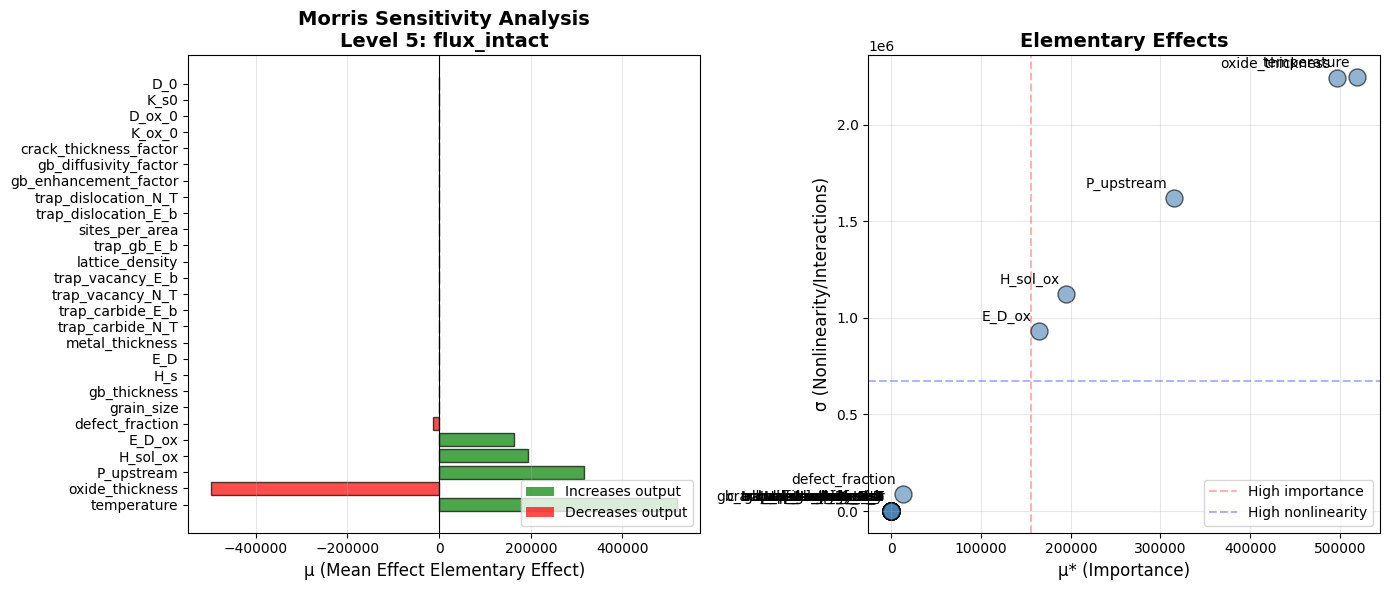


MORRIS SENSITIVITY RESULTS - Level 5: flux_intact
             Parameter             μ           μ*            σ Direction
           temperature  5.188149e+05 5.188149e+05 2.247635e+06         ↑
       oxide_thickness -4.968514e+05 4.968514e+05 2.242419e+06         ↓
            P_upstream  3.151374e+05 3.151374e+05 1.618879e+06         ↑
              H_sol_ox  1.950185e+05 1.950652e+05 1.124878e+06         ↑
                E_D_ox  1.640938e+05 1.641687e+05 9.322712e+05         ↑
       defect_fraction -1.307704e+04 1.307704e+04 8.881007e+04         ↓
            grain_size  2.387154e-04 2.387154e-04 2.463541e-03         ↑
          gb_thickness -1.179500e-04 1.179500e-04 1.863371e-03         ↓
                   H_s  7.915494e-05 7.915494e-05 1.487039e-03         ↑
                   E_D  7.729859e-05 7.729859e-05 1.323863e-03         ↑
       metal_thickness  4.848632e-05 4.848632e-05 5.746995e-04         ↑
      trap_carbide_N_T  3.251729e-05 3.251729e-05 6.638588e-04         ↑


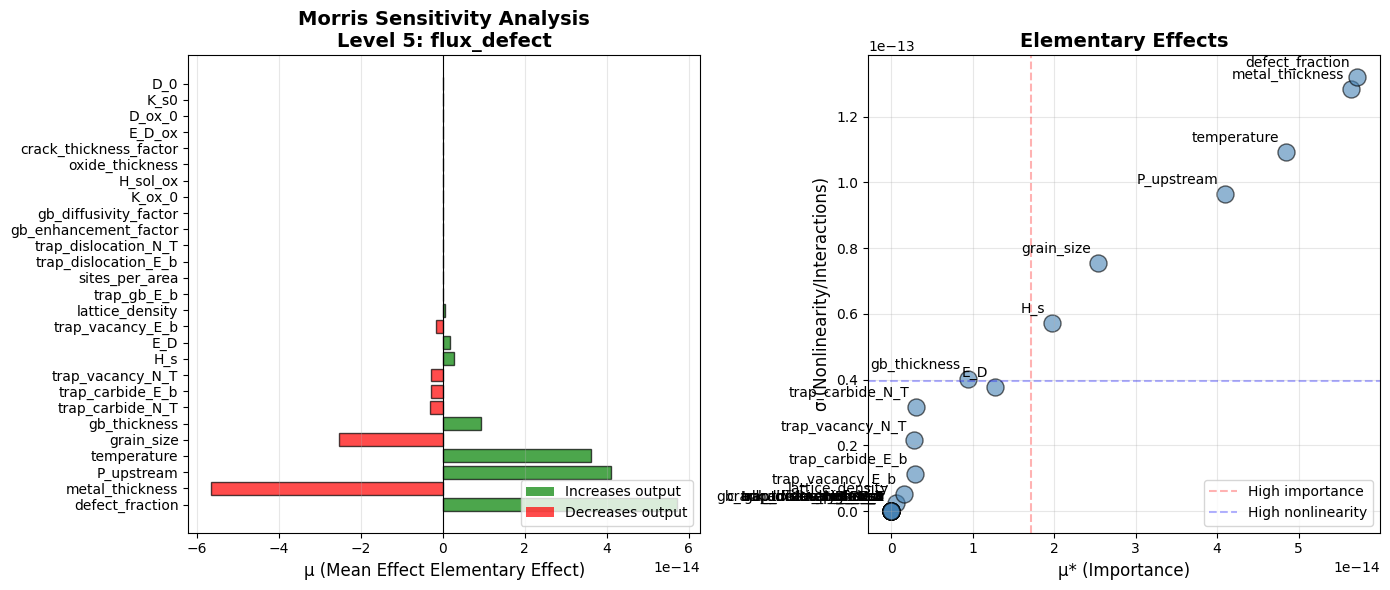


MORRIS SENSITIVITY RESULTS - Level 5: flux_defect
             Parameter             μ           μ*            σ Direction
       defect_fraction  5.713736e-14 5.713736e-14 1.320330e-13         ↑
       metal_thickness -5.639236e-14 5.639236e-14 1.284517e-13         ↓
            P_upstream  4.096578e-14 4.096578e-14 9.657448e-14         ↑
           temperature  3.609109e-14 4.841074e-14 1.091914e-13         ↑
            grain_size -2.539766e-14 2.539766e-14 7.537035e-14         ↓
          gb_thickness  9.348528e-15 9.348528e-15 4.030646e-14         ↑
      trap_carbide_N_T -3.057025e-15 3.057025e-15 3.153050e-14         ↓
      trap_carbide_E_b -2.864638e-15 2.864638e-15 1.118357e-14         ↓
      trap_vacancy_N_T -2.802105e-15 2.802105e-15 2.145759e-14         ↓
                   H_s  2.774056e-15 1.971155e-14 5.725729e-14         ↑
                   E_D  1.887122e-15 1.276356e-14 3.773100e-14         ↑
      trap_vacancy_E_b -1.554336e-15 1.554336e-15 5.305653e-15         ↓


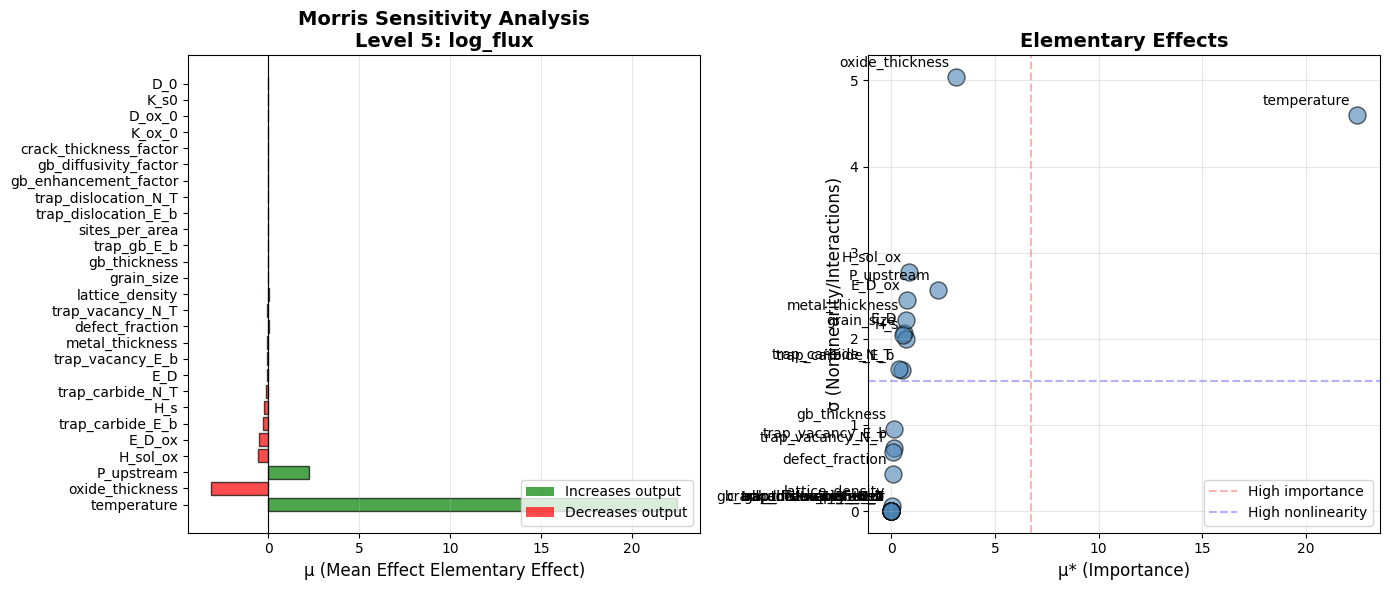


MORRIS SENSITIVITY RESULTS - Level 5: log_flux
             Parameter             μ           μ*            σ Direction
           temperature  2.246737e+01 2.246737e+01 4.596030e+00         ↑
       oxide_thickness -3.114468e+00 3.114468e+00 5.039215e+00         ↓
            P_upstream  2.239592e+00 2.239592e+00 2.562699e+00         ↑
              H_sol_ox -5.469292e-01 8.315058e-01 2.771449e+00         ↓
                E_D_ox -4.865902e-01 7.775859e-01 2.447004e+00         ↓
      trap_carbide_E_b -2.974586e-01 5.307256e-01 1.634124e+00         ↓
                   H_s -2.240607e-01 6.931641e-01 2.000088e+00         ↓
      trap_carbide_N_T -9.356211e-02 3.880235e-01 1.653026e+00         ↓
                   E_D -8.699356e-02 6.191569e-01 2.069285e+00         ↓
      trap_vacancy_E_b -7.914558e-02 1.387545e-01 7.334890e-01         ↓
       metal_thickness -7.060838e-02 7.020981e-01 2.221246e+00         ↓
       defect_fraction  5.124970e-02 1.013741e-01 4.343825e-01         ↑
   

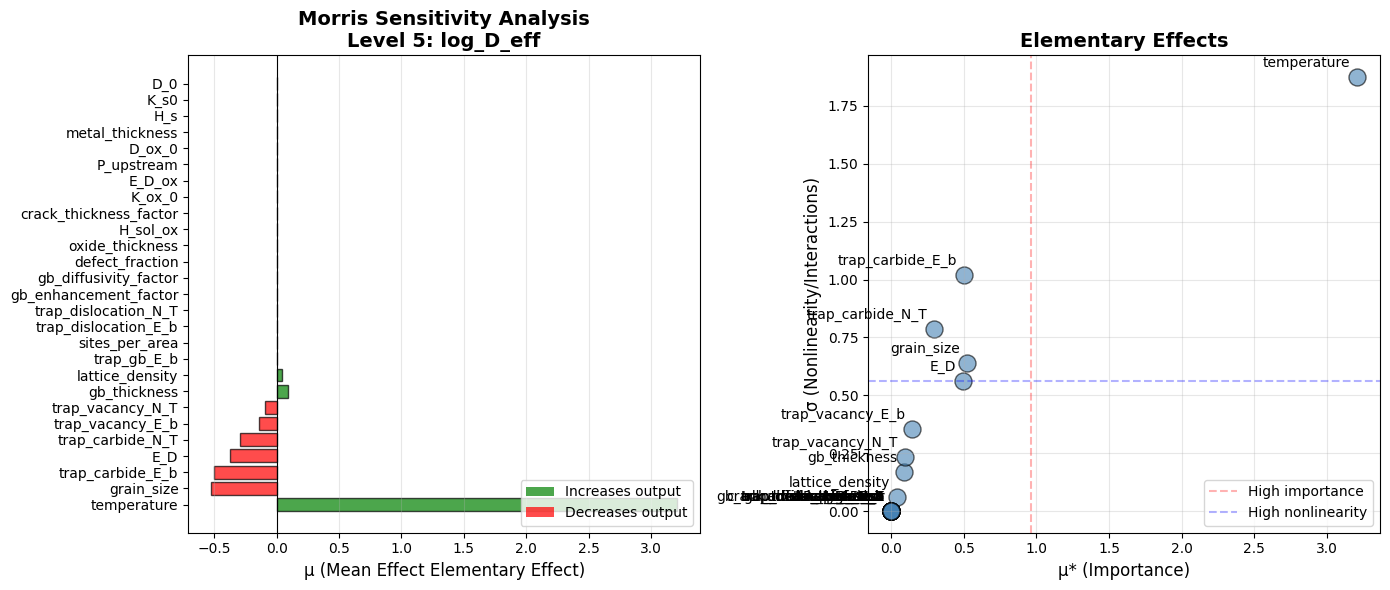


MORRIS SENSITIVITY RESULTS - Level 5: log_D_eff
             Parameter             μ           μ*            σ Direction
           temperature  3.206396e+00 3.207271e+00 1.874706e+00         ↑
            grain_size -5.221817e-01 5.221817e-01 6.378963e-01         ↓
      trap_carbide_E_b -5.002613e-01 5.002613e-01 1.018737e+00         ↓
                   E_D -3.761788e-01 4.963062e-01 5.610416e-01         ↓
      trap_carbide_N_T -2.939903e-01 2.939903e-01 7.875444e-01         ↓
      trap_vacancy_E_b -1.445674e-01 1.445674e-01 3.546922e-01         ↓
      trap_vacancy_N_T -9.318836e-02 9.318836e-02 2.351599e-01         ↓
          gb_thickness  8.814486e-02 8.814486e-02 1.681569e-01         ↑
       lattice_density  4.042870e-02 4.042870e-02 6.097188e-02         ↑
           trap_gb_E_b -3.492051e-10 3.492051e-10 2.206703e-09         ↓
        sites_per_area -2.390863e-10 2.390863e-10 2.206189e-09         ↓
  trap_dislocation_E_b -3.525592e-11 3.525592e-11 9.677886e-11         ↓
  

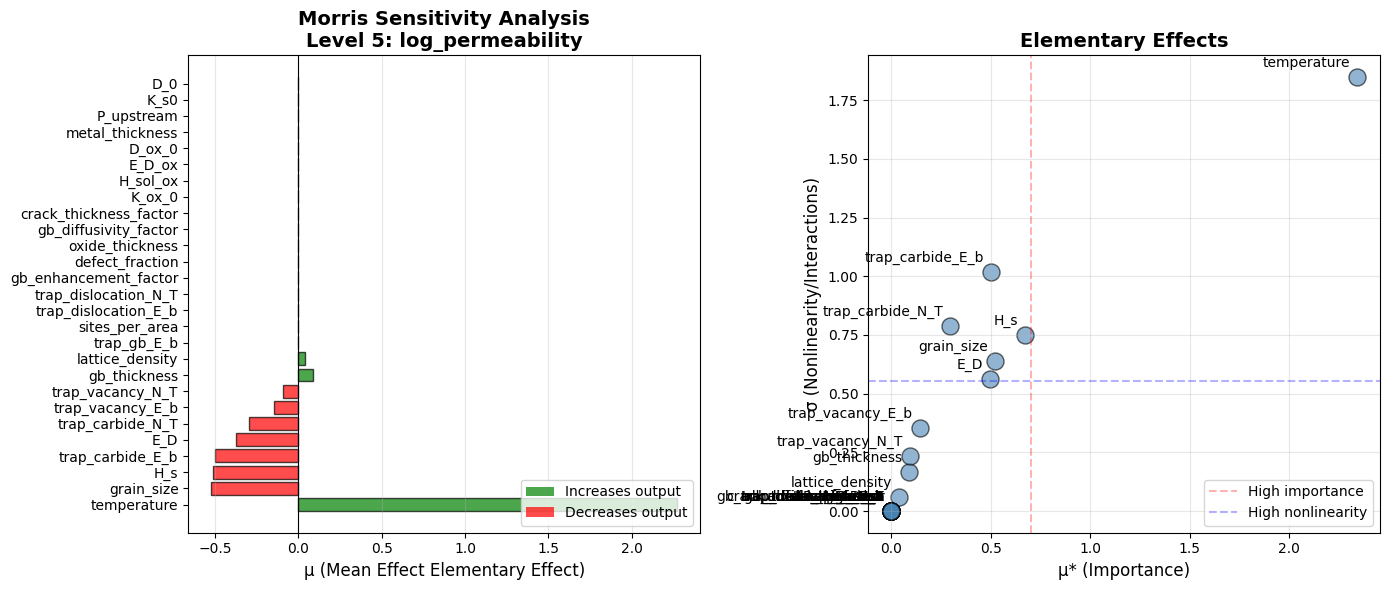


MORRIS SENSITIVITY RESULTS - Level 5: log_permeability
             Parameter             μ           μ*            σ Direction
           temperature  2.271489e+00 2.338151e+00 1.848894e+00         ↑
            grain_size -5.221817e-01 5.221817e-01 6.378963e-01         ↓
                   H_s -5.119187e-01 6.696432e-01 7.496194e-01         ↓
      trap_carbide_E_b -5.002613e-01 5.002613e-01 1.018737e+00         ↓
                   E_D -3.761788e-01 4.963062e-01 5.610416e-01         ↓
      trap_carbide_N_T -2.939903e-01 2.939903e-01 7.875444e-01         ↓
      trap_vacancy_E_b -1.445674e-01 1.445674e-01 3.546922e-01         ↓
      trap_vacancy_N_T -9.318836e-02 9.318836e-02 2.351599e-01         ↓
          gb_thickness  8.814486e-02 8.814486e-02 1.681569e-01         ↑
       lattice_density  4.042870e-02 4.042870e-02 6.097188e-02         ↑
           trap_gb_E_b -3.492050e-10 3.492050e-10 2.206702e-09         ↓
        sites_per_area -2.390862e-10 2.390862e-10 2.206189e-09      

In [6]:
# =============================================================================
# PLOT MORRIS RESULTS FOR ALL OUTPUTS
# =============================================================================

for output_metric in VALID_OUTPUT_METRICS_L5:
    print(f"\n{'='*70}")
    print(f"OUTPUT: {output_metric}")
    print(f"{'='*70}")
    
    Si = morris_results[output_metric]['Si']
    problem = morris_results[output_metric]['problem']
    
    plot_morris_results(Si, problem, f'Level 5: {output_metric}')

In [7]:
# =============================================================================
# PARAMETER IMPORTANCE RANKING ACROSS ALL 8 OUTPUTS
# =============================================================================
import pandas as pd

param_names = morris_results['flux']['problem']['names']

# Build DataFrame with μ* for each output
df_all = pd.DataFrame({'Parameter': param_names})

for output_metric in VALID_OUTPUT_METRICS_L5:
    df_all[f'μ*_{output_metric}'] = morris_results[output_metric]['Si']['mu_star']

# Normalize each column
for output_metric in VALID_OUTPUT_METRICS_L5:
    col = f'μ*_{output_metric}'
    max_val = df_all[col].max()
    if max_val > 0:
        df_all[f'{col}_norm'] = df_all[col] / max_val
    else:
        df_all[f'{col}_norm'] = 0

# Average normalized importance across all outputs
norm_cols = [f'μ*_{m}_norm' for m in VALID_OUTPUT_METRICS_L5]
df_all['Avg_Importance'] = df_all[norm_cols].mean(axis=1)
df_all = df_all.sort_values('Avg_Importance', ascending=False)

# Display summary
print("="*100)
print("PARAMETER IMPORTANCE RANKING (Morris μ* - All 8 Outputs)")
print("="*100)
display_cols = ['Parameter'] + [f'μ*_{m}' for m in VALID_OUTPUT_METRICS_L5] + ['Avg_Importance']
print(df_all[display_cols].to_string(index=False))
print("="*100)

# Top 10 for Sobol
top_10 = df_all.head(10)['Parameter'].tolist()
print(f"\n→ Top 10 parameters for focused Sobol analysis:")
for i, p in enumerate(top_10, 1):
    importance = df_all[df_all['Parameter'] == p]['Avg_Importance'].values[0]
    print(f"   {i:2d}. {p:<25s} (avg importance: {importance:.3f})")

PARAMETER IMPORTANCE RANKING (Morris μ* - All 8 Outputs)
             Parameter      μ*_flux       μ*_PRF     μ*_D_eff  μ*_D_modification  μ*_permeability  μ*_P_interface  μ*_flux_intact  μ*_flux_defect  μ*_log_flux  μ*_log_D_eff  μ*_log_permeability  Avg_Importance
           temperature 5.188149e+05 8.012225e+00 2.918284e-09       2.411147e+00     2.401059e-18    5.691699e+05    5.188149e+05    4.841074e-14 2.246737e+01  3.207271e+00         2.338151e+00    8.877601e-01
            P_upstream 3.151374e+05 3.337031e+00 0.000000e+00       0.000000e+00     0.000000e+00    3.759346e+05    3.151374e+05    4.096578e-14 2.239592e+00  0.000000e+00         0.000000e+00    2.483554e-01
            grain_size 2.387154e-04 9.172156e-01 7.885136e-10       2.932449e+00     1.107129e-18    2.779172e+04    2.387154e-04    2.539766e-14 5.439159e-01  5.221817e-01         5.221817e-01    2.405413e-01
       oxide_thickness 4.968514e+05 1.982792e+00 0.000000e+00       0.000000e+00     0.000000e+00    1.

### Sensitivity Heatmap

This heatmap shows which parameters affect which outputs:
- **Yellow/Light**: Low sensitivity (parameter has little effect)
- **Red/Dark**: High sensitivity (parameter strongly affects output)

**Interpretation:**
- A **row with all dark cells** = parameter affects everything (universally important)
- A **column with few dark cells** = that output is controlled by only a few parameters
- **Clusters of dark cells** reveal which parameter groups dominate specific outputs

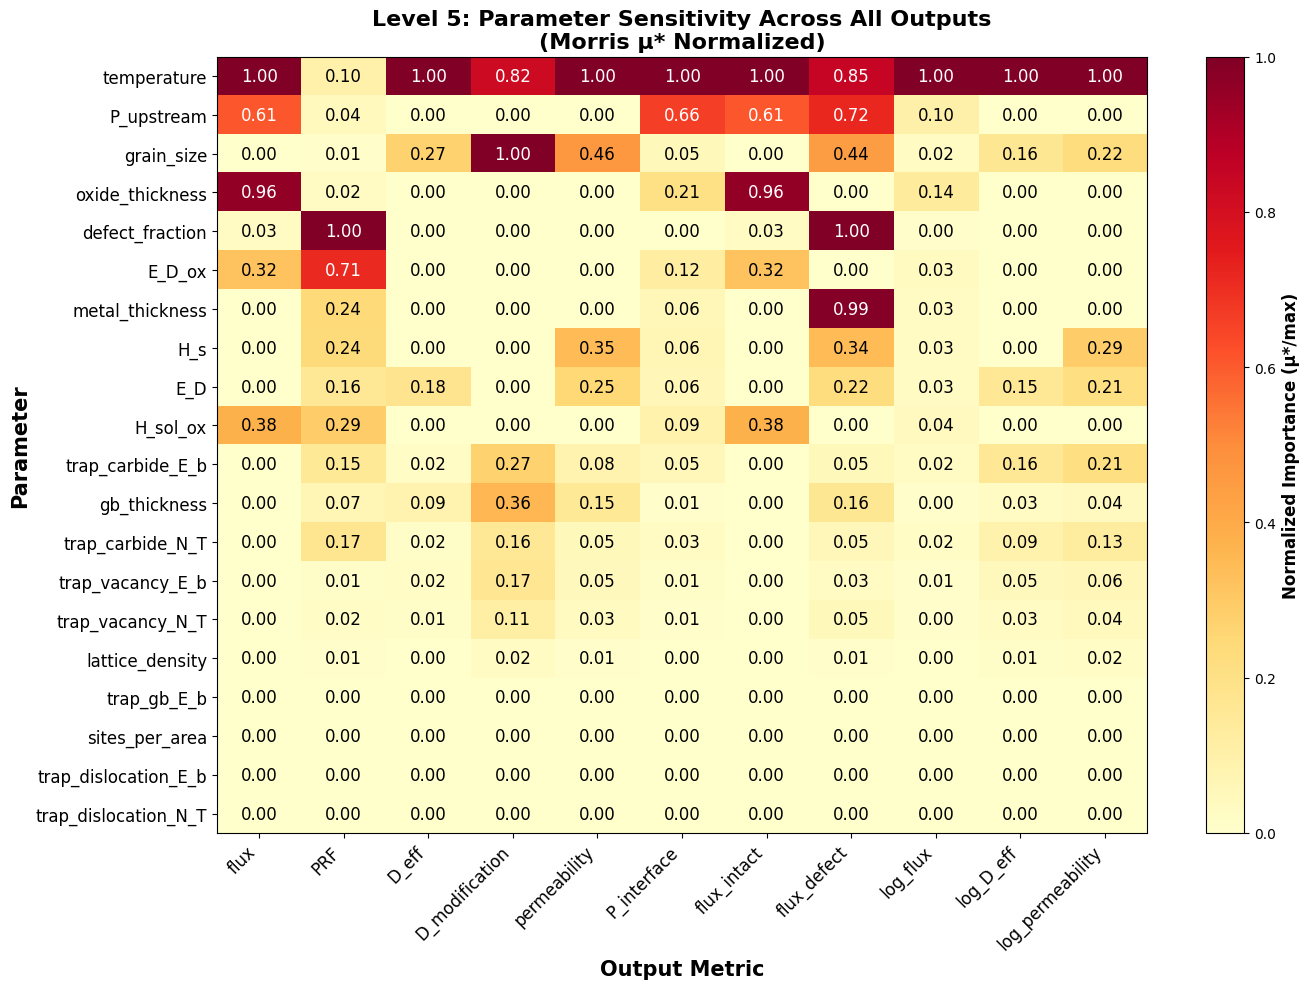

In [8]:
# =============================================================================
# HEATMAP: Parameter Importance Across All Outputs
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np

# Get top 20 parameters for visualization
top_20 = df_all.head(20)

# Extract normalized values for heatmap
heatmap_data = top_20[[f'μ*_{m}_norm' for m in VALID_OUTPUT_METRICS_L5]].values
param_labels = top_20['Parameter'].tolist()
output_labels = VALID_OUTPUT_METRICS_L5

fig, ax = plt.subplots(figsize=(14, 10))

im = ax.imshow(heatmap_data, cmap='YlOrRd', aspect='auto')

# Labels
ax.set_xticks(np.arange(len(output_labels)))
ax.set_yticks(np.arange(len(param_labels)))
ax.set_xticklabels(output_labels, rotation=45, ha='right', fontsize=12)
ax.set_yticklabels(param_labels, fontsize=12)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Normalized Importance (μ*/max)', fontsize=12, fontweight='bold')

# Annotate cells with values
for i in range(len(param_labels)):
    for j in range(len(output_labels)):
        val = heatmap_data[i, j]
        color = 'white' if val > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', color=color, fontsize=12)

ax.set_title('Level 5: Parameter Sensitivity Across All Outputs\n(Morris μ* Normalized)', 
             fontsize=16, fontweight='bold')
ax.set_xlabel('Output Metric', fontsize=15, fontweight='bold')
ax.set_ylabel('Parameter', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

# Sobol Analysis


Top 10 parameters for focused Sobol analysis:

    1. temperature               (avg importance: 0.780)
    2. E_D                       (avg importance: 0.540)
    3. H_s                       (avg importance: 0.511)
    4. D_0                       (avg importance: 0.412)
    5. K_s0                      (avg importance: 0.319)
    6. E_D_ox                    (avg importance: 0.253)
    7. P_upstream                (avg importance: 0.253)
    8. defect_fraction           (avg importance: 0.245)
    9. H_sol_ox                  (avg importance: 0.235)
   10. grain_size                (avg importance: 0.197)

In [9]:
# =============================================================================
# CREATE FOCUSED RANGES FOR SOBOL (Top 10 from Morris Heatmap)
# =============================================================================

# top_10 already exists from the ranking cell above
SOBOL_FOCUSED_RANGES = {param: SUGGESTED_RANGES_LEVEL5[param] for param in top_10}

print("="*70)
print("FOCUSED PARAMETER RANGES FOR SOBOL (Top 10 from Heatmap)")
print("="*70)
for i, (param, bounds) in enumerate(SOBOL_FOCUSED_RANGES.items(), 1):
    importance = df_all[df_all['Parameter'] == param]['Avg_Importance'].values[0]
    print(f"  {i:2d}. {param:<25s}: [{bounds[0]:.2e}, {bounds[1]:.2e}]  (μ*={importance:.3f})")
print("="*70)

FOCUSED PARAMETER RANGES FOR SOBOL (Top 10 from Heatmap)
   1. temperature              : [5.73e+02, 1.27e+03]  (μ*=0.888)
   2. P_upstream               : [1.00e+03, 1.00e+06]  (μ*=0.248)
   3. grain_size               : [1.00e-07, 1.00e-04]  (μ*=0.241)
   4. oxide_thickness          : [1.00e-08, 1.00e-05]  (μ*=0.208)
   5. defect_fraction          : [1.00e-04, 1.00e-01]  (μ*=0.187)
   6. E_D_ox                   : [1.20e+05, 2.00e+05]  (μ*=0.137)
   7. metal_thickness          : [5.00e-04, 5.00e-03]  (μ*=0.120)
   8. H_s                      : [-4.00e+04, 0.00e+00]  (μ*=0.119)
   9. E_D                      : [4.00e+04, 7.00e+04]  (μ*=0.115)
  10. H_sol_ox                 : [1.50e+05, 2.20e+05]  (μ*=0.106)


In [10]:
# =============================================================================
# SOBOL ANALYSIS: TOP 10 PARAMETERS (from Morris screening)
# =============================================================================
# Set random seeds for reproducibility


sobol_results = {}

for output_metric in VALID_OUTPUT_METRICS_L5:
    print(f"\n{'#'*70}")
    print(f"# Running Sobol for: {output_metric}")
    print(f"{'#'*70}")
    
    Si, problem, Y = sobol_sensitivity_level5(
        SOBOL_FOCUSED_RANGES,  # Use focused ranges from Morris top 10
        N_samples=1024,              # Samples (total = N × (2D + 2) = 22,528)
        output_metric=output_metric
        
        
    )
  
    sobol_results[output_metric] = {
        'Si': Si,
        'problem': problem,
        'Y': Y
    }

print("\n" + "="*70)
print("✓ Sobol analysis complete for all output metrics!")
print("="*70)


######################################################################
# Running Sobol for: flux
######################################################################

SOBOL SENSITIVITY ANALYSIS - LEVEL 5 (Complete Hierarchical Model)
Running 22528 Sobol samples (N_base=1024, 10 params)
Parameters: temperature, P_upstream, grain_size, oxide_thickness, defect_fraction, E_D_ox, metal_thickness, H_s, E_D, H_sol_ox
Output metric: flux
Second-order interactions: Yes
⏳ This may take a while...



/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:613: UserWarning: Temperature 574.0 K is far outside data range [873.1, 1273.2] K. Clamping to nearest data limit for interpolation.
  warnings.warn(
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1951: UserWarning: GB traps already in trap_list, not adding automatically
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.02×) and trapping (0.96×) nearly cancel. Small parameter changes could significantly affect results.
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.00×) and trapping (1.00×) nearly cancel. Small parameter changes could significantly affect results.
  warnings.warn(msg)
/Users/a

  Completed 2252/22528 samples (10%)


/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.13×) and trapping (0.99×) nearly cancel. Small parameter changes could significantly affect results.
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.13×) and trapping (1.00×) nearly cancel. Small parameter changes could significantly affect results.
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.27×) and trapping (0.98×) nearly cancel. Small parameter changes could significantly affect results.
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:613: UserWarning: Temperature 582.2 K is far outside data range [873.1, 1273.2] K. Clamping to 

  Completed 4504/22528 samples (20%)


...

  Completed 18016/22528 samples (80%)


/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.25×) and trapping (0.96×) nearly cancel. Small parameter changes could significantly affect results.
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.18×) and trapping (0.98×) nearly cancel. Small parameter changes could significantly affect results.
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.22×) and trapping (1.00×) nearly cancel. Small parameter changes could significantly affect results.
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.14×) and trapping (0.98×) nearly cancel. Small parameter c

  Completed 20268/22528 samples (90%)


/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.06×) and trapping (0.96×) nearly cancel. Small parameter changes could significantly affect results.
  warnings.warn(msg)


  Completed 22520/22528 samples (100%)
  Completed 22528/22528 samples (100%)

✓ All 22528 samples produced valid outputs

✓ Sobol analysis complete
  Output range: [7.52e-17, 1.35e+06]
  Output span: 17931796121877760442368.0× variation

  Parameter                       S1       ST    ST-S1
  ------------------------- -------- -------- --------
  oxide_thickness              0.003    0.048    0.045
  temperature                  0.006    0.014    0.009
  P_upstream                   0.000    0.008    0.007
  H_sol_ox                    -0.000    0.006    0.007
  E_D_ox                       0.000    0.003    0.002
  defect_fraction              0.000    0.000    0.000
  metal_thickness             -0.000    0.000    0.000
  H_s                         -0.000    0.000    0.000
  E_D                         -0.000    0.000    0.000
  grain_size                  -0.000    0.000    0.000

  Sum(S1) = 0.009 (should be ~1 if additive)
  Sum(ST) = 0.079 (>1 indicates interactions)

  Top pa


OUTPUT: flux


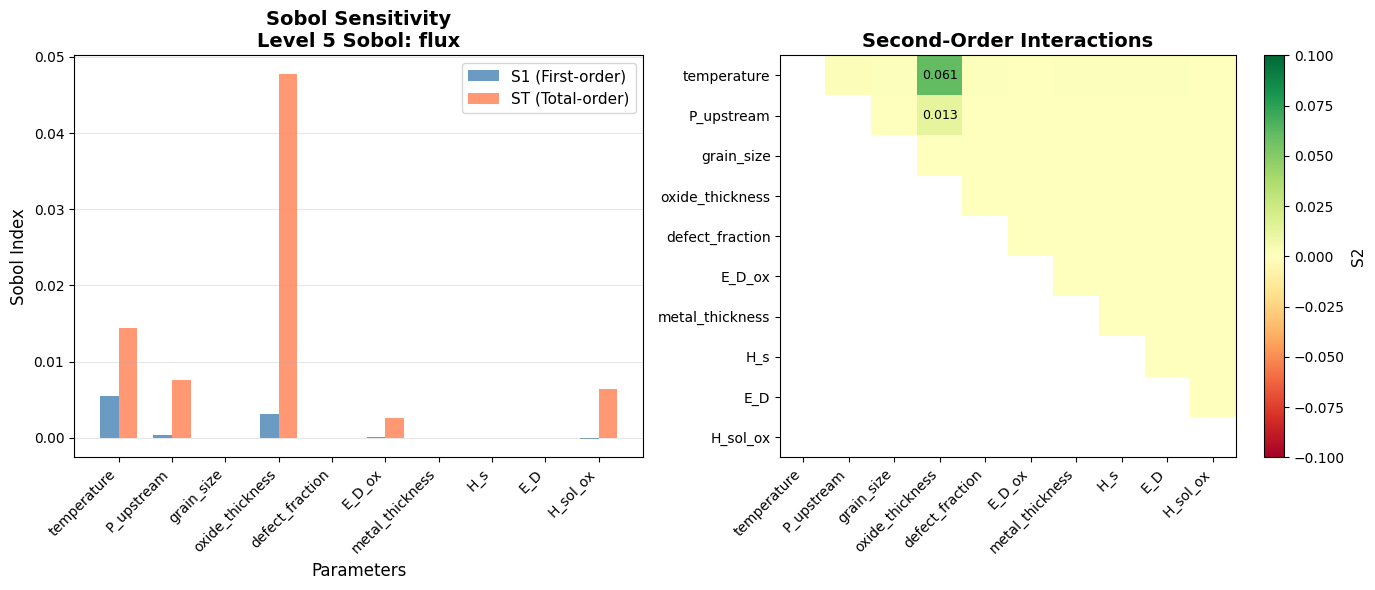


SOBOL SENSITIVITY RESULTS - Level 5 Sobol: flux
      Parameter            S1      S1_conf           ST      ST_conf  Interactions
    temperature  5.522226e-03 1.509069e-01 1.440178e-02 7.018500e-01  8.879556e-03
     P_upstream  3.448157e-04 1.689279e-02 7.535251e-03 3.715953e-01  7.190436e-03
     grain_size -1.687966e-12 2.271455e-10 1.085038e-18 1.460109e-16  1.687967e-12
oxide_thickness  3.153357e-03 1.696536e-01 4.780539e-02 2.621599e+00  4.465203e-02
defect_fraction  2.776710e-06 5.240465e-04 2.191595e-05 1.113703e-03  1.913924e-05
         E_D_ox  7.773889e-05 5.509719e-03 2.550324e-03 1.298950e-01  2.472585e-03
metal_thickness -9.785093e-12 1.170175e-09 4.445453e-17 3.035343e-15  9.785137e-12
            H_s -2.888531e-12 7.181129e-10 2.044179e-17 1.452391e-15  2.888551e-12
            E_D -2.752744e-13 2.595643e-10 7.844225e-18 5.606567e-16  2.752822e-13
       H_sol_ox -1.611179e-04 1.225930e-02 6.380762e-03 4.086880e-01  6.541880e-03

Interpretation:
  S1 : First-order ef

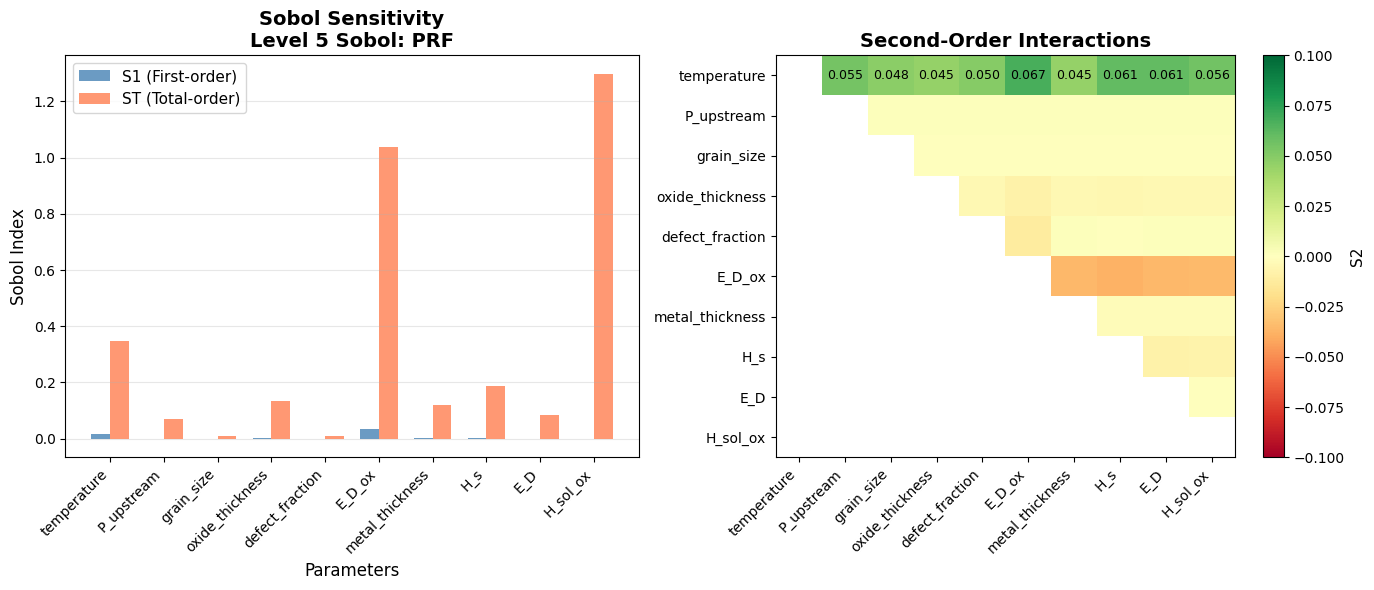


SOBOL SENSITIVITY RESULTS - Level 5 Sobol: PRF
      Parameter        S1  S1_conf       ST  ST_conf  Interactions
    temperature  0.018204 0.015178 0.348626 0.311509      0.330422
     P_upstream -0.000635 0.002127 0.069056 0.090673      0.069691
     grain_size  0.000318 0.000675 0.009883 0.016660      0.009565
oxide_thickness  0.001600 0.002715 0.134004 0.210633      0.132404
defect_fraction  0.000110 0.000994 0.011010 0.017984      0.010900
         E_D_ox  0.035426 0.065985 1.037644 2.440806      1.002218
metal_thickness  0.000738 0.002383 0.118640 0.142333      0.117902
            H_s  0.003046 0.006013 0.185716 0.196795      0.182670
            E_D  0.000293 0.002577 0.082824 0.128055      0.082532
       H_sol_ox -0.001052 0.011659 1.298821 3.163692      1.299872

Interpretation:
  S1 : First-order effect (direct influence)
  ST : Total-order effect (direct + interactions)
  ST-S1 : Pure interaction effects

Top 3 Most Influential Parameters:
  H_sol_ox: ST = 1.299 (S1 = -0.

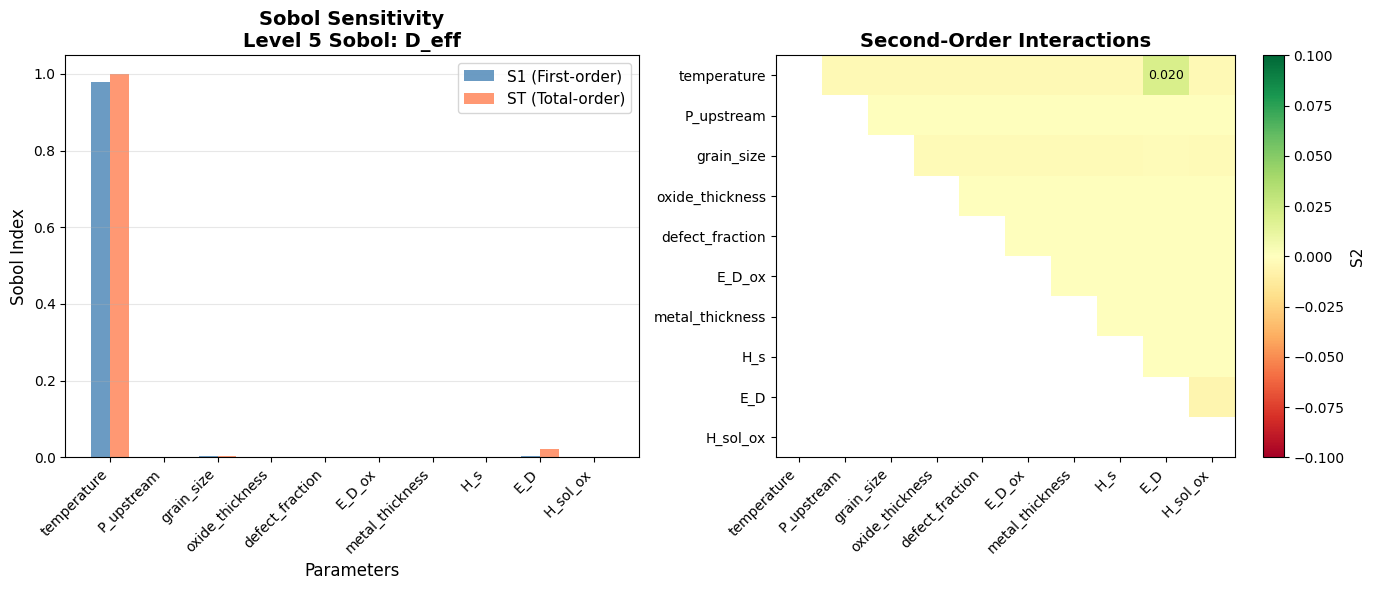


SOBOL SENSITIVITY RESULTS - Level 5 Sobol: D_eff
      Parameter       S1  S1_conf       ST  ST_conf  Interactions
    temperature 0.977909 0.082378 0.998414 0.065718      0.020505
     P_upstream 0.000000 0.000000 0.000000 0.000000      0.000000
     grain_size 0.002252 0.003244 0.002873 0.003339      0.000621
oxide_thickness 0.000000 0.000000 0.000000 0.000000      0.000000
defect_fraction 0.000000 0.000000 0.000000 0.000000      0.000000
         E_D_ox 0.000000 0.000000 0.000000 0.000000      0.000000
metal_thickness 0.000000 0.000000 0.000000 0.000000      0.000000
            H_s 0.000000 0.000000 0.000000 0.000000      0.000000
            E_D 0.003791 0.015135 0.021638 0.004383      0.017847
       H_sol_ox 0.000000 0.000000 0.000000 0.000000      0.000000

Interpretation:
  S1 : First-order effect (direct influence)
  ST : Total-order effect (direct + interactions)
  ST-S1 : Pure interaction effects

Top 3 Most Influential Parameters:
  temperature: ST = 0.998 (S1 = 0.978)
  

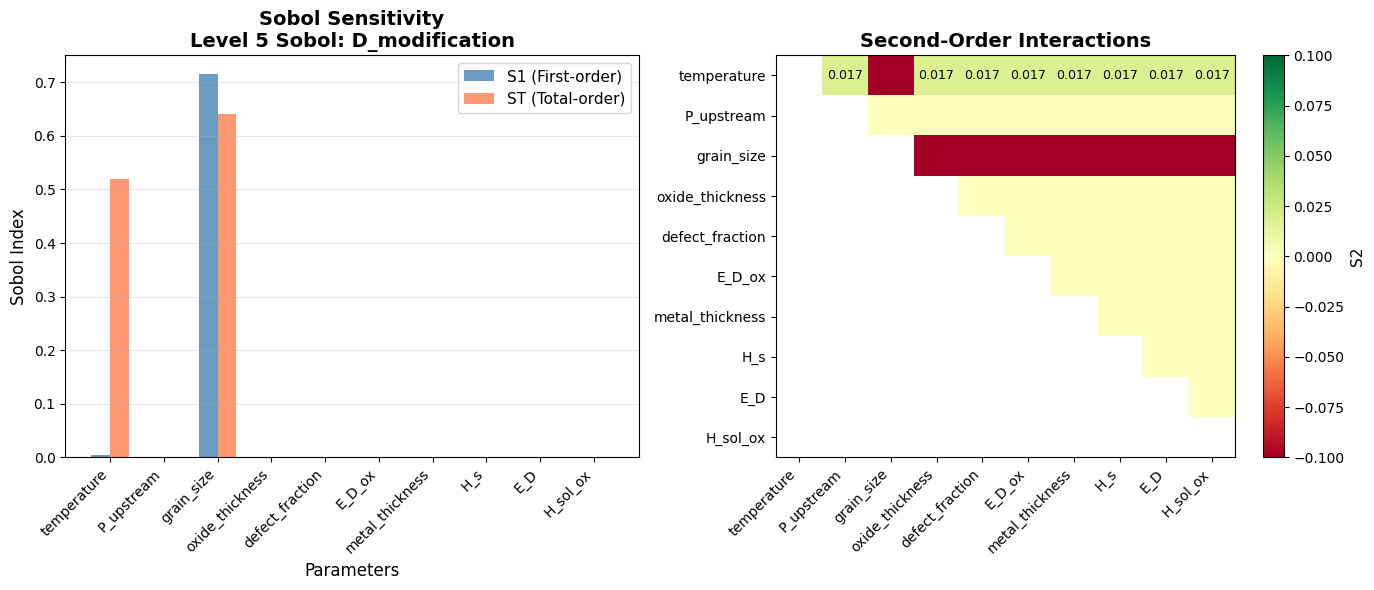


SOBOL SENSITIVITY RESULTS - Level 5 Sobol: D_modification
      Parameter            S1      S1_conf           ST      ST_conf  Interactions
    temperature  4.756672e-03 1.684348e-02 5.190396e-01 1.915103e+00  5.142829e-01
     P_upstream  0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00  0.000000e+00
     grain_size  7.146679e-01 3.821071e-01 6.404639e-01 5.491952e-01 -7.420403e-02
oxide_thickness  0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00  0.000000e+00
defect_fraction  0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00  0.000000e+00
         E_D_ox  0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00  0.000000e+00
metal_thickness  0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00  0.000000e+00
            H_s  0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00  0.000000e+00
            E_D -5.933486e-17 1.052934e-16 8.589273e-31 1.906581e-30  5.933486e-17
       H_sol_ox  0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00  0.000000e+00

Interpretation:
  S1 : Firs

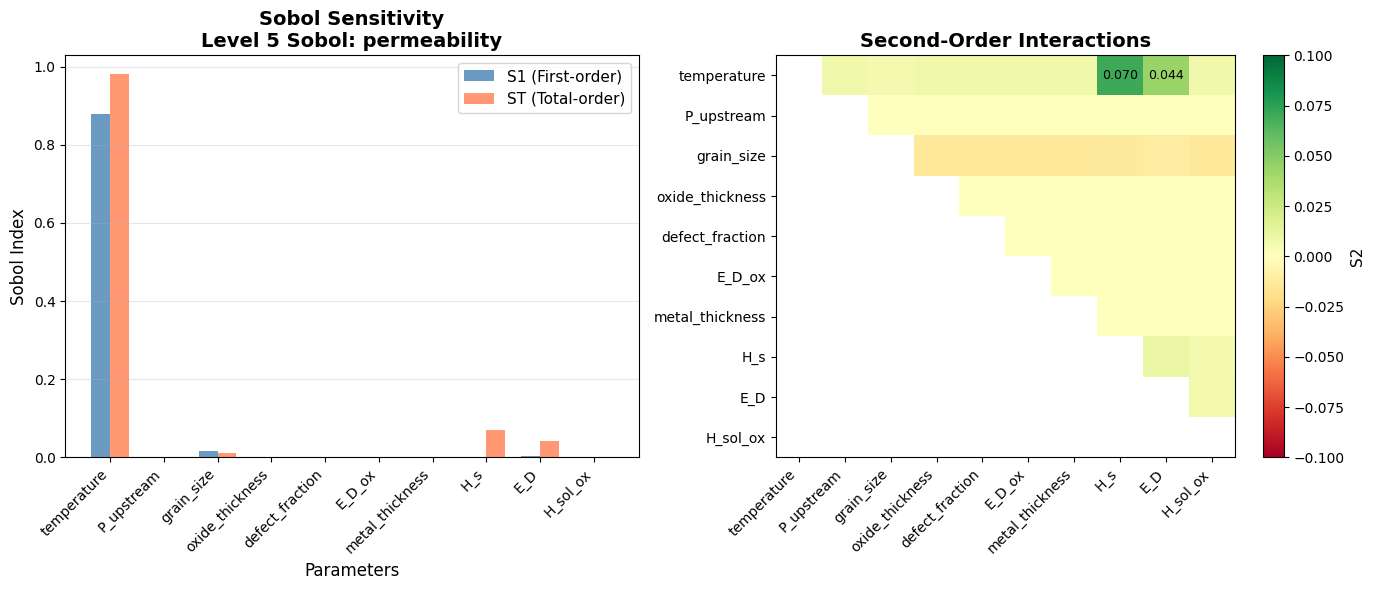


SOBOL SENSITIVITY RESULTS - Level 5 Sobol: permeability
      Parameter       S1  S1_conf       ST  ST_conf  Interactions
    temperature 0.878014 0.075264 0.979949 0.087717      0.101934
     P_upstream 0.000000 0.000000 0.000000 0.000000      0.000000
     grain_size 0.015152 0.018776 0.010671 0.012041     -0.004482
oxide_thickness 0.000000 0.000000 0.000000 0.000000      0.000000
defect_fraction 0.000000 0.000000 0.000000 0.000000      0.000000
         E_D_ox 0.000000 0.000000 0.000000 0.000000      0.000000
metal_thickness 0.000000 0.000000 0.000000 0.000000      0.000000
            H_s 0.001193 0.023366 0.070620 0.009860      0.069427
            E_D 0.002661 0.021048 0.042779 0.006495      0.040118
       H_sol_ox 0.000000 0.000000 0.000000 0.000000      0.000000

Interpretation:
  S1 : First-order effect (direct influence)
  ST : Total-order effect (direct + interactions)
  ST-S1 : Pure interaction effects

Top 3 Most Influential Parameters:
  temperature: ST = 0.980 (S1 = 0.

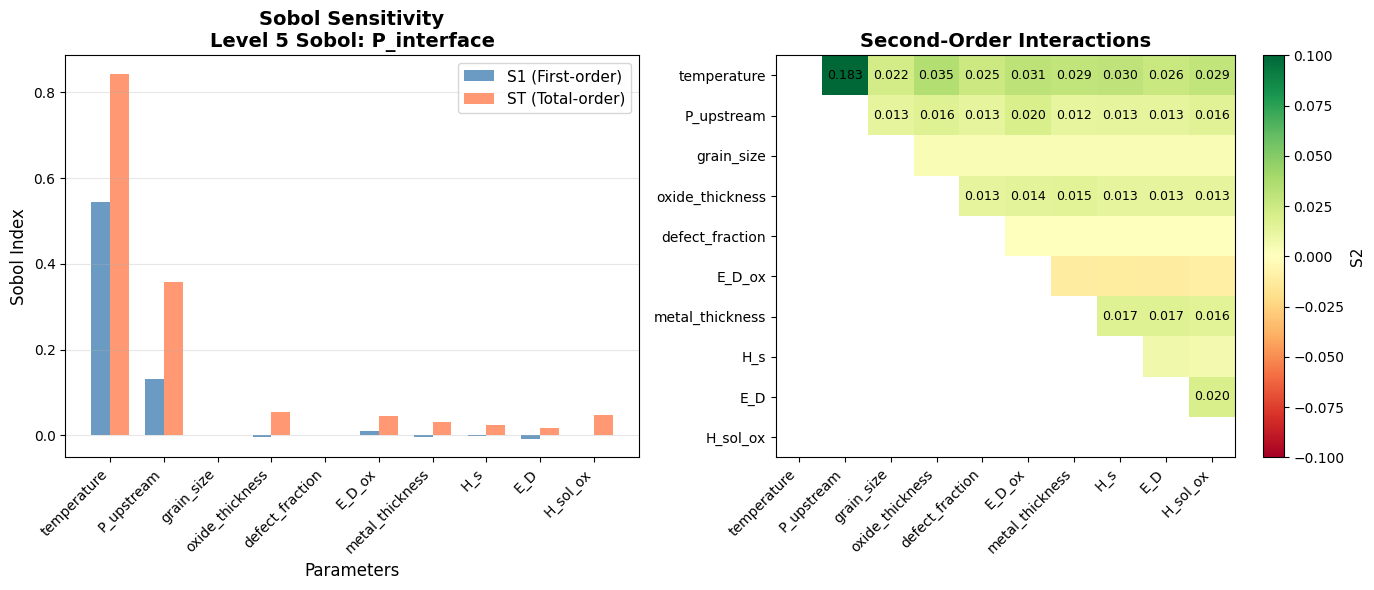


SOBOL SENSITIVITY RESULTS - Level 5 Sobol: P_interface
      Parameter        S1  S1_conf       ST  ST_conf  Interactions
    temperature  0.544511 0.067434 0.843820 0.088086      0.299309
     P_upstream  0.132352 0.045475 0.357128 0.039430      0.224775
     grain_size  0.000759 0.001867 0.000883 0.001868      0.000123
oxide_thickness -0.003780 0.012244 0.053615 0.028221      0.057395
defect_fraction  0.000000 0.000000 0.000000 0.000000      0.000000
         E_D_ox  0.009887 0.011628 0.044957 0.020659      0.035070
metal_thickness -0.003971 0.013858 0.031785 0.021127      0.035756
            H_s -0.001784 0.012764 0.024472 0.016997      0.026256
            E_D -0.008626 0.014759 0.016920 0.011465      0.025546
       H_sol_ox  0.000351 0.015438 0.048266 0.028698      0.047914

Interpretation:
  S1 : First-order effect (direct influence)
  ST : Total-order effect (direct + interactions)
  ST-S1 : Pure interaction effects

Top 3 Most Influential Parameters:
  temperature: ST = 0.84

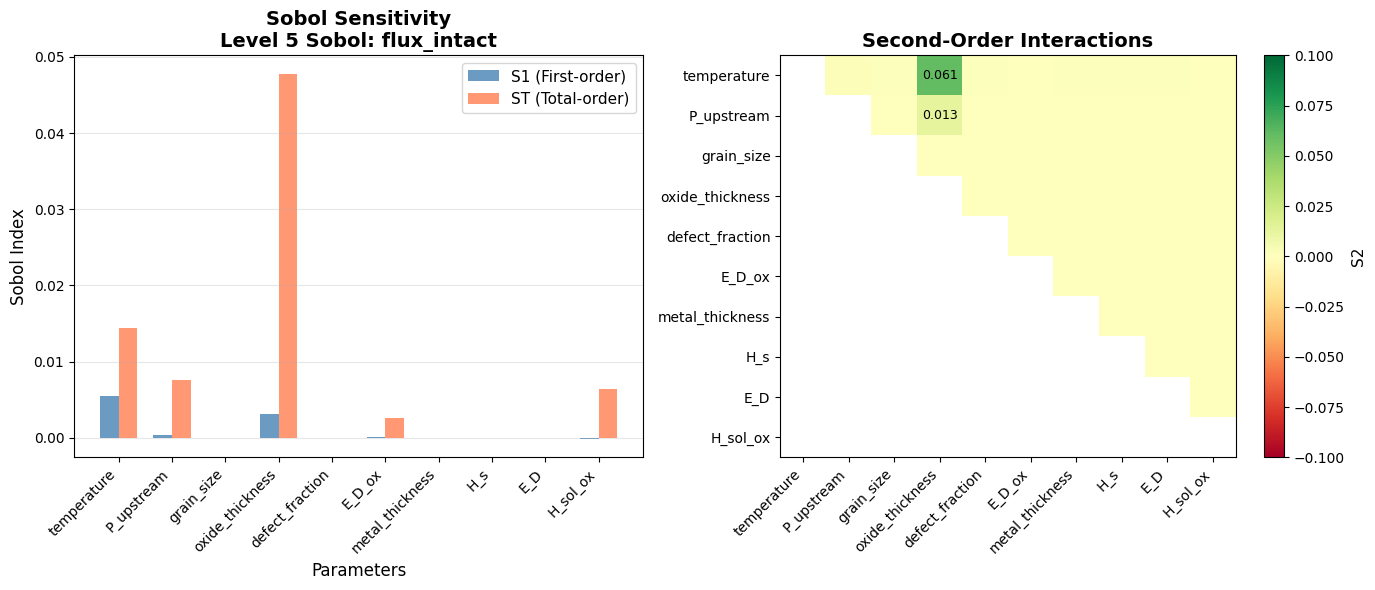


SOBOL SENSITIVITY RESULTS - Level 5 Sobol: flux_intact
      Parameter            S1      S1_conf           ST      ST_conf  Interactions
    temperature  5.522226e-03 1.509069e-01 1.440178e-02 7.018500e-01  8.879556e-03
     P_upstream  3.448157e-04 1.689279e-02 7.535251e-03 3.715953e-01  7.190436e-03
     grain_size -1.687966e-12 2.271455e-10 1.085038e-18 1.460109e-16  1.687967e-12
oxide_thickness  3.153357e-03 1.696536e-01 4.780539e-02 2.621599e+00  4.465203e-02
defect_fraction  2.776710e-06 5.240465e-04 2.191595e-05 1.113703e-03  1.913924e-05
         E_D_ox  7.773889e-05 5.509719e-03 2.550324e-03 1.298950e-01  2.472585e-03
metal_thickness -9.785093e-12 1.170175e-09 4.445453e-17 3.035343e-15  9.785137e-12
            H_s -2.888531e-12 7.181129e-10 2.044179e-17 1.452391e-15  2.888551e-12
            E_D -2.752744e-13 2.595643e-10 7.844225e-18 5.606567e-16  2.752822e-13
       H_sol_ox -1.611179e-04 1.225930e-02 6.380762e-03 4.086880e-01  6.541880e-03

Interpretation:
  S1 : First-o

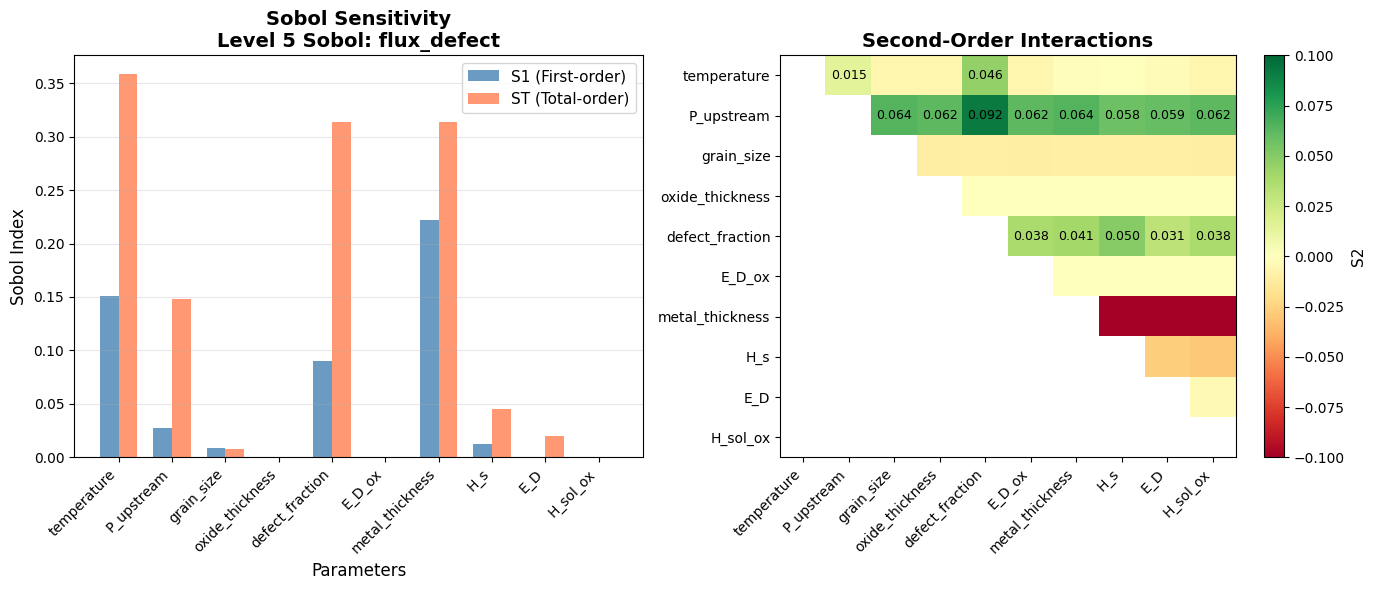


SOBOL SENSITIVITY RESULTS - Level 5 Sobol: flux_defect
      Parameter            S1  S1_conf       ST  ST_conf  Interactions
    temperature  1.509667e-01 0.041471 0.358265 0.106166      0.207299
     P_upstream  2.697851e-02 0.043482 0.148379 0.096908      0.121401
     grain_size  8.870085e-03 0.016550 0.007546 0.011751     -0.001324
oxide_thickness  0.000000e+00 0.000000 0.000000 0.000000      0.000000
defect_fraction  9.051546e-02 0.042514 0.313684 0.119661      0.223169
         E_D_ox  0.000000e+00 0.000000 0.000000 0.000000      0.000000
metal_thickness  2.223742e-01 0.090707 0.313896 0.098473      0.091522
            H_s  1.208381e-02 0.012572 0.045351 0.020354      0.033267
            E_D -1.549799e-07 0.007489 0.019532 0.008866      0.019533
       H_sol_ox  0.000000e+00 0.000000 0.000000 0.000000      0.000000

Interpretation:
  S1 : First-order effect (direct influence)
  ST : Total-order effect (direct + interactions)
  ST-S1 : Pure interaction effects

Top 3 Most Infl

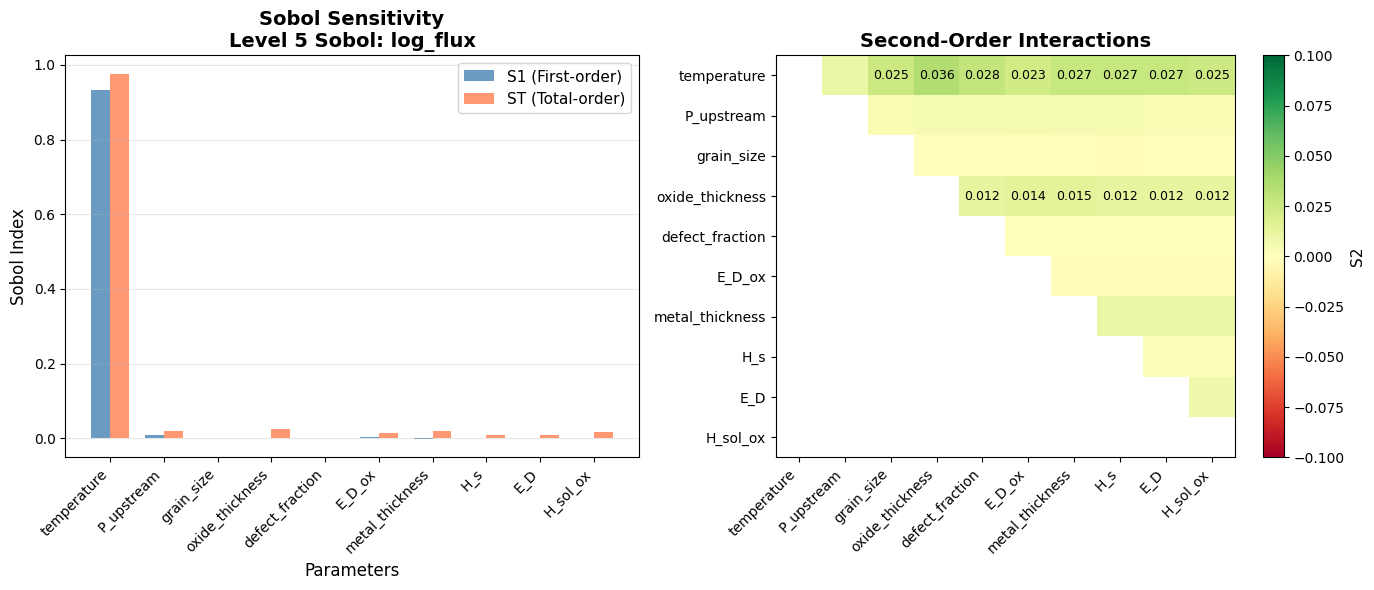


SOBOL SENSITIVITY RESULTS - Level 5 Sobol: log_flux
      Parameter        S1  S1_conf       ST      ST_conf  Interactions
    temperature  0.931500 0.059008 0.976615 5.994153e-02      0.045115
     P_upstream  0.009039 0.013119 0.020075 7.508690e-03      0.011036
     grain_size  0.001425 0.002801 0.000953 2.042171e-03     -0.000471
oxide_thickness  0.001398 0.014245 0.025732 1.044376e-02      0.024335
defect_fraction -0.000004 0.000158 0.000003 7.446368e-07      0.000006
         E_D_ox  0.004305 0.009224 0.013102 5.683478e-03      0.008797
metal_thickness -0.002213 0.011464 0.020375 9.059371e-03      0.022588
            H_s -0.000121 0.008719 0.008871 5.563809e-03      0.008992
            E_D -0.000758 0.008034 0.007773 4.668107e-03      0.008530
       H_sol_ox -0.000332 0.011142 0.016713 8.064686e-03      0.017045

Interpretation:
  S1 : First-order effect (direct influence)
  ST : Total-order effect (direct + interactions)
  ST-S1 : Pure interaction effects

Top 3 Most Influen

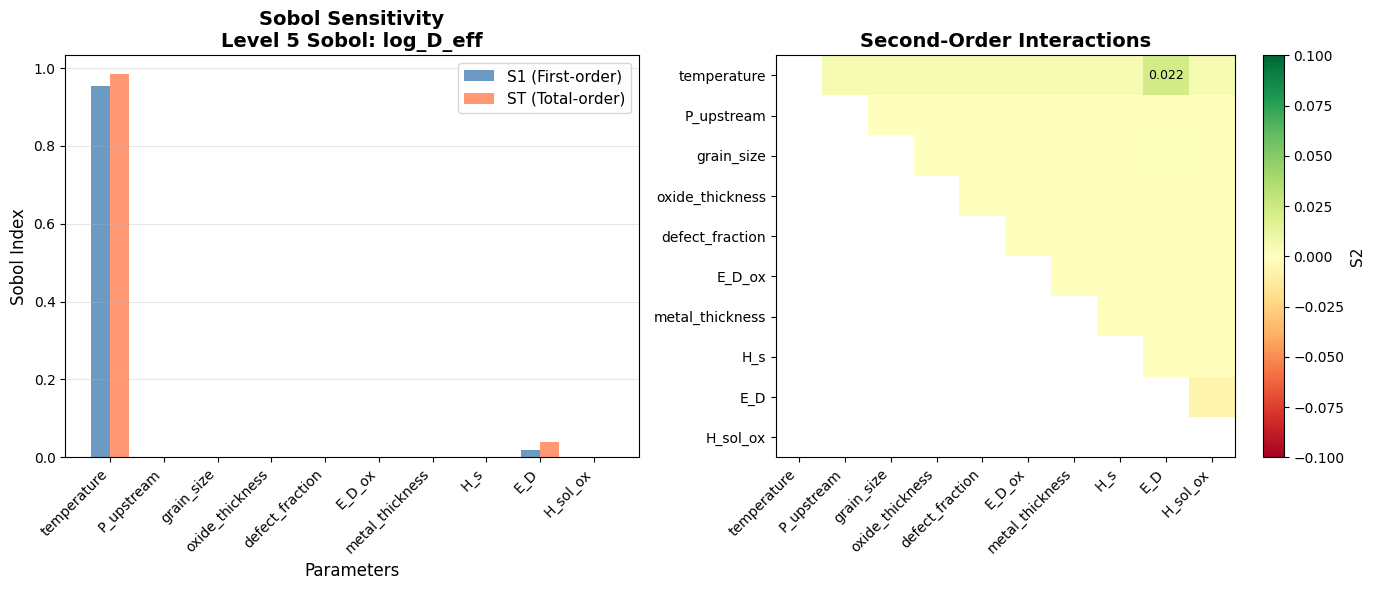


SOBOL SENSITIVITY RESULTS - Level 5 Sobol: log_D_eff
      Parameter       S1  S1_conf       ST  ST_conf  Interactions
    temperature 0.953205 0.081369 0.983378 0.063904      0.030174
     P_upstream 0.000000 0.000000 0.000000 0.000000      0.000000
     grain_size 0.001610 0.002882 0.001910 0.001073      0.000300
oxide_thickness 0.000000 0.000000 0.000000 0.000000      0.000000
defect_fraction 0.000000 0.000000 0.000000 0.000000      0.000000
         E_D_ox 0.000000 0.000000 0.000000 0.000000      0.000000
metal_thickness 0.000000 0.000000 0.000000 0.000000      0.000000
            H_s 0.000000 0.000000 0.000000 0.000000      0.000000
            E_D 0.018090 0.017734 0.038435 0.005911      0.020345
       H_sol_ox 0.000000 0.000000 0.000000 0.000000      0.000000

Interpretation:
  S1 : First-order effect (direct influence)
  ST : Total-order effect (direct + interactions)
  ST-S1 : Pure interaction effects

Top 3 Most Influential Parameters:
  temperature: ST = 0.983 (S1 = 0.953

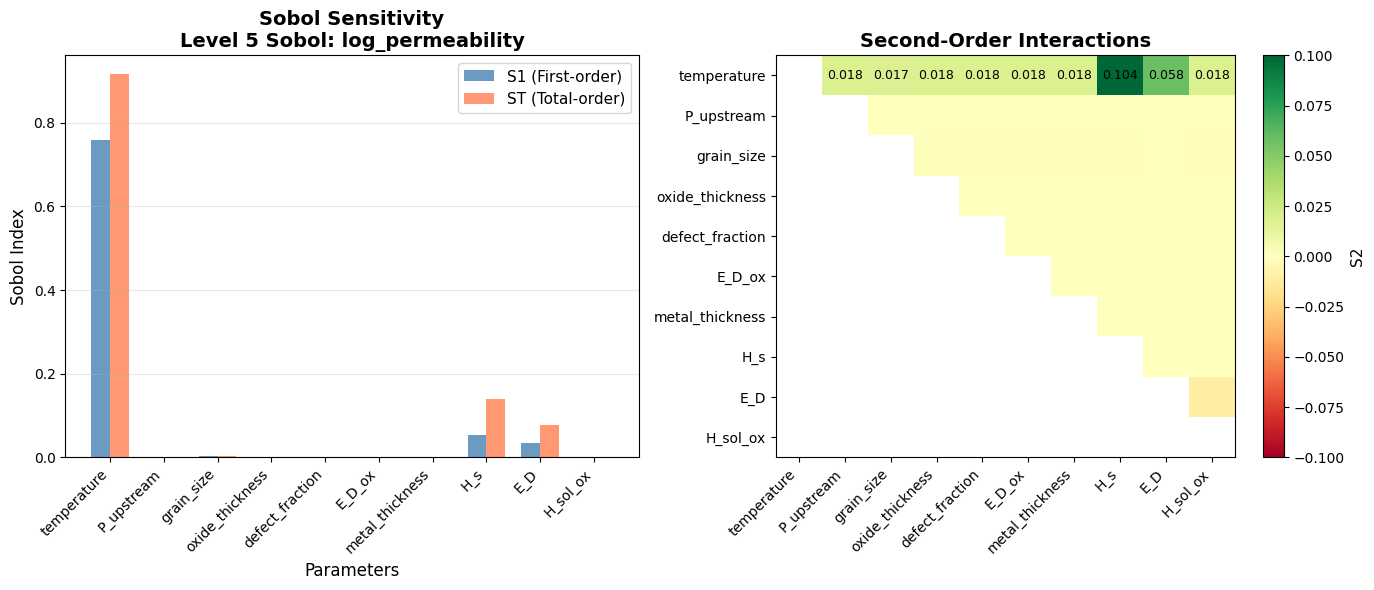


SOBOL SENSITIVITY RESULTS - Level 5 Sobol: log_permeability
      Parameter       S1  S1_conf       ST  ST_conf  Interactions
    temperature 0.759305 0.075485 0.915470 0.086120      0.156165
     P_upstream 0.000000 0.000000 0.000000 0.000000      0.000000
     grain_size 0.003982 0.004741 0.003847 0.002197     -0.000136
oxide_thickness 0.000000 0.000000 0.000000 0.000000      0.000000
defect_fraction 0.000000 0.000000 0.000000 0.000000      0.000000
         E_D_ox 0.000000 0.000000 0.000000 0.000000      0.000000
metal_thickness 0.000000 0.000000 0.000000 0.000000      0.000000
            H_s 0.053655 0.030654 0.139092 0.023254      0.085437
            E_D 0.034826 0.024458 0.077414 0.013698      0.042589
       H_sol_ox 0.000000 0.000000 0.000000 0.000000      0.000000

Interpretation:
  S1 : First-order effect (direct influence)
  ST : Total-order effect (direct + interactions)
  ST-S1 : Pure interaction effects

Top 3 Most Influential Parameters:
  temperature: ST = 0.915 (S1 

In [11]:
# =============================================================================
# PLOT SOBOL RESULTS FOR ALL OUTPUTS
# =============================================================================

for output_metric in VALID_OUTPUT_METRICS_L5:
    print(f"\n{'='*70}")
    print(f"OUTPUT: {output_metric}")
    print(f"{'='*70}")
    
    Si = sobol_results[output_metric]['Si']
    problem = sobol_results[output_metric]['problem']
    
    plot_sobol_results(Si, problem, f'Level 5 Sobol: {output_metric}')

################ 

In [12]:
from SALib.sample import morris as morris_sampler
from SALib.analyze import morris as morris_analyzer
from SALib.plotting import morris as morris_plotter
from SALib.sample import saltelli as sobol_sampler
from SALib.analyze import sobol as sobol_analyzer
import matplotlib.pyplot as plt
import pandas as pd

In [13]:
# =============================================================================
# LEVEL 6 SENSITIVITY ANALYSIS SETUP
# =============================================================================
from validation.sensitivity_level1 import (
    morris_sensitivity_level5L6,
    sobol_sensitivity_level5L6,
    plot_morris_results,
    plot_sobol_results,
    SUGGESTED_RANGES_LEVEL5L6,
    DEFAULT_PARAMS_LEVEL5L6,
    VALID_OUTPUT_METRICS_L5L6
)

# Check what we have
print(f"Number of parameters in SUGGESTED_RANGES_LEVEL5L6: {len(SUGGESTED_RANGES_LEVEL5L6)}")
print(f"\nParameters:")
for i, (param, bounds) in enumerate(SUGGESTED_RANGES_LEVEL5L6.items(), 1):
    print(f"  {i:2d}. {param:<25s}: [{bounds[0]:.2e}, {bounds[1]:.2e}]")

print(f"\nValid output metrics: {VALID_OUTPUT_METRICS_L5L6}")

Number of parameters in SUGGESTED_RANGES_LEVEL5L6: 29

Parameters:
   1. D_0                      : [1.00e-08, 1.00e-05]
   2. E_D                      : [4.00e+04, 7.00e+04]
   3. K_s0                     : [1.00e-10, 1.00e-07]
   4. H_s                      : [-4.00e+04, 0.00e+00]
   5. metal_thickness          : [5.00e-04, 5.00e-03]
   6. P_upstream               : [1.00e+03, 1.00e+06]
   7. D_ox_0                   : [1.00e-08, 1.00e-04]
   8. E_D_ox                   : [1.20e+05, 2.00e+05]
   9. K_ox_0                   : [1.00e-06, 1.00e-02]
  10. H_sol_ox                 : [1.50e+05, 2.20e+05]
  11. oxide_thickness          : [1.00e-08, 1.00e-05]
  12. defect_fraction          : [1.00e-04, 1.00e-01]
  13. crack_thickness_factor   : [1.00e-02, 5.00e-01]
  14. gb_diffusivity_factor    : [1.00e+00, 1.00e+02]
  15. grain_size               : [1.00e-07, 1.00e-04]
  16. gb_thickness             : [3.00e-10, 1.00e-09]
  17. gb_enhancement_factor    : [1.00e+01, 1.00e+03]
  18. lattice_

In [14]:
# =============================================================================
# MORRIS ANALYSIS: ALL VALID OUTPUT METRICS
# =============================================================================
# Run Morris screening for each output metric and store results

morris_results = {}

for output_metric in VALID_OUTPUT_METRICS_L5L6:
    print(f"\n{'#'*70}")
    print(f"# Running Morris for: {output_metric}")
    print(f"{'#'*70}")
    
    Si, problem, Y = morris_sensitivity_level5L6(
        SUGGESTED_RANGES_LEVEL5L6,
        N_trajectories=500,
        num_levels=4,
        seed=42,
        output_metric=output_metric
        
    )
    
    morris_results[output_metric] = {
        'Si': Si,
        'problem': problem,
        'Y': Y
    }
    
print("\n" + "="*70)
print("✓ Morris analysis complete for all output metrics!")
print("="*70)


######################################################################
# Running Morris for: flux
######################################################################

MORRIS SENSITIVITY ANALYSIS - LEVEL 5+L6
(Complete Hierarchical Model + Surface Kinetics)
Running 15000 Morris samples...
Parameters (29): D_0, E_D, K_s0, H_s, metal_thickness, P_upstream, D_ox_0, E_D_ox, K_ox_0, H_sol_ox, oxide_thickness, defect_fraction, crack_thickness_factor, gb_diffusivity_factor, grain_size, gb_thickness, gb_enhancement_factor, lattice_density, sites_per_area, trap_dislocation_E_b, trap_dislocation_N_T, trap_gb_E_b, trap_vacancy_E_b, trap_vacancy_N_T, trap_carbide_E_b, trap_carbide_N_T, E_diss, E_recomb, temperature
Output metric: flux
Coverage mode: steady_state (Arrhenius kinetics)



/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:621: UserWarning: Temperature 806.3 K is outside data range [873.1, 1273.2] K. Extrapolation may be inaccurate.
  warnings.warn(f"Temperature {T_kelvin:.1f} K is outside data range "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1951: UserWarning: GB traps already in trap_list, not adding automatically
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:613: UserWarning: Temperature 573.0 K is far outside data range [873.1, 1273.2] K. Clamping to nearest data limit for interpolation.
  warnings.warn(
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.00×) and trapping (0.93×) nearly cancel. Small parameter changes could significantly affect results.
  war

  Completed 100/15000 samples
  Completed 200/15000 samples
  Completed 300/15000 samples


/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.00×) and trapping (0.95×) nearly cancel. Small parameter changes could significantly affect results.
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1232: UserWarning: Reduction factor 2.13e-03 < 0.01. Diffusion essentially stopped - model may be inappropriate.
  warnings.warn(f"Reduction factor {reduction_factor:.2e} < 0.01. "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1232: UserWarning: Reduction factor 2.14e-03 < 0.01. Diffusion essentially stopped - model may be inappropriate.
  warnings.warn(f"Reduction factor {reduction_factor:.2e} < 0.01. "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1232: UserWarning: Reduction factor 2.75e-03 < 0.01

  Completed 400/15000 samples
  Completed 500/15000 samples


...

  Completed 13600/15000 samples
  Completed 13700/15000 samples
  Completed 13800/15000 samples
  Completed 13900/15000 samples
  Completed 14000/15000 samples
  Completed 14100/15000 samples
  Completed 14200/15000 samples
  Completed 14300/15000 samples


/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.04×) and trapping (0.77×) nearly cancel. Small parameter changes could significantly affect results.
  warnings.warn(msg)


  Completed 14400/15000 samples
  Completed 14500/15000 samples
  Completed 14600/15000 samples


/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.04×) and trapping (0.98×) nearly cancel. Small parameter changes could significantly affect results.
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.04×) and trapping (0.91×) nearly cancel. Small parameter changes could significantly affect results.
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1232: UserWarning: Reduction factor 6.10e-04 < 0.01. Diffusion essentially stopped - model may be inappropriate.
  warnings.warn(f"Reduction factor {reduction_factor:.2e} < 0.01. "


  Completed 14700/15000 samples
  Completed 14800/15000 samples
  Completed 14900/15000 samples
  Completed 15000/15000 samples

✓ All 15000 samples produced valid outputs

✓ Morris analysis complete
  Output range: [8.80e-21, 1.62e+07]
  Output span: 1840607155347737704656797696.0× variation

  Top 10 most influential parameters:
    1. oxide_thickness: μ* = 5.48e+05
    2. temperature: μ* = 5.39e+05
    3. P_upstream: μ* = 4.44e+05
    4. E_D_ox: μ* = 3.59e+05
    5. H_sol_ox: μ* = 3.52e+05
    6. defect_fraction: μ* = 2.79e+04
    7. metal_thickness: μ* = 1.34e-04
    8. grain_size: μ* = 6.73e-05
    9. trap_carbide_N_T: μ* = 2.71e-05
    10. gb_thickness: μ* = 2.62e-05

######################################################################
# Running Morris for: PRF
######################################################################

MORRIS SENSITIVITY ANALYSIS - LEVEL 5+L6
(Complete Hierarchical Model + Surface Kinetics)
Running 15000 Morris samples...
Parameters (29): D_0, E_D,

In [15]:
morris_results

{'flux': {'Si': {'names': array(['D_0', 'E_D', 'K_s0', 'H_s', 'metal_thickness', 'P_upstream',
          'D_ox_0', 'E_D_ox', 'K_ox_0', 'H_sol_ox', 'oxide_thickness',
          'defect_fraction', 'crack_thickness_factor',
          'gb_diffusivity_factor', 'grain_size', 'gb_thickness',
          'gb_enhancement_factor', 'lattice_density', 'sites_per_area',
          'trap_dislocation_E_b', 'trap_dislocation_N_T', 'trap_gb_E_b',
          'trap_vacancy_E_b', 'trap_vacancy_N_T', 'trap_carbide_E_b',
          'trap_carbide_N_T', 'E_diss', 'E_recomb', 'temperature'],
         dtype='<U22'),
   'mu': masked_array(data=[0.0, 1.1113510175419128e-05, 0.0,
                      2.415280570169185e-05, 0.00013396574468892212,
                      443519.41252789495, 0.0, 359145.69351589726, 0.0,
                      352339.1462568124, -547585.2017025949,
                      -27912.379934287637, 0.0, 0.0, 6.73455304115062e-05,
                      -2.61889315389592e-05, 0.0, 8.819904759147551e


OUTPUT: flux


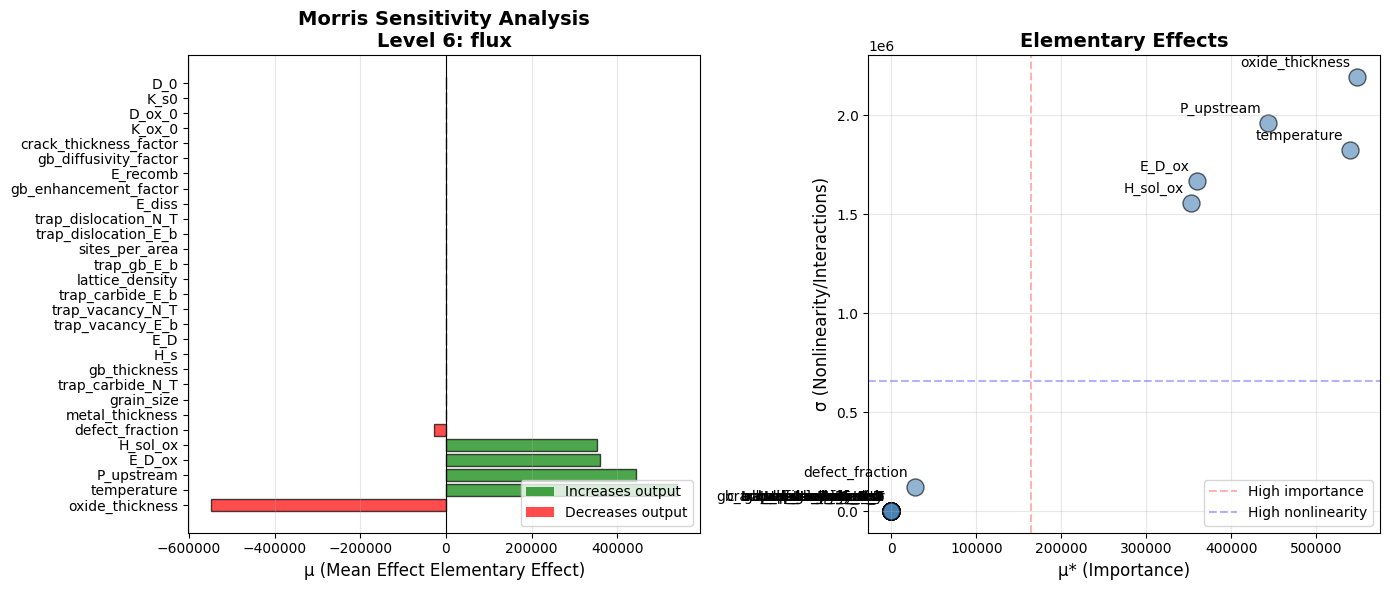


MORRIS SENSITIVITY RESULTS - Level 6: flux
             Parameter             μ           μ*            σ Direction
       oxide_thickness -5.475852e+05 5.475852e+05 2.191993e+06         ↓
           temperature  5.392694e+05 5.392694e+05 1.823412e+06         ↑
            P_upstream  4.435194e+05 4.435194e+05 1.958149e+06         ↑
                E_D_ox  3.591457e+05 3.591964e+05 1.668238e+06         ↑
              H_sol_ox  3.523391e+05 3.523910e+05 1.556472e+06         ↑
       defect_fraction -2.791238e+04 2.791238e+04 1.233398e+05         ↓
       metal_thickness  1.339657e-04 1.339657e-04 1.853070e-03         ↑
            grain_size  6.734553e-05 6.734553e-05 7.392831e-04         ↑
      trap_carbide_N_T  2.705645e-05 2.705645e-05 5.857237e-04         ↑
          gb_thickness -2.618893e-05 2.618893e-05 5.856023e-04         ↓
                   H_s  2.415281e-05 2.415281e-05 5.371699e-04         ↑
                   E_D  1.111351e-05 1.111351e-05 2.377843e-04         ↑
      t

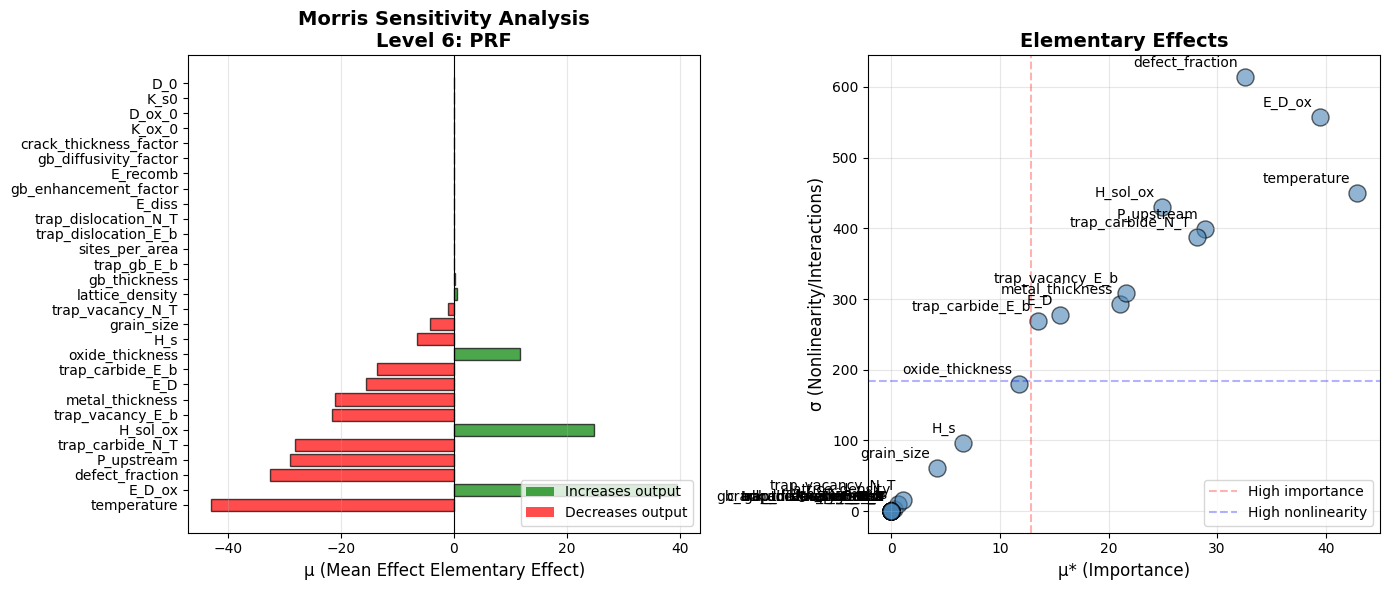


MORRIS SENSITIVITY RESULTS - Level 6: PRF
             Parameter             μ           μ*            σ Direction
           temperature -4.285781e+01 4.285789e+01 4.504570e+02         ↓
                E_D_ox  3.946298e+01 3.946300e+01 5.572456e+02         ↑
       defect_fraction -3.254315e+01 3.254315e+01 6.140848e+02         ↓
            P_upstream -2.891568e+01 2.891570e+01 3.988433e+02         ↓
      trap_carbide_N_T -2.813336e+01 2.813336e+01 3.876021e+02         ↓
              H_sol_ox  2.489560e+01 2.489561e+01 4.299700e+02         ↑
      trap_vacancy_E_b -2.159955e+01 2.159956e+01 3.088653e+02         ↓
       metal_thickness -2.103220e+01 2.103221e+01 2.928142e+02         ↓
                   E_D -1.553488e+01 1.553489e+01 2.778324e+02         ↓
      trap_carbide_E_b -1.350633e+01 1.350633e+01 2.686017e+02         ↓
       oxide_thickness  1.178718e+01 1.178721e+01 1.797336e+02         ↑
                   H_s -6.557649e+00 6.557655e+00 9.569092e+01         ↓
        

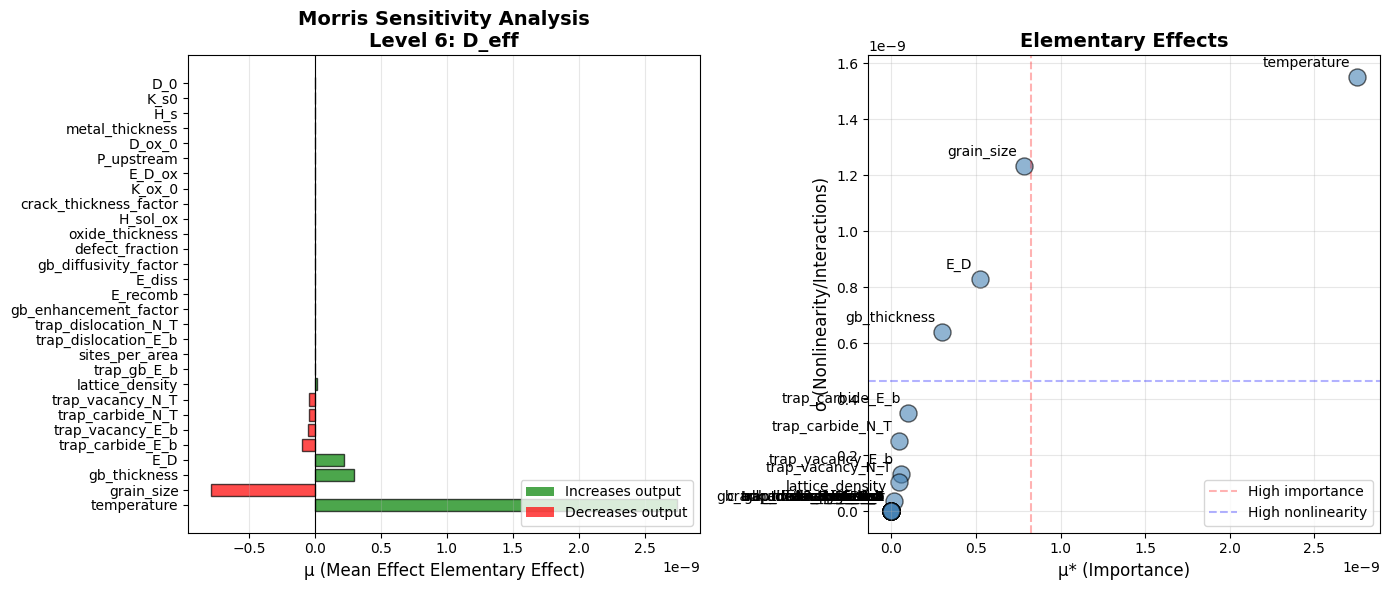


MORRIS SENSITIVITY RESULTS - Level 6: D_eff
             Parameter             μ           μ*            σ Direction
           temperature  2.743941e-09 2.751181e-09 1.550002e-09         ↑
            grain_size -7.839015e-10 7.839015e-10 1.233924e-09         ↓
          gb_thickness  2.991081e-10 2.991081e-10 6.399662e-10         ↑
                   E_D  2.216122e-10 5.210850e-10 8.272808e-10         ↑
      trap_carbide_E_b -9.609643e-11 9.609643e-11 3.512545e-10         ↓
      trap_vacancy_E_b -5.562109e-11 5.562109e-11 1.334829e-10         ↓
      trap_carbide_N_T -4.778899e-11 4.778899e-11 2.508881e-10         ↓
      trap_vacancy_N_T -4.321303e-11 4.321303e-11 1.028439e-10         ↓
       lattice_density  1.522368e-11 1.522368e-11 3.716564e-11         ↑
           trap_gb_E_b -4.828652e-19 4.828652e-19 1.902800e-18         ↓
        sites_per_area -3.949151e-19 3.949151e-19 1.630428e-18         ↓
  trap_dislocation_E_b -2.536105e-20 2.536105e-20 4.015504e-20         ↓
  trap

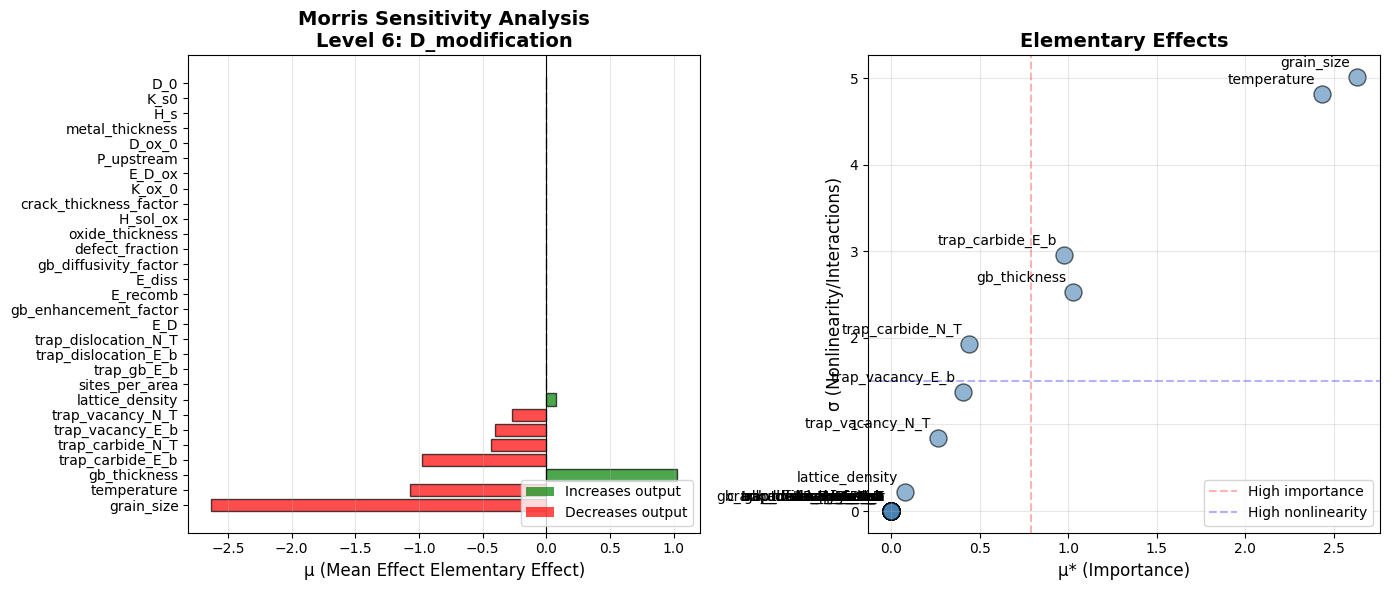


MORRIS SENSITIVITY RESULTS - Level 6: D_modification
             Parameter             μ           μ*            σ Direction
            grain_size -2.630786e+00 2.630786e+00 5.014344e+00         ↓
           temperature -1.071124e+00 2.437114e+00 4.820300e+00         ↓
          gb_thickness  1.025831e+00 1.025831e+00 2.527159e+00         ↑
      trap_carbide_E_b -9.742006e-01 9.742006e-01 2.954158e+00         ↓
      trap_carbide_N_T -4.377788e-01 4.377788e-01 1.926738e+00         ↓
      trap_vacancy_E_b -4.056531e-01 4.056531e-01 1.380728e+00         ↓
      trap_vacancy_N_T -2.656007e-01 2.656007e-01 8.456745e-01         ↓
       lattice_density  7.717931e-02 7.717931e-02 2.160946e-01         ↑
        sites_per_area -5.467994e-09 5.467994e-09 5.071736e-08         ↓
           trap_gb_E_b -5.369094e-09 5.369094e-09 3.274201e-08         ↓
  trap_dislocation_E_b -1.713412e-10 1.713412e-10 8.790637e-10         ↓
  trap_dislocation_N_T -1.140688e-10 1.140688e-10 7.786084e-10        

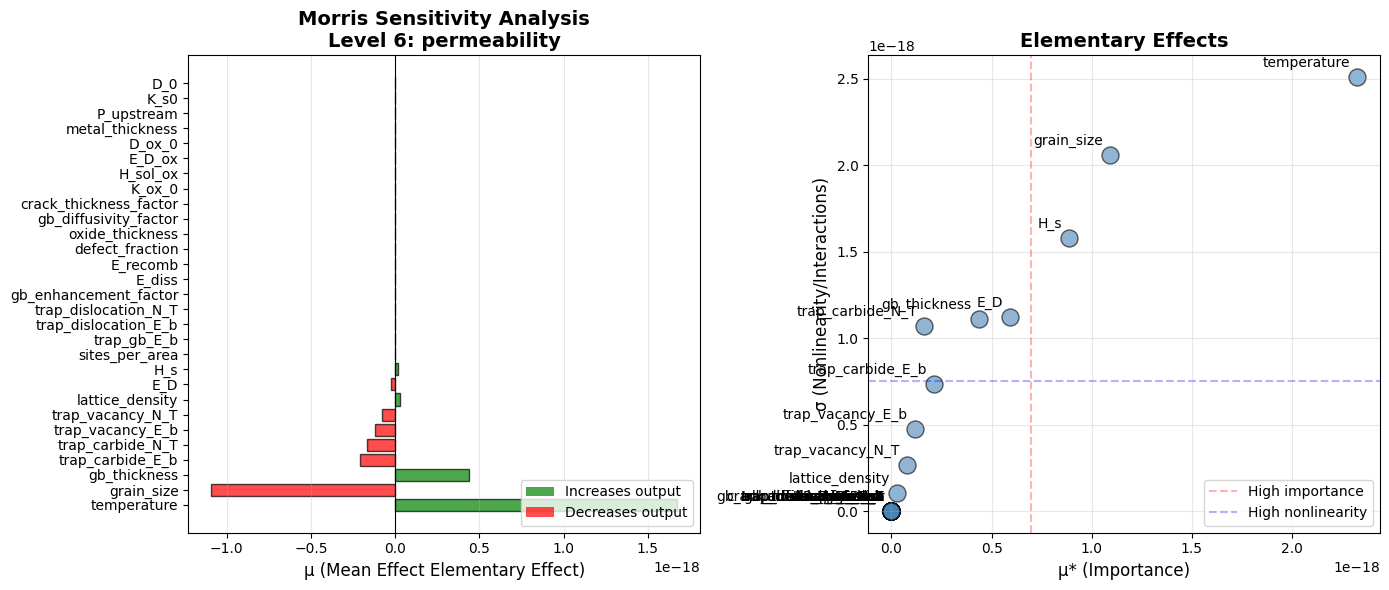


MORRIS SENSITIVITY RESULTS - Level 6: permeability
             Parameter             μ           μ*            σ Direction
           temperature  1.673205e-18 2.322691e-18 2.509330e-18         ↑
            grain_size -1.091102e-18 1.091102e-18 2.058158e-18         ↓
          gb_thickness  4.362377e-19 4.362377e-19 1.108920e-18         ↑
      trap_carbide_E_b -2.109515e-19 2.109515e-19 7.336106e-19         ↓
      trap_carbide_N_T -1.649789e-19 1.649789e-19 1.068875e-18         ↓
      trap_vacancy_E_b -1.172545e-19 1.172545e-19 4.731874e-19         ↓
      trap_vacancy_N_T -7.663796e-20 7.663796e-20 2.660588e-19         ↓
       lattice_density  2.967371e-20 2.967371e-20 1.069834e-19         ↑
                   E_D -2.568382e-20 5.926591e-19 1.121754e-18         ↓
                   H_s  1.624857e-20 8.861782e-19 1.576585e-18         ↑
        sites_per_area -9.475904e-28 9.475904e-28 5.792843e-27         ↓
           trap_gb_E_b -8.163093e-28 8.163093e-28 3.309777e-27         ↓

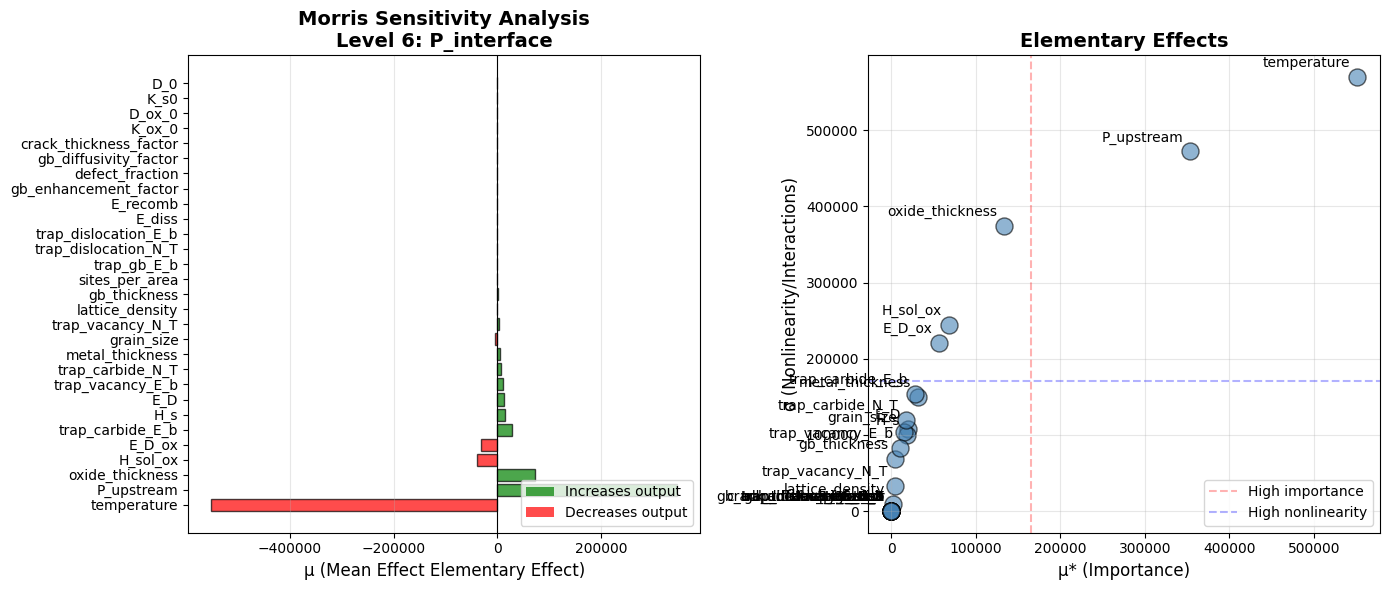


MORRIS SENSITIVITY RESULTS - Level 6: P_interface
             Parameter              μ            μ*             σ Direction
           temperature -550860.843366 550860.843366 569956.164155         ↓
            P_upstream  345880.991996 353956.991989 472197.168420         ↑
       oxide_thickness   72379.773950 133756.223824 374043.113669         ↑
              H_sol_ox  -38500.508804  68530.508792 244106.269287         ↓
                E_D_ox  -30790.508975  56842.508963 220742.714288         ↓
      trap_carbide_E_b   27455.857507  27461.857507 153292.809047         ↑
                   H_s   14935.014169  18949.014168 100228.632465         ↑
                   E_D   12139.790962  20161.790960 108080.324628         ↑
      trap_vacancy_E_b   10679.558953  10685.558953  82625.283504         ↑
      trap_carbide_N_T    6920.237866  16928.237863 119379.506210         ↑
       metal_thickness    5011.397184  31045.397177 149517.546671         ↑
            grain_size   -4837.046362

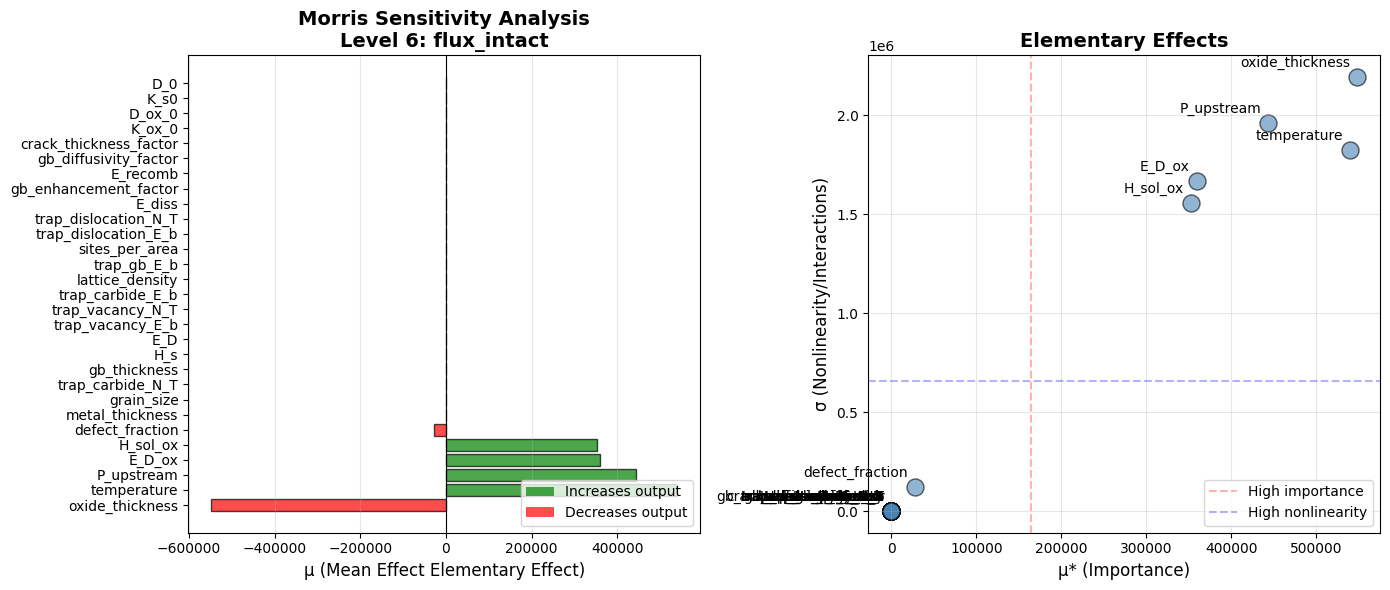


MORRIS SENSITIVITY RESULTS - Level 6: flux_intact
             Parameter             μ           μ*            σ Direction
       oxide_thickness -5.475852e+05 5.475852e+05 2.191993e+06         ↓
           temperature  5.392694e+05 5.392694e+05 1.823412e+06         ↑
            P_upstream  4.435194e+05 4.435194e+05 1.958149e+06         ↑
                E_D_ox  3.591457e+05 3.591964e+05 1.668238e+06         ↑
              H_sol_ox  3.523391e+05 3.523910e+05 1.556472e+06         ↑
       defect_fraction -2.791238e+04 2.791238e+04 1.233398e+05         ↓
       metal_thickness  1.339657e-04 1.339657e-04 1.853070e-03         ↑
            grain_size  6.734553e-05 6.734553e-05 7.392831e-04         ↑
      trap_carbide_N_T  2.705645e-05 2.705645e-05 5.857237e-04         ↑
          gb_thickness -2.618893e-05 2.618893e-05 5.856023e-04         ↓
                   H_s  2.415281e-05 2.415281e-05 5.371699e-04         ↑
                   E_D  1.111351e-05 1.111351e-05 2.377843e-04         ↑


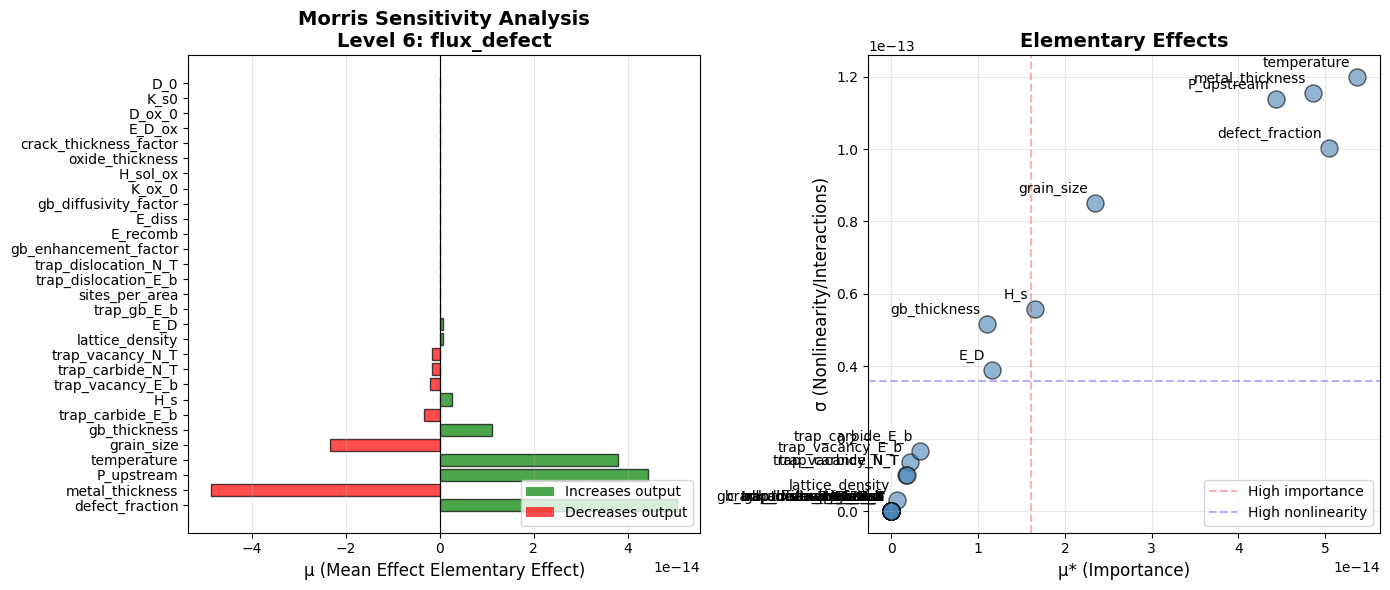


MORRIS SENSITIVITY RESULTS - Level 6: flux_defect
             Parameter             μ           μ*            σ Direction
       defect_fraction  5.044311e-14 5.044311e-14 1.002792e-13         ↑
       metal_thickness -4.864472e-14 4.864472e-14 1.155829e-13         ↓
            P_upstream  4.437728e-14 4.437728e-14 1.139449e-13         ↑
           temperature  3.787283e-14 5.364390e-14 1.199117e-13         ↑
            grain_size -2.342477e-14 2.342477e-14 8.516372e-14         ↓
          gb_thickness  1.104561e-14 1.104561e-14 5.155670e-14         ↑
      trap_carbide_E_b -3.329912e-15 3.329912e-15 1.668490e-14         ↓
                   H_s  2.491101e-15 1.658939e-14 5.589069e-14         ↑
      trap_vacancy_E_b -2.089458e-15 2.089458e-15 1.348021e-14         ↓
      trap_carbide_N_T -1.746498e-15 1.746498e-15 9.872182e-15         ↓
      trap_vacancy_N_T -1.674207e-15 1.674207e-15 9.951700e-15         ↓
       lattice_density  6.147279e-16 6.147279e-16 3.067551e-15         ↑


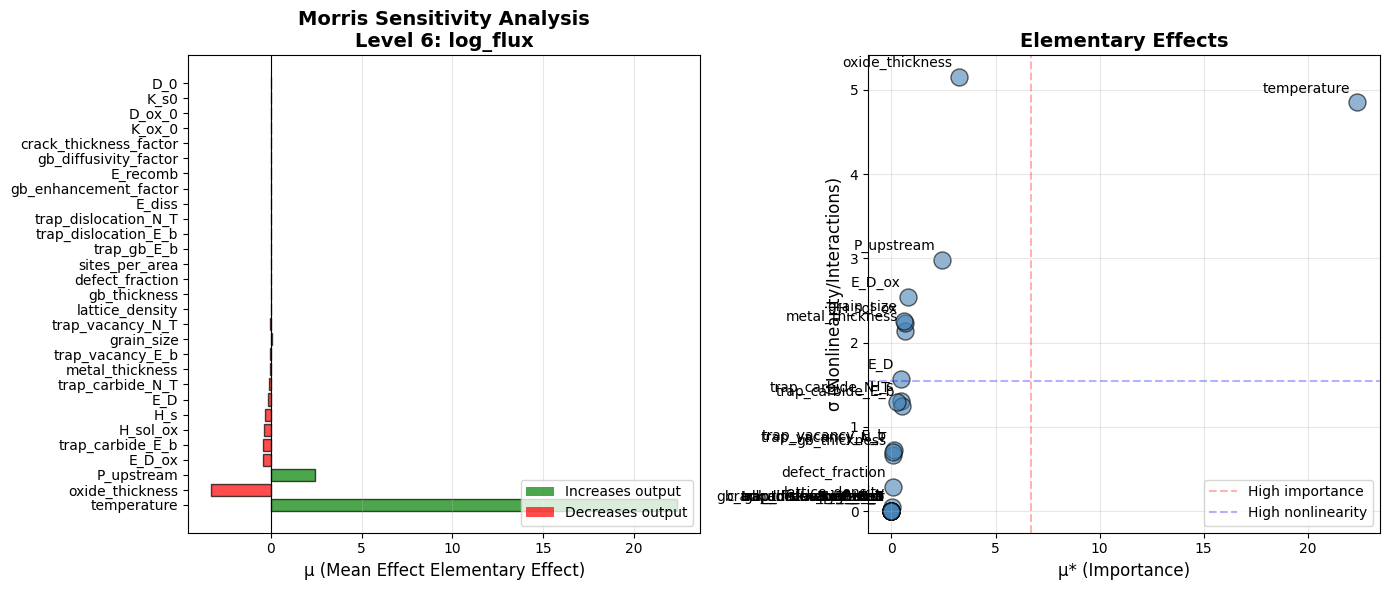


MORRIS SENSITIVITY RESULTS - Level 6: log_flux
             Parameter             μ           μ*            σ Direction
           temperature  2.234735e+01 2.234735e+01 4.849764e+00         ↑
       oxide_thickness -3.263097e+00 3.263097e+00 5.151928e+00         ↓
            P_upstream  2.430748e+00 2.430748e+00 2.976648e+00         ↑
                E_D_ox -4.552933e-01 7.854144e-01 2.536601e+00         ↓
      trap_carbide_E_b -4.541772e-01 5.138924e-01 1.251946e+00         ↓
              H_sol_ox -3.635019e-01 6.544976e-01 2.232175e+00         ↓
                   H_s -3.073241e-01 4.827598e-01 1.311537e+00         ↓
                   E_D -1.636193e-01 4.575586e-01 1.562258e+00         ↓
      trap_carbide_N_T -1.009194e-01 2.773757e-01 1.296143e+00         ↓
       metal_thickness -6.657556e-02 6.474062e-01 2.139993e+00         ↓
      trap_vacancy_E_b -5.862384e-02 1.181505e-01 7.205767e-01         ↓
            grain_size  5.101465e-02 6.181011e-01 2.256487e+00         ↑
   

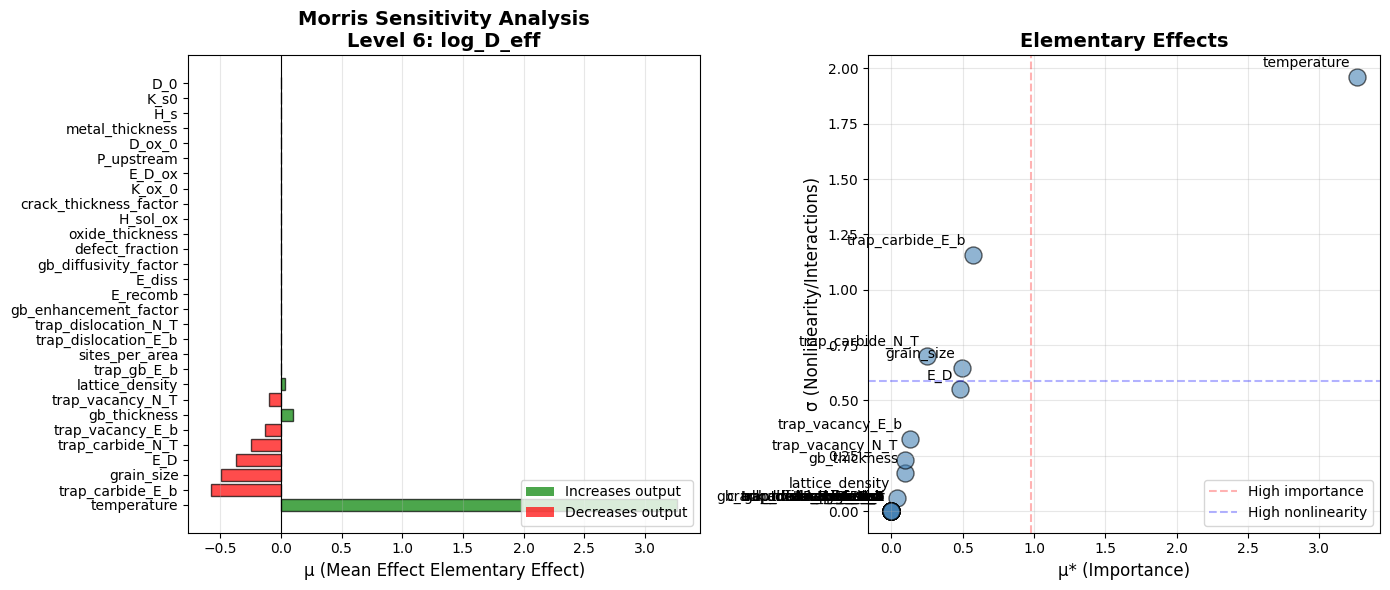


MORRIS SENSITIVITY RESULTS - Level 6: log_D_eff
             Parameter             μ           μ*            σ Direction
           temperature  3.261595e+00 3.262528e+00 1.961405e+00         ↑
      trap_carbide_E_b -5.707096e-01 5.707096e-01 1.158652e+00         ↓
            grain_size -4.943873e-01 4.943873e-01 6.454151e-01         ↓
                   E_D -3.717258e-01 4.817662e-01 5.492404e-01         ↓
      trap_carbide_N_T -2.470574e-01 2.470574e-01 7.009413e-01         ↓
      trap_vacancy_E_b -1.288313e-01 1.288313e-01 3.270065e-01         ↓
          gb_thickness  9.804496e-02 9.804496e-02 1.725741e-01         ↑
      trap_vacancy_N_T -9.497627e-02 9.497627e-02 2.297685e-01         ↓
       lattice_density  3.743342e-02 3.743342e-02 5.716334e-02         ↑
           trap_gb_E_b -3.258633e-10 3.258633e-10 1.740641e-09         ↓
        sites_per_area -3.074162e-10 3.074162e-10 2.088494e-09         ↓
  trap_dislocation_E_b -3.513709e-11 3.513709e-11 1.105361e-10         ↓
  

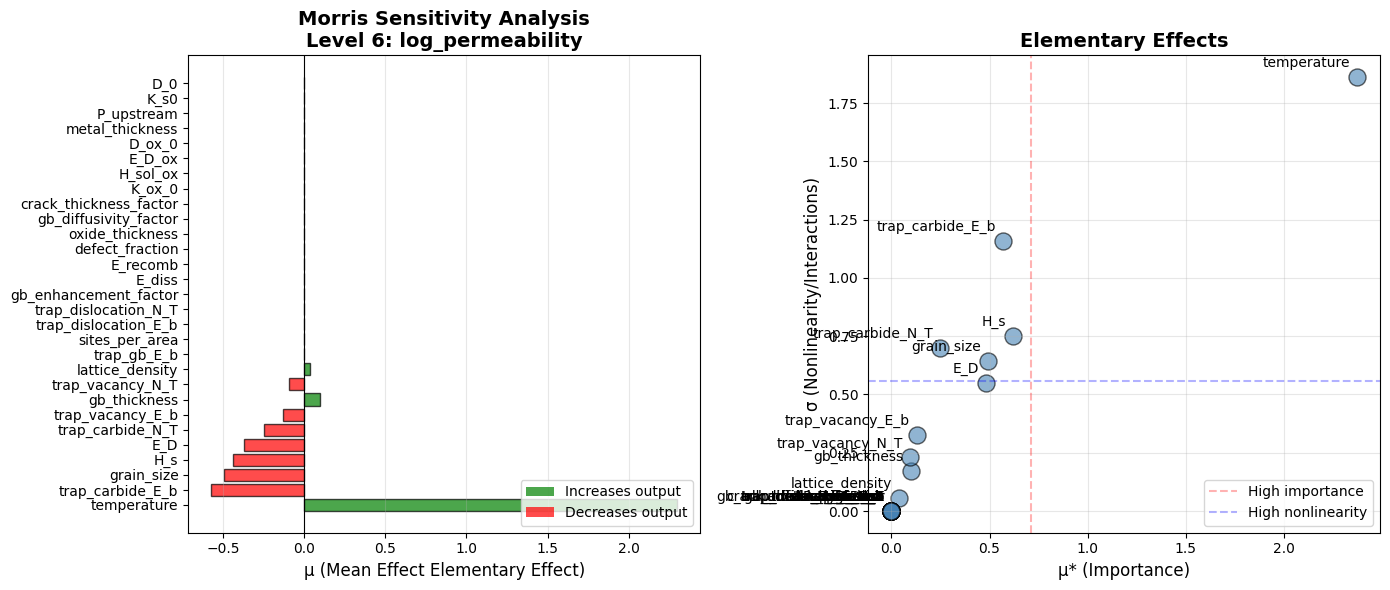


MORRIS SENSITIVITY RESULTS - Level 6: log_permeability
             Parameter             μ           μ*            σ Direction
           temperature  2.296115e+00 2.371427e+00 1.862155e+00         ↑
      trap_carbide_E_b -5.707096e-01 5.707096e-01 1.158652e+00         ↓
            grain_size -4.943873e-01 4.943873e-01 6.454151e-01         ↓
                   H_s -4.372641e-01 6.194420e-01 7.525837e-01         ↓
                   E_D -3.717258e-01 4.817662e-01 5.492404e-01         ↓
      trap_carbide_N_T -2.470574e-01 2.470574e-01 7.009413e-01         ↓
      trap_vacancy_E_b -1.288313e-01 1.288313e-01 3.270065e-01         ↓
          gb_thickness  9.804496e-02 9.804496e-02 1.725741e-01         ↑
      trap_vacancy_N_T -9.497627e-02 9.497627e-02 2.297685e-01         ↓
       lattice_density  3.743342e-02 3.743342e-02 5.716334e-02         ↑
           trap_gb_E_b -3.258634e-10 3.258634e-10 1.740641e-09         ↓
        sites_per_area -3.074161e-10 3.074161e-10 2.088494e-09      

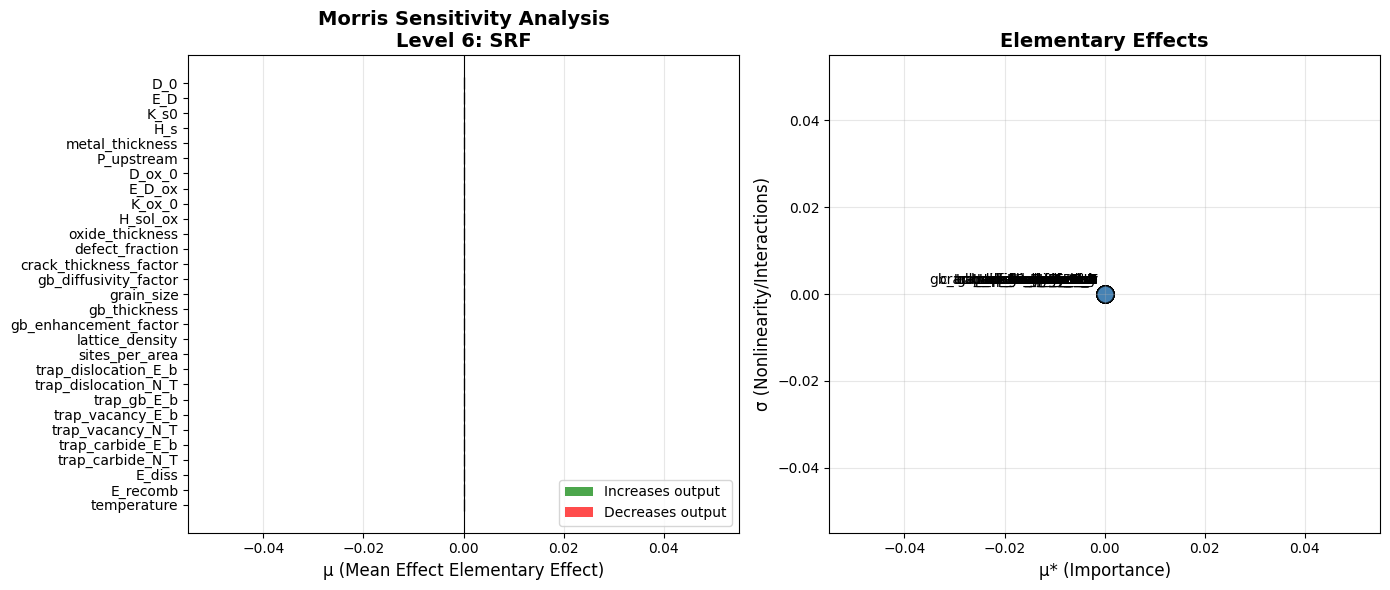


MORRIS SENSITIVITY RESULTS - Level 6: SRF
             Parameter   μ  μ*   σ Direction
           temperature 0.0 0.0 0.0         ↓
              E_recomb 0.0 0.0 0.0         ↓
                E_diss 0.0 0.0 0.0         ↓
      trap_carbide_N_T 0.0 0.0 0.0         ↓
      trap_carbide_E_b 0.0 0.0 0.0         ↓
      trap_vacancy_N_T 0.0 0.0 0.0         ↓
      trap_vacancy_E_b 0.0 0.0 0.0         ↓
           trap_gb_E_b 0.0 0.0 0.0         ↓
  trap_dislocation_N_T 0.0 0.0 0.0         ↓
  trap_dislocation_E_b 0.0 0.0 0.0         ↓
        sites_per_area 0.0 0.0 0.0         ↓
       lattice_density 0.0 0.0 0.0         ↓
 gb_enhancement_factor 0.0 0.0 0.0         ↓
          gb_thickness 0.0 0.0 0.0         ↓
            grain_size 0.0 0.0 0.0         ↓
 gb_diffusivity_factor 0.0 0.0 0.0         ↓
crack_thickness_factor 0.0 0.0 0.0         ↓
       defect_fraction 0.0 0.0 0.0         ↓
       oxide_thickness 0.0 0.0 0.0         ↓
              H_sol_ox 0.0 0.0 0.0         ↓
            

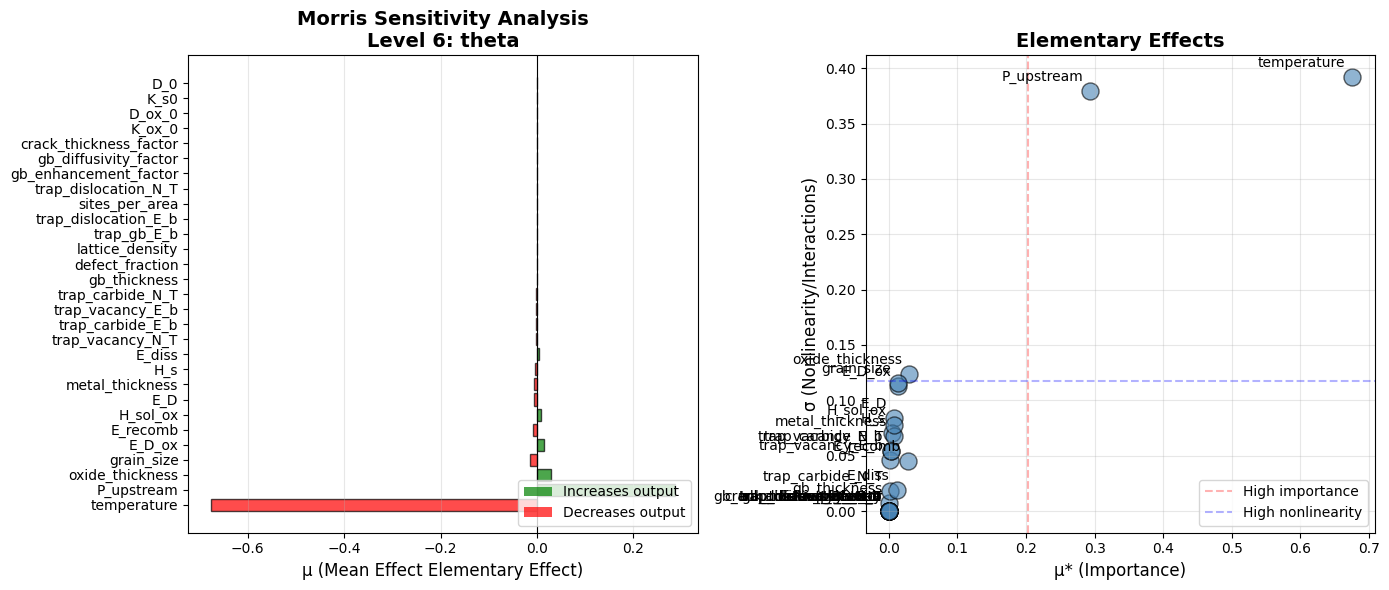


MORRIS SENSITIVITY RESULTS - Level 6: theta
             Parameter             μ           μ*            σ Direction
           temperature -6.754441e-01 6.754441e-01 3.920346e-01         ↓
            P_upstream  2.853796e-01 2.937801e-01 3.794768e-01         ↑
       oxide_thickness  2.923749e-02 2.934464e-02 1.237447e-01         ↑
            grain_size -1.388711e-02 1.389111e-02 1.153710e-01         ↓
                E_D_ox  1.367196e-02 1.397986e-02 1.128074e-01         ↑
              E_recomb -8.929233e-03 2.821980e-02 4.540088e-02         ↓
              H_sol_ox  7.480578e-03 7.520988e-03 7.751256e-02         ↑
                   E_D -7.110947e-03 7.312043e-03 8.427911e-02         ↓
       metal_thickness -6.878957e-03 6.987703e-03 6.769968e-02         ↓
                   H_s -4.812397e-03 4.823752e-03 7.065744e-02         ↓
                E_diss  3.671412e-03 1.154486e-02 1.893661e-02         ↑
      trap_vacancy_N_T -2.424834e-03 2.428787e-03 5.426523e-02         ↓
      

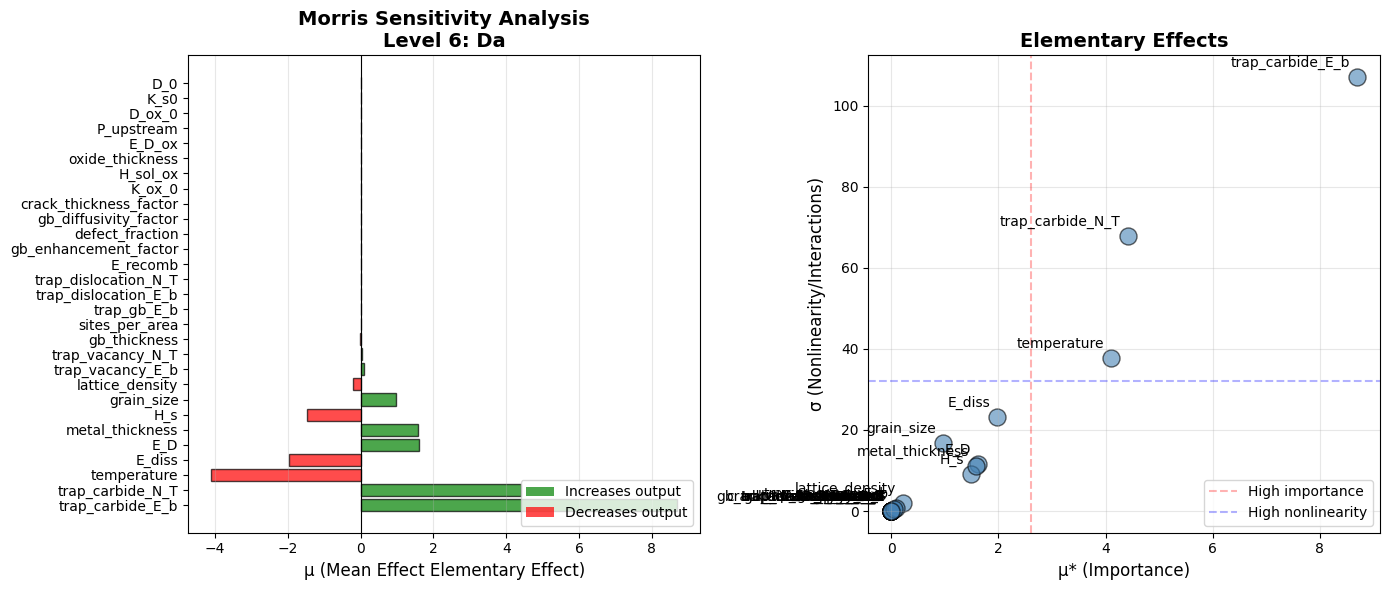


MORRIS SENSITIVITY RESULTS - Level 6: Da
             Parameter             μ           μ*            σ Direction
      trap_carbide_E_b  8.690513e+00 8.690513e+00 1.071171e+02         ↑
      trap_carbide_N_T  4.414878e+00 4.414878e+00 6.793453e+01         ↑
           temperature -4.102316e+00 4.102316e+00 3.788546e+01         ↓
                E_diss -1.974369e+00 1.974370e+00 2.322786e+01         ↓
                   E_D  1.616009e+00 1.616011e+00 1.151052e+01         ↑
       metal_thickness  1.580819e+00 1.580819e+00 1.102425e+01         ↑
                   H_s -1.482147e+00 1.482151e+00 9.083996e+00         ↓
            grain_size  9.661907e-01 9.661907e-01 1.670624e+01         ↑
       lattice_density -2.212933e-01 2.212933e-01 2.029564e+00         ↓
      trap_vacancy_E_b  8.202113e-02 8.202113e-02 7.663881e-01         ↑
      trap_vacancy_N_T  4.544778e-02 4.544778e-02 3.783284e-01         ↑
          gb_thickness -3.090873e-02 3.090873e-02 2.038380e-01         ↓
        s

In [16]:
# =============================================================================
# PLOT MORRIS RESULTS FOR ALL OUTPUTS
# =============================================================================

for output_metric in VALID_OUTPUT_METRICS_L5L6:
    print(f"\n{'='*70}")
    print(f"OUTPUT: {output_metric}")
    print(f"{'='*70}")
    
    Si = morris_results[output_metric]['Si']
    problem = morris_results[output_metric]['problem']
    
    plot_morris_results(Si, problem, f'Level 6: {output_metric}')

In [17]:
# =============================================================================
# PARAMETER IMPORTANCE RANKING ACROSS ALL 11 OUTPUTS
# =============================================================================
import pandas as pd

param_names = morris_results['flux']['problem']['names']

# Build DataFrame with μ* for each output
df_all = pd.DataFrame({'Parameter': param_names})

for output_metric in VALID_OUTPUT_METRICS_L5L6:
    df_all[f'μ*_{output_metric}'] = morris_results[output_metric]['Si']['mu_star']

# Normalize each column
for output_metric in VALID_OUTPUT_METRICS_L5L6:
    col = f'μ*_{output_metric}'
    max_val = df_all[col].max()
    if max_val > 0:
        df_all[f'{col}_norm'] = df_all[col] / max_val
    else:
        df_all[f'{col}_norm'] = 0

# Average normalized importance across all outputs
norm_cols = [f'μ*_{m}_norm' for m in VALID_OUTPUT_METRICS_L5L6]
df_all['Avg_Importance'] = df_all[norm_cols].mean(axis=1)
df_all = df_all.sort_values('Avg_Importance', ascending=False)

# Display summary
print("="*100)
print("PARAMETER IMPORTANCE RANKING (Morris μ* - All 8 Outputs)")
print("="*100)
display_cols = ['Parameter'] + [f'μ*_{m}' for m in VALID_OUTPUT_METRICS_L5L6] + ['Avg_Importance']
print(df_all[display_cols].to_string(index=False))
print("="*100)

# Top 10 for Sobol
top_10 = df_all.head(10)['Parameter'].tolist()
print(f"\n→ Top 10 parameters for focused Sobol analysis:")
for i, p in enumerate(top_10, 1):
    importance = df_all[df_all['Parameter'] == p]['Avg_Importance'].values[0]
    print(f"   {i:2d}. {p:<25s} (avg importance: {importance:.3f})")

PARAMETER IMPORTANCE RANKING (Morris μ* - All 8 Outputs)
             Parameter      μ*_flux       μ*_PRF     μ*_D_eff  μ*_D_modification  μ*_permeability  μ*_P_interface  μ*_flux_intact  μ*_flux_defect  μ*_log_flux  μ*_log_D_eff  μ*_log_permeability  μ*_SRF     μ*_theta        μ*_Da  Avg_Importance
           temperature 5.392694e+05 4.285789e+01 2.751181e-09       2.437114e+00     2.322691e-18   550860.843366    5.392694e+05    5.364390e-14 2.234735e+01  3.262528e+00         2.371427e+00     0.0 6.754441e-01 4.102316e+00    8.834325e-01
            P_upstream 4.435194e+05 2.891570e+01 0.000000e+00       0.000000e+00     0.000000e+00   353956.991989    4.435194e+05    4.437728e-14 2.430748e+00  0.000000e+00         0.000000e+00     0.0 2.937801e-01 0.000000e+00    3.077230e-01
            grain_size 6.734553e-05 4.188387e+00 7.839015e-10       2.630786e+00     1.091102e-18    15214.953619    6.734553e-05    2.342477e-14 6.181011e-01  4.943873e-01         4.943873e-01     0.0 1.389111e

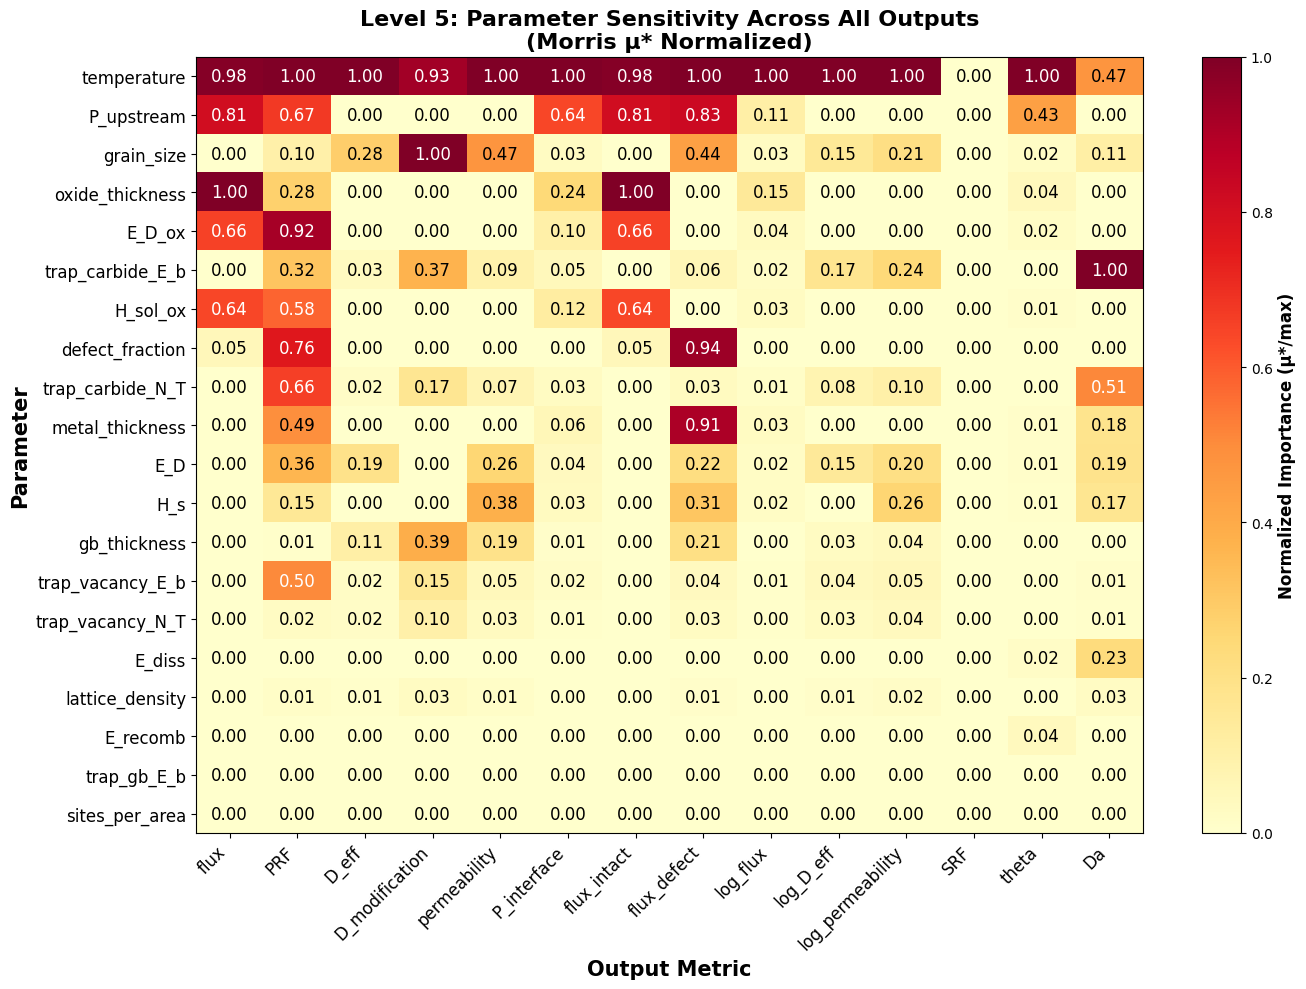

In [18]:
# =============================================================================
# HEATMAP: Parameter Importance Across All Outputs
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np

# Get top 20 parameters for visualization
top_20 = df_all.head(20)

# Extract normalized values for heatmap
heatmap_data = top_20[[f'μ*_{m}_norm' for m in VALID_OUTPUT_METRICS_L5L6]].values
param_labels = top_20['Parameter'].tolist()
output_labels = VALID_OUTPUT_METRICS_L5L6

fig, ax = plt.subplots(figsize=(14, 10))

im = ax.imshow(heatmap_data, cmap='YlOrRd', aspect='auto')

# Labels
ax.set_xticks(np.arange(len(output_labels)))
ax.set_yticks(np.arange(len(param_labels)))
ax.set_xticklabels(output_labels, rotation=45, ha='right', fontsize=12)
ax.set_yticklabels(param_labels, fontsize=12)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Normalized Importance (μ*/max)', fontsize=12, fontweight='bold')

# Annotate cells with values
for i in range(len(param_labels)):
    for j in range(len(output_labels)):
        val = heatmap_data[i, j]
        color = 'white' if val > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', color=color, fontsize=12)

ax.set_title('Level 5: Parameter Sensitivity Across All Outputs\n(Morris μ* Normalized)', 
             fontsize=16, fontweight='bold')
ax.set_xlabel('Output Metric', fontsize=15, fontweight='bold')
ax.set_ylabel('Parameter', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

In [19]:
# =============================================================================
# CREATE FOCUSED RANGES FOR SOBOL (Top 10 from Morris Heatmap)
# =============================================================================

# top_10 already exists from the ranking cell above
SOBOL_FOCUSED_RANGES = {param: SUGGESTED_RANGES_LEVEL5L6[param] for param in top_10}

print("="*70)
print("FOCUSED PARAMETER RANGES FOR SOBOL (Top 10 from Heatmap)")
print("="*70)
for i, (param, bounds) in enumerate(SOBOL_FOCUSED_RANGES.items(), 1):
    importance = df_all[df_all['Parameter'] == param]['Avg_Importance'].values[0]
    print(f"  {i:2d}. {param:<25s}: [{bounds[0]:.2e}, {bounds[1]:.2e}]  (μ*={importance:.3f})")
print("="*70)

FOCUSED PARAMETER RANGES FOR SOBOL (Top 10 from Heatmap)
   1. temperature              : [5.73e+02, 1.27e+03]  (μ*=0.883)
   2. P_upstream               : [1.00e+03, 1.00e+06]  (μ*=0.308)
   3. grain_size               : [1.00e-07, 1.00e-04]  (μ*=0.203)
   4. oxide_thickness          : [1.00e-08, 1.00e-05]  (μ*=0.193)
   5. E_D_ox                   : [1.20e+05, 2.00e+05]  (μ*=0.171)
   6. trap_carbide_E_b         : [5.00e+04, 1.00e+05]  (μ*=0.169)
   7. H_sol_ox                 : [1.50e+05, 2.20e+05]  (μ*=0.145)
   8. defect_fraction          : [1.00e-04, 1.00e-01]  (μ*=0.129)
   9. trap_carbide_N_T         : [1.00e+19, 1.00e+23]  (μ*=0.120)
  10. metal_thickness          : [5.00e-04, 5.00e-03]  (μ*=0.120)


In [20]:
# =============================================================================
# SOBOL ANALYSIS: TOP 10 PARAMETERS (from Morris screening)
# =============================================================================
# Set random seeds for reproducibility


sobol_results = {}

for output_metric in VALID_OUTPUT_METRICS_L5L6:
    print(f"\n{'#'*70}")
    print(f"# Running Sobol for: {output_metric}")
    print(f"{'#'*70}")
    
    Si, problem, Y = sobol_sensitivity_level5L6(
        SOBOL_FOCUSED_RANGES,  # Use focused ranges from Morris top 10
        N_samples=1024,              # Samples (total = N × (2D + 2) = 22,528)
        output_metric=output_metric
        
        
    )
  
    sobol_results[output_metric] = {
        'Si': Si,
        'problem': problem,
        'Y': Y
    }

print("\n" + "="*70)
print("✓ Sobol analysis complete for all output metrics!")
print("="*70)


######################################################################
# Running Sobol for: flux
######################################################################

SOBOL SENSITIVITY ANALYSIS - LEVEL 5+L6
(Complete Hierarchical Model + Surface Kinetics)
Running 22528 Sobol samples (N_base=1024, 10 params)
Parameters: temperature, P_upstream, grain_size, oxide_thickness, E_D_ox, trap_carbide_E_b, H_sol_ox, defect_fraction, trap_carbide_N_T, metal_thickness
Output metric: flux
Second-order interactions: Yes
Coverage mode: steady_state (Arrhenius kinetics)
⏳ This may take a while...



/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:613: UserWarning: Temperature 574.0 K is far outside data range [873.1, 1273.2] K. Clamping to nearest data limit for interpolation.
  warnings.warn(
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1951: UserWarning: GB traps already in trap_list, not adding automatically
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1232: UserWarning: Reduction factor 6.14e-03 < 0.01. Diffusion essentially stopped - model may be inappropriate.
  warnings.warn(f"Reduction factor {reduction_factor:.2e} < 0.01. "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.00×) and trapping (0.99×) nearly cancel. Small parameter changes could significantly affect results.
  warni

  Completed 2252/22528 samples (10%)


/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.13×) and trapping (0.99×) nearly cancel. Small parameter changes could significantly affect results.
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.02×) and trapping (0.94×) nearly cancel. Small parameter changes could significantly affect results.
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.13×) and trapping (0.98×) nearly cancel. Small parameter changes could significantly affect results.
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.13×) and trapping (1.00×) nearly cancel. Small parameter c

  Completed 4504/22528 samples (20%)


...

  Completed 20268/22528 samples (90%)


/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.22×) and trapping (0.92×) nearly cancel. Small parameter changes could significantly affect results.
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:1232: UserWarning: Reduction factor 4.83e-03 < 0.01. Diffusion essentially stopped - model may be inappropriate.
  warnings.warn(f"Reduction factor {reduction_factor:.2e} < 0.01. "
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.27×) and trapping (0.80×) nearly cancel. Small parameter changes could significantly affect results.
  warnings.warn(msg)
/Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/calculations/defective_metal.py:2006: UserWarning: GB enhancement (1.00×) and trapping (0.80×) nearly can

  Completed 22520/22528 samples (100%)
  Completed 22528/22528 samples (100%)

✓ All 22528 samples produced valid outputs

✓ Sobol analysis complete
  Output range: [3.10e-18, 5.67e+05]
  Output span: 183010021156022327967744.0× variation

  Parameter                       S1       ST    ST-S1
  ------------------------- -------- -------- --------
  oxide_thickness              0.005    0.480    0.475
  temperature                  0.016    0.150    0.134
  P_upstream                   0.006    0.087    0.081
  E_D_ox                      -0.000    0.012    0.013
  H_sol_ox                    -0.001    0.008    0.009
  defect_fraction              0.000    0.000    0.000
  metal_thickness             -0.000    0.000    0.000
  trap_carbide_E_b             0.000    0.000   -0.000
  trap_carbide_N_T            -0.000    0.000    0.000
  grain_size                  -0.000    0.000    0.000

  Sum(S1) = 0.026 (should be ~1 if additive)
  Sum(ST) = 0.738 (>1 indicates interactions)

  Top p

/Users/akinyemi.az/anaconda3/envs/mace_env/lib/python3.9/site-packages/SALib/analyze/sobol.py:141: RuntimeWarning: invalid value encountered in divide
  Y = (Y - Y.mean()) / Y.std()



✓ Sobol analysis complete
  Output range: [1.00e+00, 1.00e+00]
  Output span: 1.0× variation

  Parameter                       S1       ST    ST-S1
  ------------------------- -------- -------- --------
  metal_thickness                nan      nan      nan
  trap_carbide_N_T               nan      nan      nan
  defect_fraction                nan      nan      nan
  H_sol_ox                       nan      nan      nan
  trap_carbide_E_b               nan      nan      nan
  E_D_ox                         nan      nan      nan
  oxide_thickness                nan      nan      nan
  grain_size                     nan      nan      nan
  P_upstream                     nan      nan      nan
  temperature                    nan      nan      nan

  Sum(S1) = nan (should be ~1 if additive)
  Sum(ST) = nan (>1 indicates interactions)

  Top parameter interactions (S2 > 0.01):
    No significant pairwise interactions detected

###############################################################


OUTPUT: flux


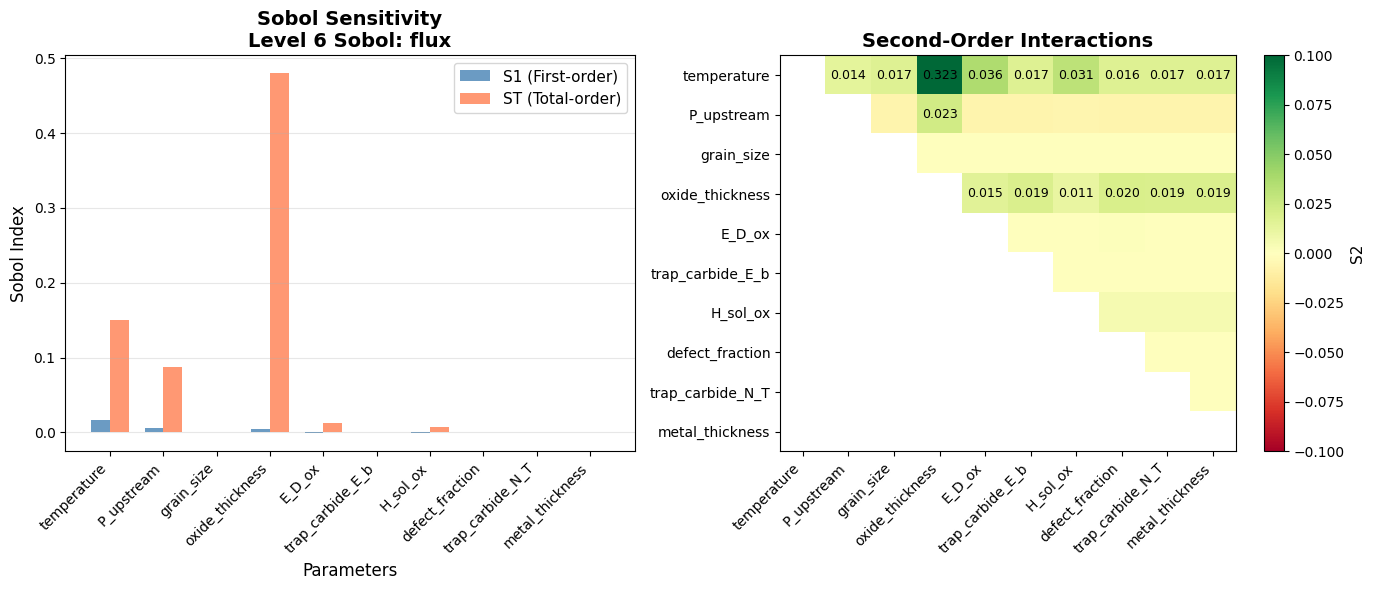


SOBOL SENSITIVITY RESULTS - Level 6 Sobol: flux
       Parameter            S1      S1_conf           ST      ST_conf  Interactions
     temperature  1.610007e-02 1.611105e-01 1.499248e-01 8.050324e-01  1.338248e-01
      P_upstream  6.148080e-03 8.479833e-02 8.742319e-02 5.457660e-01  8.127511e-02
      grain_size -1.690881e-12 2.215054e-11 3.779599e-19 4.951275e-18  1.690881e-12
 oxide_thickness  5.261440e-03 8.032310e-02 4.798753e-01 6.075395e+00  4.746139e-01
          E_D_ox -2.430355e-04 1.030686e-02 1.245224e-02 7.623163e-02  1.269527e-02
trap_carbide_E_b  1.251950e-11 4.621291e-10 2.800283e-17 9.263995e-16 -1.251947e-11
        H_sol_ox -1.183711e-03 1.590784e-02 7.920177e-03 4.687448e-02  9.103888e-03
 defect_fraction  2.121363e-05 9.566935e-04 1.536385e-04 8.454416e-04  1.324249e-04
trap_carbide_N_T -1.319593e-11 1.913822e-10 1.210454e-17 1.784415e-16  1.319594e-11
 metal_thickness -7.400429e-11 1.175015e-09 3.625251e-16 4.839607e-15  7.400466e-11

Interpretation:
  S1 : Fir

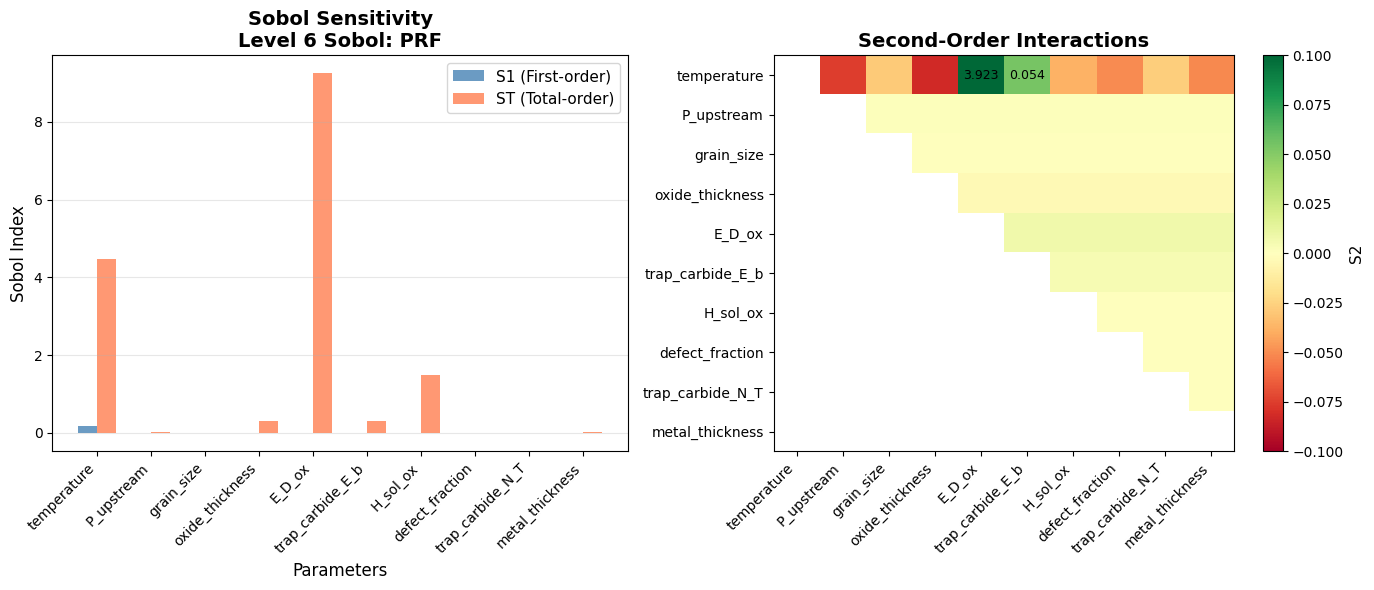


SOBOL SENSITIVITY RESULTS - Level 6 Sobol: PRF
       Parameter        S1  S1_conf       ST   ST_conf  Interactions
     temperature  0.175397 0.669183 4.470892 16.723682      4.295495
      P_upstream -0.000427 0.002667 0.033629  0.114923      0.034056
      grain_size -0.000058 0.000775 0.001018  0.007885      0.001076
 oxide_thickness  0.001693 0.005981 0.320527  0.319350      0.318834
          E_D_ox -0.009274 0.055611 9.242382 41.956628      9.251655
trap_carbide_E_b -0.002612 0.010119 0.305393  1.191657      0.308004
        H_sol_ox -0.000546 0.025933 1.498098  6.169005      1.498645
 defect_fraction  0.000406 0.000557 0.011591  0.009346      0.011185
trap_carbide_N_T  0.000082 0.000350 0.000853  0.002754      0.000771
 metal_thickness -0.000207 0.003145 0.030668  0.137735      0.030875

Interpretation:
  S1 : First-order effect (direct influence)
  ST : Total-order effect (direct + interactions)
  ST-S1 : Pure interaction effects

Top 3 Most Influential Parameters:
  E_D_ox: 

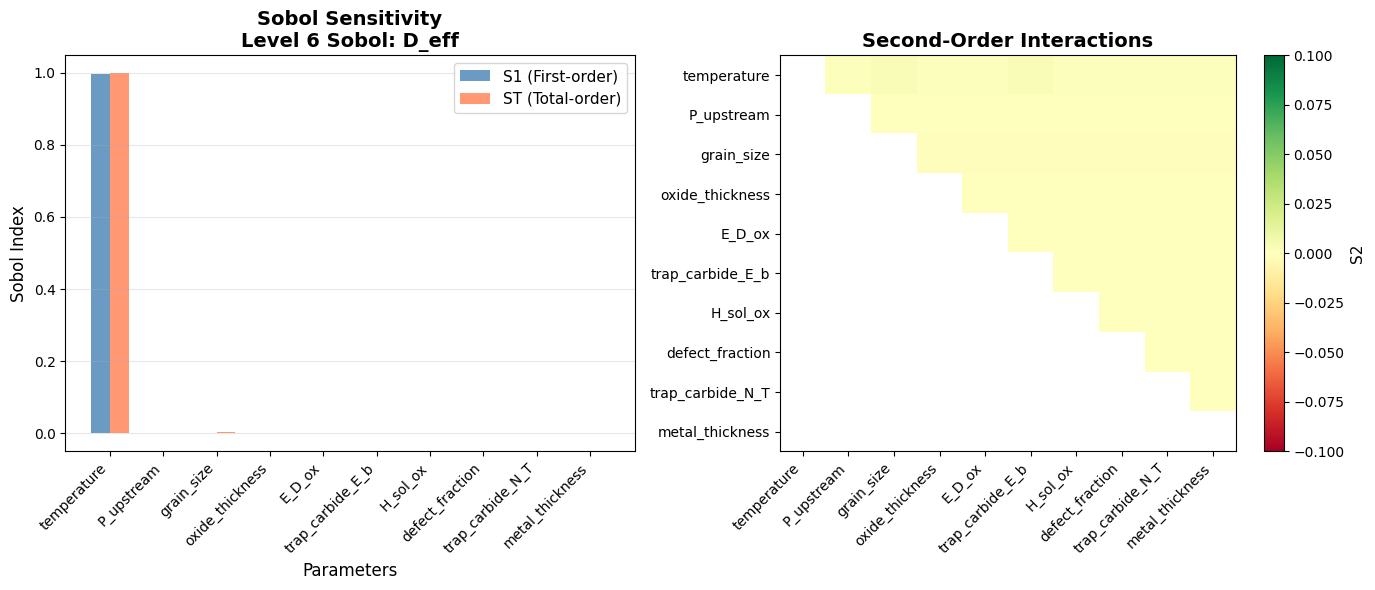


SOBOL SENSITIVITY RESULTS - Level 6 Sobol: D_eff
       Parameter        S1  S1_conf       ST  ST_conf  Interactions
     temperature  0.995418 0.079264 0.998539 0.058655      0.003121
      P_upstream  0.000000 0.000000 0.000000 0.000000      0.000000
      grain_size  0.001441 0.003160 0.002768 0.002913      0.001327
 oxide_thickness  0.000000 0.000000 0.000000 0.000000      0.000000
          E_D_ox  0.000000 0.000000 0.000000 0.000000      0.000000
trap_carbide_E_b -0.000583 0.001742 0.000403 0.000064      0.000986
        H_sol_ox  0.000000 0.000000 0.000000 0.000000      0.000000
 defect_fraction  0.000000 0.000000 0.000000 0.000000      0.000000
trap_carbide_N_T  0.000118 0.000767 0.000093 0.000023     -0.000025
 metal_thickness  0.000000 0.000000 0.000000 0.000000      0.000000

Interpretation:
  S1 : First-order effect (direct influence)
  ST : Total-order effect (direct + interactions)
  ST-S1 : Pure interaction effects

Top 3 Most Influential Parameters:
  temperature: ST =

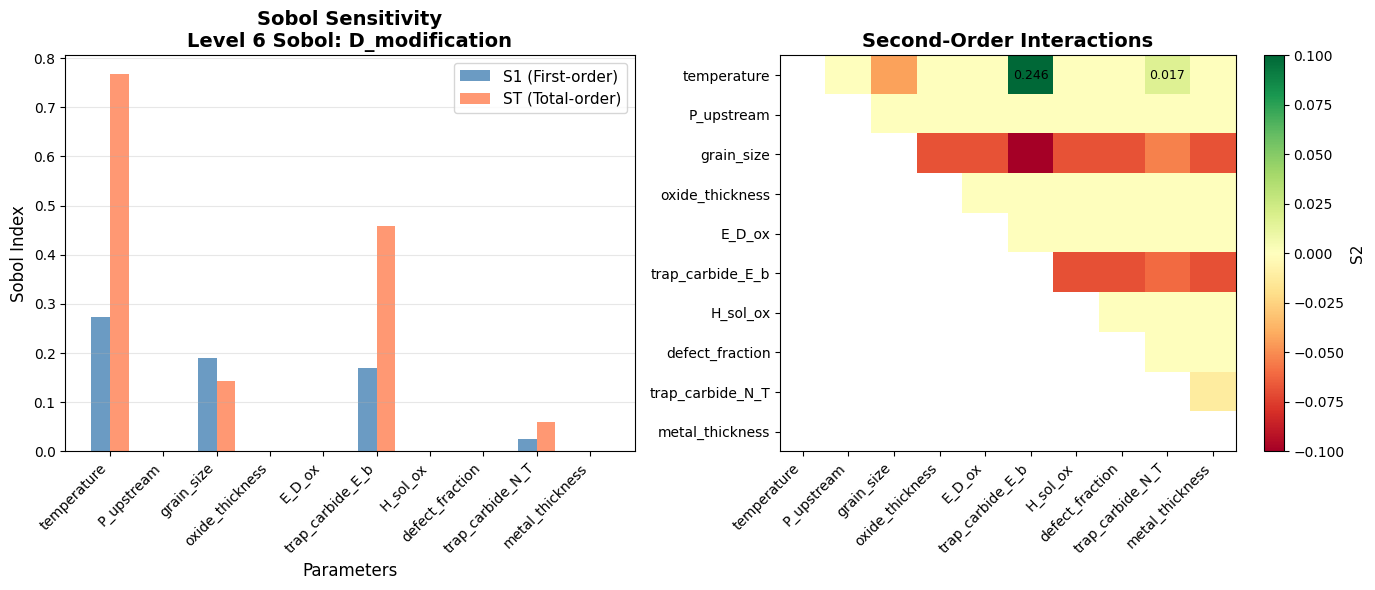


SOBOL SENSITIVITY RESULTS - Level 6 Sobol: D_modification
       Parameter       S1  S1_conf       ST  ST_conf  Interactions
     temperature 0.273162 0.125294 0.767204 0.379725      0.494042
      P_upstream 0.000000 0.000000 0.000000 0.000000      0.000000
      grain_size 0.190411 0.221503 0.143046 0.083579     -0.047365
 oxide_thickness 0.000000 0.000000 0.000000 0.000000      0.000000
          E_D_ox 0.000000 0.000000 0.000000 0.000000      0.000000
trap_carbide_E_b 0.168718 0.069561 0.458505 0.151985      0.289788
        H_sol_ox 0.000000 0.000000 0.000000 0.000000      0.000000
 defect_fraction 0.000000 0.000000 0.000000 0.000000      0.000000
trap_carbide_N_T 0.026115 0.024964 0.059727 0.024346      0.033612
 metal_thickness 0.000000 0.000000 0.000000 0.000000      0.000000

Interpretation:
  S1 : First-order effect (direct influence)
  ST : Total-order effect (direct + interactions)
  ST-S1 : Pure interaction effects

Top 3 Most Influential Parameters:
  temperature: ST = 0

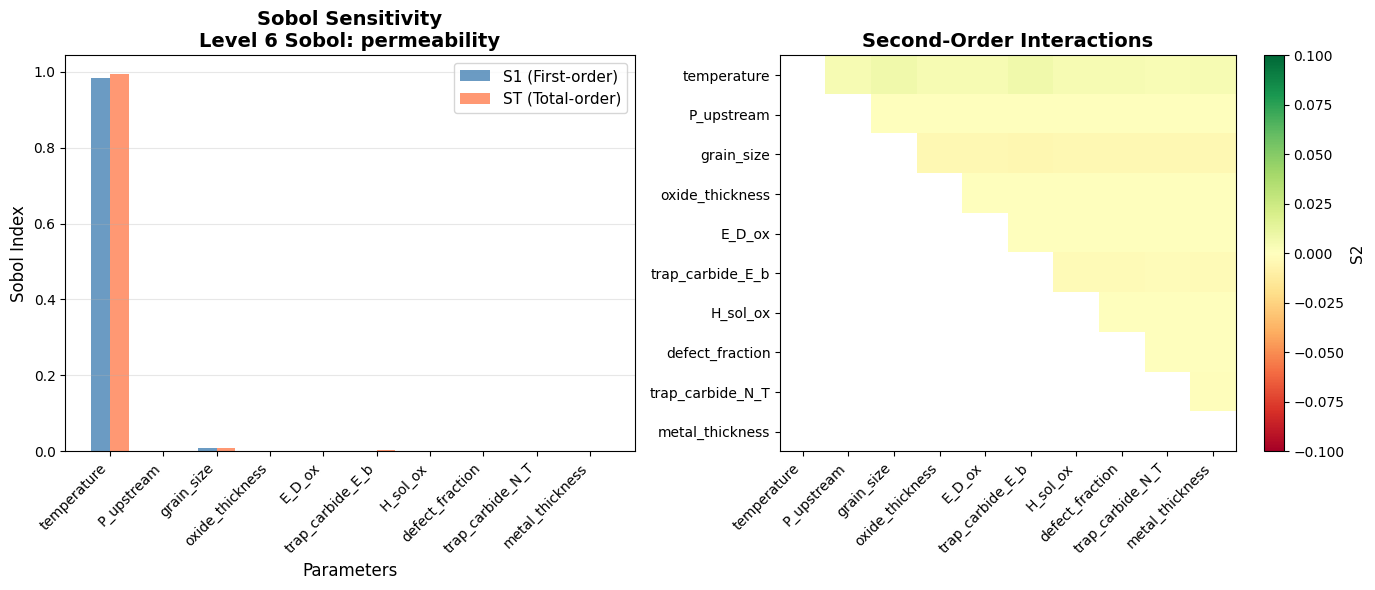


SOBOL SENSITIVITY RESULTS - Level 6 Sobol: permeability
       Parameter       S1  S1_conf       ST  ST_conf  Interactions
     temperature 0.984262 0.071309 0.993211 0.059212      0.008949
      P_upstream 0.000000 0.000000 0.000000 0.000000      0.000000
      grain_size 0.008201 0.009323 0.008683 0.009355      0.000482
 oxide_thickness 0.000000 0.000000 0.000000 0.000000      0.000000
          E_D_ox 0.000000 0.000000 0.000000 0.000000      0.000000
trap_carbide_E_b 0.000263 0.005349 0.003495 0.000509      0.003232
        H_sol_ox 0.000000 0.000000 0.000000 0.000000      0.000000
 defect_fraction 0.000000 0.000000 0.000000 0.000000      0.000000
trap_carbide_N_T 0.000466 0.002149 0.000717 0.000200      0.000252
 metal_thickness 0.000000 0.000000 0.000000 0.000000      0.000000

Interpretation:
  S1 : First-order effect (direct influence)
  ST : Total-order effect (direct + interactions)
  ST-S1 : Pure interaction effects

Top 3 Most Influential Parameters:
  temperature: ST = 0.9

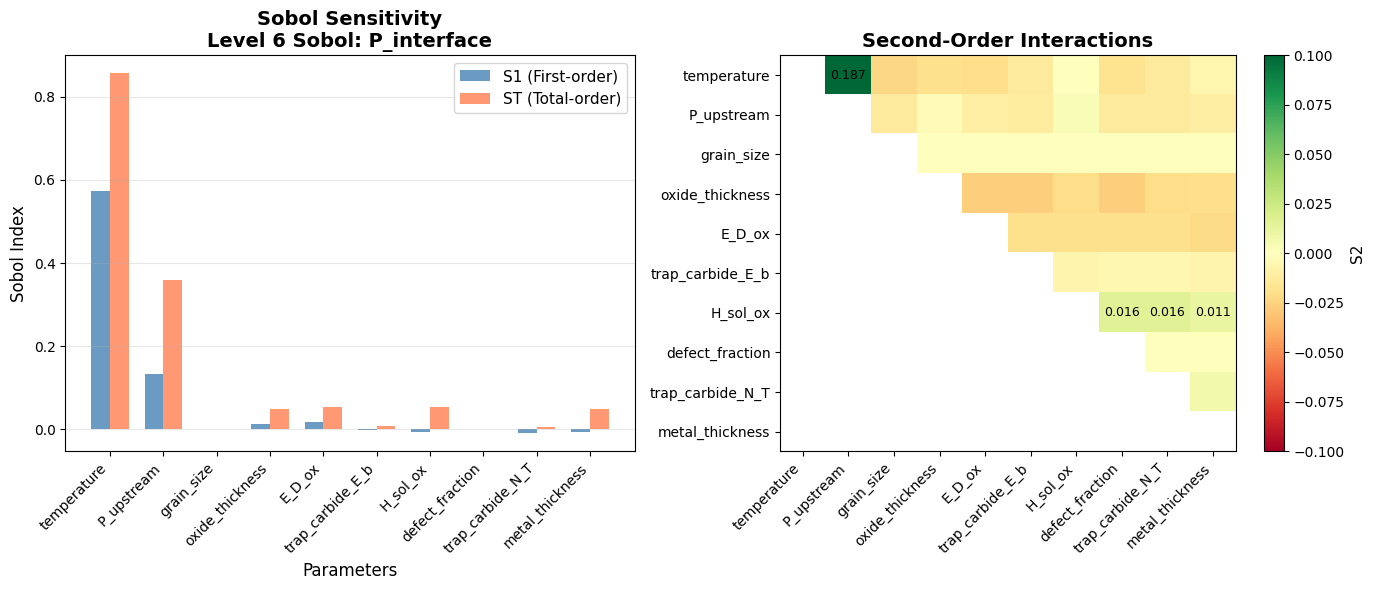


SOBOL SENSITIVITY RESULTS - Level 6 Sobol: P_interface
       Parameter        S1  S1_conf       ST  ST_conf  Interactions
     temperature  0.574145 0.066371 0.856316 0.092295      0.282171
      P_upstream  0.133245 0.041625 0.360512 0.043027      0.227267
      grain_size  0.001166 0.002243 0.001457 0.002873      0.000291
 oxide_thickness  0.013340 0.020339 0.049528 0.021253      0.036188
          E_D_ox  0.019003 0.016528 0.055216 0.024874      0.036214
trap_carbide_E_b -0.000467 0.004959 0.008072 0.009793      0.008539
        H_sol_ox -0.006246 0.018709 0.053646 0.024707      0.059893
 defect_fraction  0.000000 0.000000 0.000000 0.000000      0.000000
trap_carbide_N_T -0.009269 0.011952 0.005927 0.007554      0.015196
 metal_thickness -0.005186 0.019697 0.049274 0.024802      0.054460

Interpretation:
  S1 : First-order effect (direct influence)
  ST : Total-order effect (direct + interactions)
  ST-S1 : Pure interaction effects

Top 3 Most Influential Parameters:
  temperature

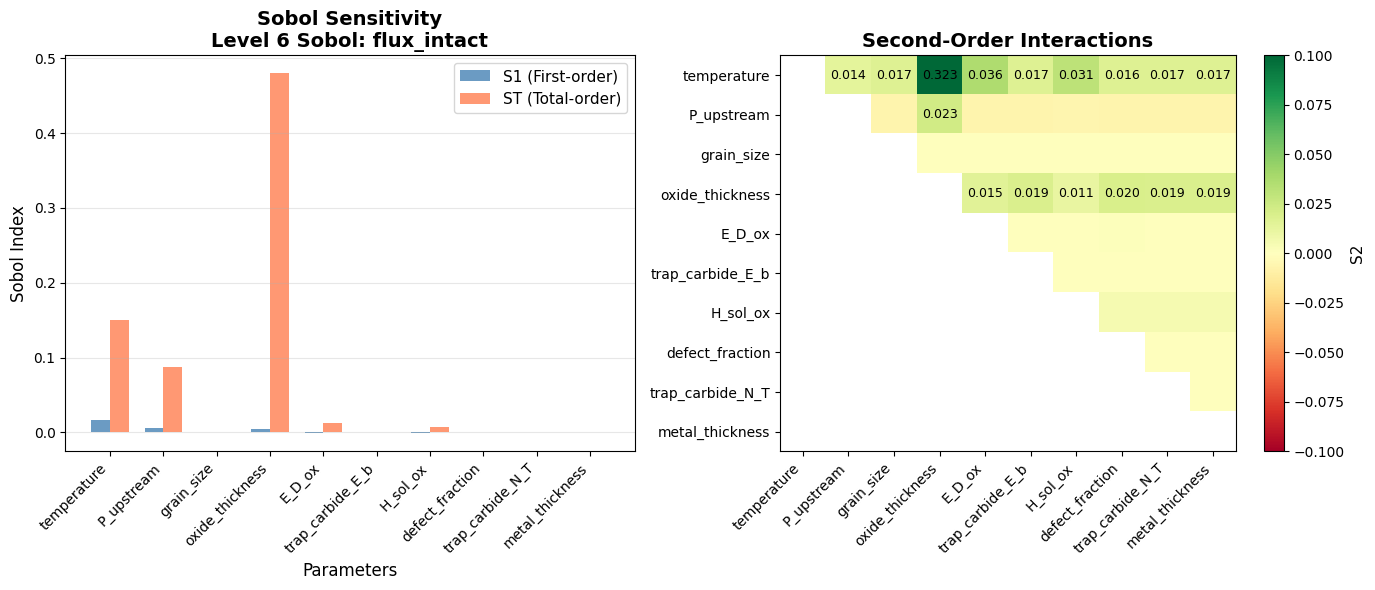


SOBOL SENSITIVITY RESULTS - Level 6 Sobol: flux_intact
       Parameter            S1      S1_conf           ST      ST_conf  Interactions
     temperature  1.610007e-02 1.611105e-01 1.499248e-01 8.050324e-01  1.338248e-01
      P_upstream  6.148080e-03 8.479833e-02 8.742319e-02 5.457660e-01  8.127511e-02
      grain_size -1.690881e-12 2.215054e-11 3.779599e-19 4.951275e-18  1.690881e-12
 oxide_thickness  5.261440e-03 8.032310e-02 4.798753e-01 6.075395e+00  4.746139e-01
          E_D_ox -2.430355e-04 1.030686e-02 1.245224e-02 7.623163e-02  1.269527e-02
trap_carbide_E_b  1.251950e-11 4.621291e-10 2.800283e-17 9.263995e-16 -1.251947e-11
        H_sol_ox -1.183711e-03 1.590784e-02 7.920177e-03 4.687448e-02  9.103888e-03
 defect_fraction  2.121363e-05 9.566935e-04 1.536385e-04 8.454416e-04  1.324249e-04
trap_carbide_N_T -1.319593e-11 1.913822e-10 1.210454e-17 1.784415e-16  1.319594e-11
 metal_thickness -7.400429e-11 1.175015e-09 3.625251e-16 4.839607e-15  7.400466e-11

Interpretation:
  S

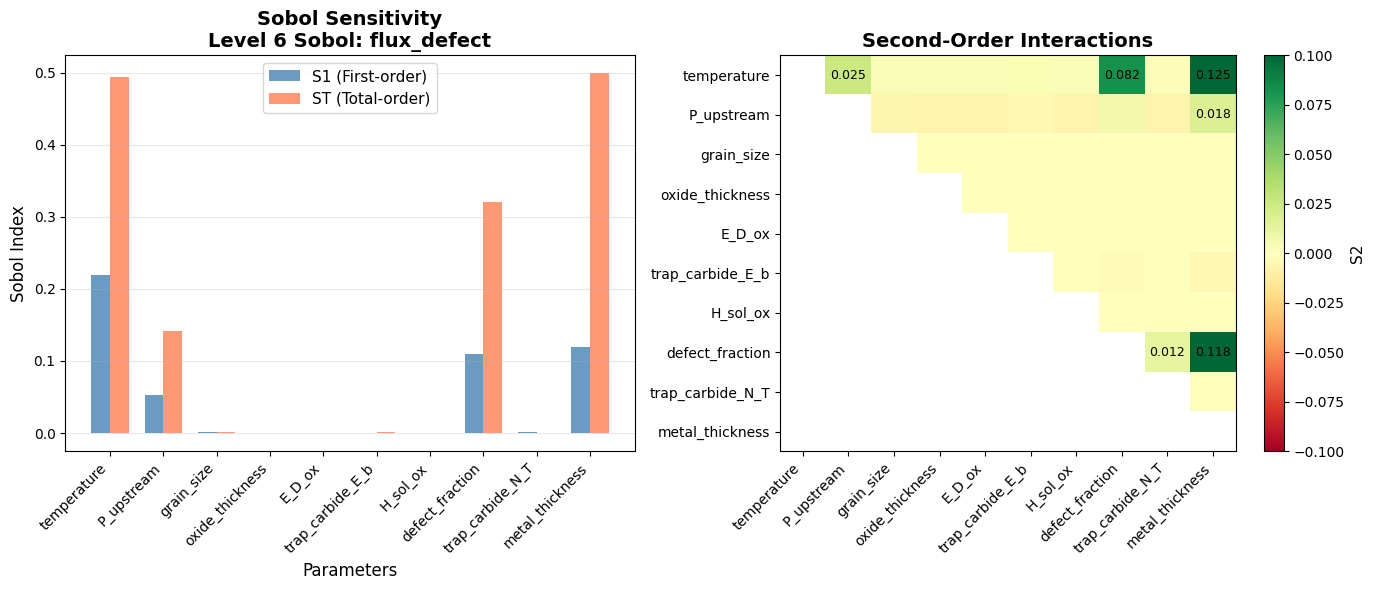


SOBOL SENSITIVITY RESULTS - Level 6 Sobol: flux_defect
       Parameter        S1  S1_conf       ST  ST_conf  Interactions
     temperature  0.219510 0.063797 0.494326 0.119059      0.274816
      P_upstream  0.052120 0.030055 0.141708 0.045707      0.089588
      grain_size  0.001528 0.002437 0.001582 0.001283      0.000054
 oxide_thickness  0.000000 0.000000 0.000000 0.000000      0.000000
          E_D_ox  0.000000 0.000000 0.000000 0.000000      0.000000
trap_carbide_E_b -0.000375 0.003815 0.001796 0.000702      0.002170
        H_sol_ox  0.000000 0.000000 0.000000 0.000000      0.000000
 defect_fraction  0.110007 0.040021 0.319951 0.104031      0.209944
trap_carbide_N_T  0.001017 0.001898 0.000269 0.000114     -0.000748
 metal_thickness  0.119256 0.082020 0.498856 0.148472      0.379600

Interpretation:
  S1 : First-order effect (direct influence)
  ST : Total-order effect (direct + interactions)
  ST-S1 : Pure interaction effects

Top 3 Most Influential Parameters:
  metal_thick

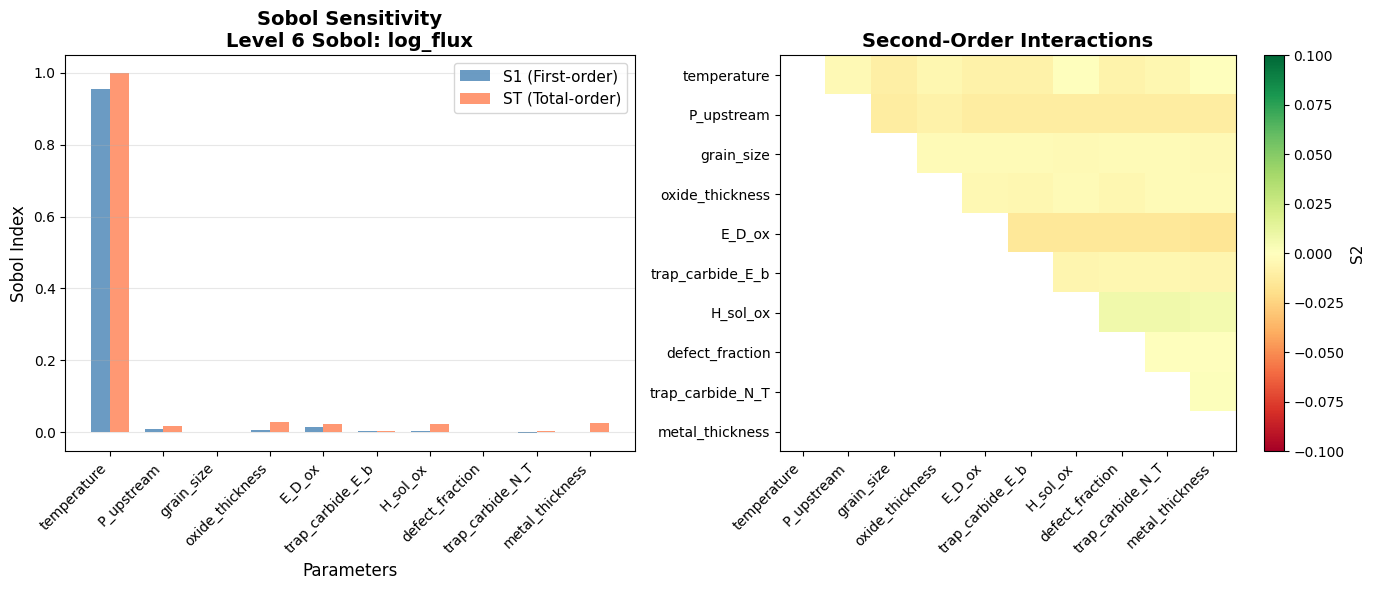


SOBOL SENSITIVITY RESULTS - Level 6 Sobol: log_flux
       Parameter        S1  S1_conf       ST      ST_conf  Interactions
     temperature  0.955871 0.064219 0.998888 6.377896e-02      0.043017
      P_upstream  0.009975 0.011328 0.016661 8.214591e-03      0.006686
      grain_size  0.000608 0.001129 0.000879 1.703775e-03      0.000271
 oxide_thickness  0.006073 0.014263 0.028569 9.252754e-03      0.022496
          E_D_ox  0.015328 0.013562 0.021341 8.312861e-03      0.006013
trap_carbide_E_b  0.004150 0.003833 0.003060 3.017402e-03     -0.001089
        H_sol_ox  0.002603 0.012981 0.023285 9.360177e-03      0.020682
 defect_fraction -0.000010 0.000114 0.000002 2.213986e-07      0.000012
trap_carbide_N_T -0.003372 0.004450 0.001989 2.417493e-03      0.005361
 metal_thickness  0.000168 0.013741 0.024553 9.174671e-03      0.024385

Interpretation:
  S1 : First-order effect (direct influence)
  ST : Total-order effect (direct + interactions)
  ST-S1 : Pure interaction effects

Top 3 M

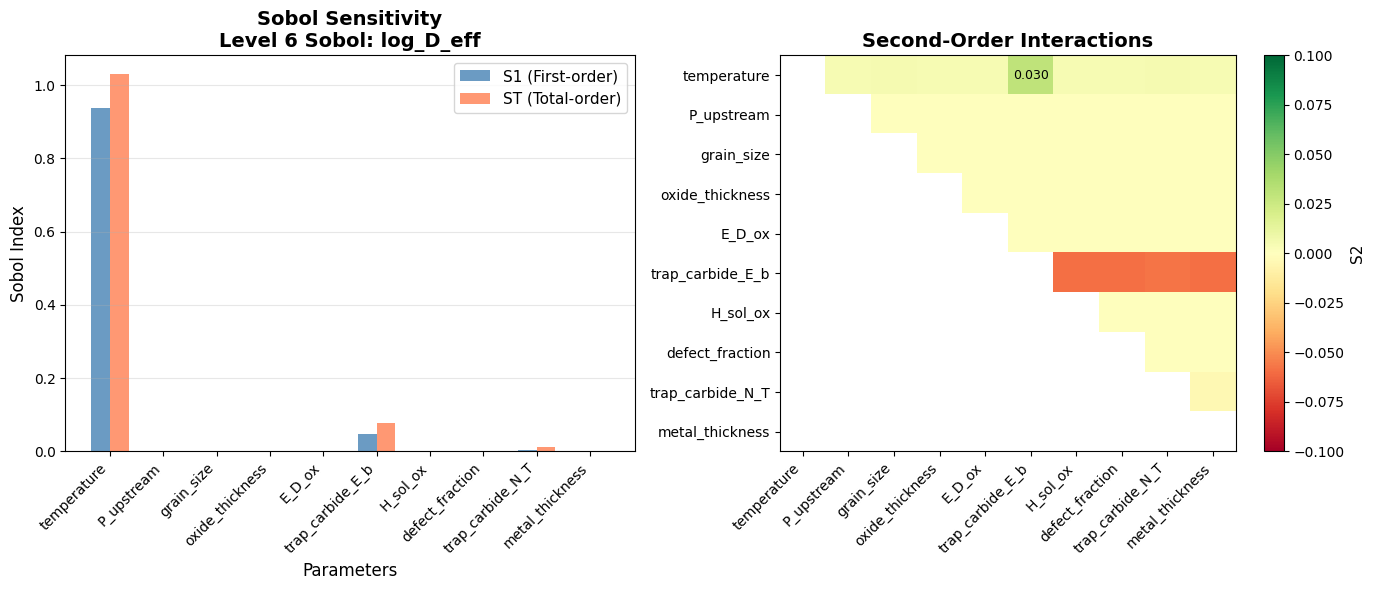


SOBOL SENSITIVITY RESULTS - Level 6 Sobol: log_D_eff
       Parameter       S1  S1_conf       ST  ST_conf  Interactions
     temperature 0.937185 0.082765 1.029631 0.073286      0.092445
      P_upstream 0.000000 0.000000 0.000000 0.000000      0.000000
      grain_size 0.001376 0.002420 0.001309 0.000748     -0.000067
 oxide_thickness 0.000000 0.000000 0.000000 0.000000      0.000000
          E_D_ox 0.000000 0.000000 0.000000 0.000000      0.000000
trap_carbide_E_b 0.047393 0.026395 0.077142 0.016815      0.029749
        H_sol_ox 0.000000 0.000000 0.000000 0.000000      0.000000
 defect_fraction 0.000000 0.000000 0.000000 0.000000      0.000000
trap_carbide_N_T 0.002490 0.009084 0.010866 0.003372      0.008376
 metal_thickness 0.000000 0.000000 0.000000 0.000000      0.000000

Interpretation:
  S1 : First-order effect (direct influence)
  ST : Total-order effect (direct + interactions)
  ST-S1 : Pure interaction effects

Top 3 Most Influential Parameters:
  temperature: ST = 1.030 

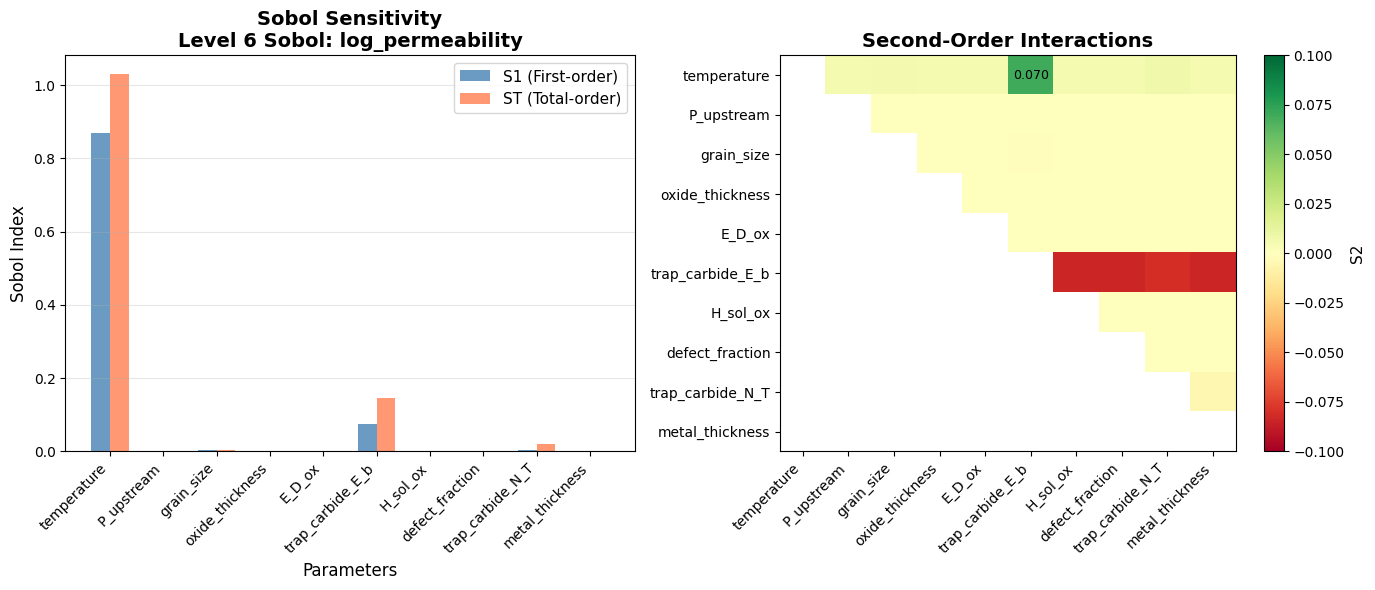


SOBOL SENSITIVITY RESULTS - Level 6 Sobol: log_permeability
       Parameter       S1  S1_conf       ST  ST_conf  Interactions
     temperature 0.868257 0.089268 1.029631 0.090250      0.161374
      P_upstream 0.000000 0.000000 0.000000 0.000000      0.000000
      grain_size 0.002573 0.003500 0.002491 0.001440     -0.000081
 oxide_thickness 0.000000 0.000000 0.000000 0.000000      0.000000
          E_D_ox 0.000000 0.000000 0.000000 0.000000      0.000000
trap_carbide_E_b 0.074806 0.038194 0.146827 0.031531      0.072021
        H_sol_ox 0.000000 0.000000 0.000000 0.000000      0.000000
 defect_fraction 0.000000 0.000000 0.000000 0.000000      0.000000
trap_carbide_N_T 0.004248 0.012184 0.020682 0.006465      0.016434
 metal_thickness 0.000000 0.000000 0.000000 0.000000      0.000000

Interpretation:
  S1 : First-order effect (direct influence)
  ST : Total-order effect (direct + interactions)
  ST-S1 : Pure interaction effects

Top 3 Most Influential Parameters:
  temperature: ST =

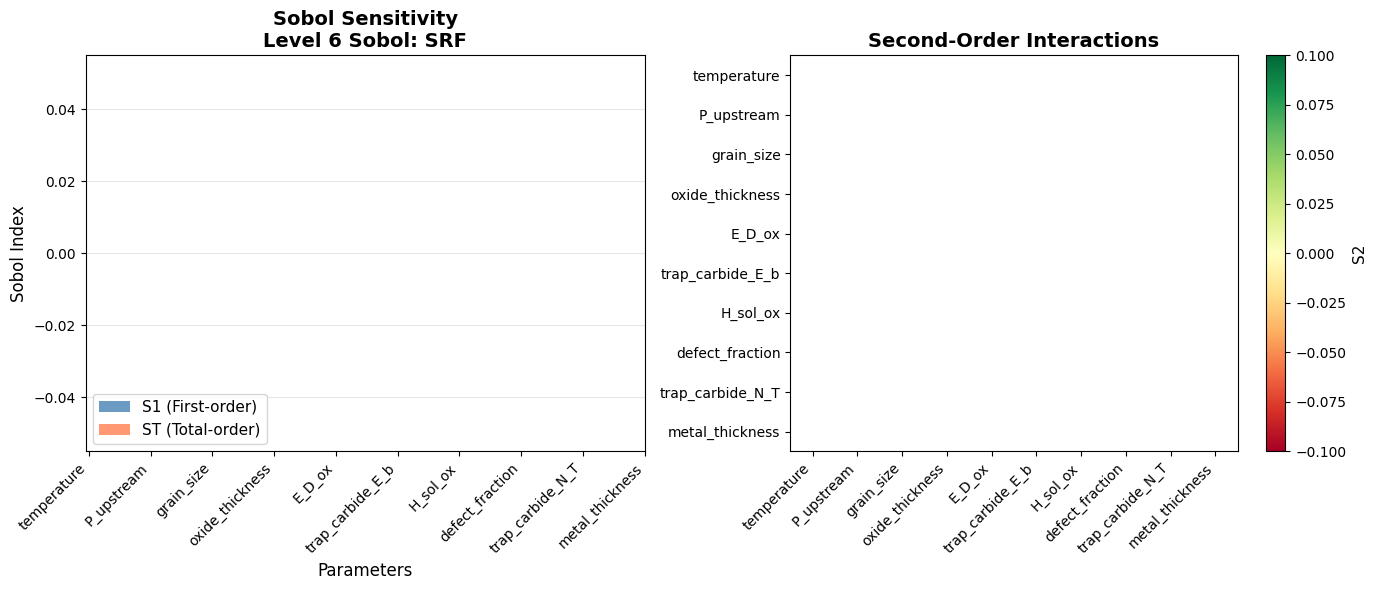


SOBOL SENSITIVITY RESULTS - Level 6 Sobol: SRF
       Parameter  S1  S1_conf  ST  ST_conf  Interactions
     temperature NaN      NaN NaN      NaN           NaN
      P_upstream NaN      NaN NaN      NaN           NaN
      grain_size NaN      NaN NaN      NaN           NaN
 oxide_thickness NaN      NaN NaN      NaN           NaN
          E_D_ox NaN      NaN NaN      NaN           NaN
trap_carbide_E_b NaN      NaN NaN      NaN           NaN
        H_sol_ox NaN      NaN NaN      NaN           NaN
 defect_fraction NaN      NaN NaN      NaN           NaN
trap_carbide_N_T NaN      NaN NaN      NaN           NaN
 metal_thickness NaN      NaN NaN      NaN           NaN

Interpretation:
  S1 : First-order effect (direct influence)
  ST : Total-order effect (direct + interactions)
  ST-S1 : Pure interaction effects

Top 3 Most Influential Parameters:
  temperature: ST = nan (S1 = nan)
  P_upstream: ST = nan (S1 = nan)
  grain_size: ST = nan (S1 = nan)


OUTPUT: theta


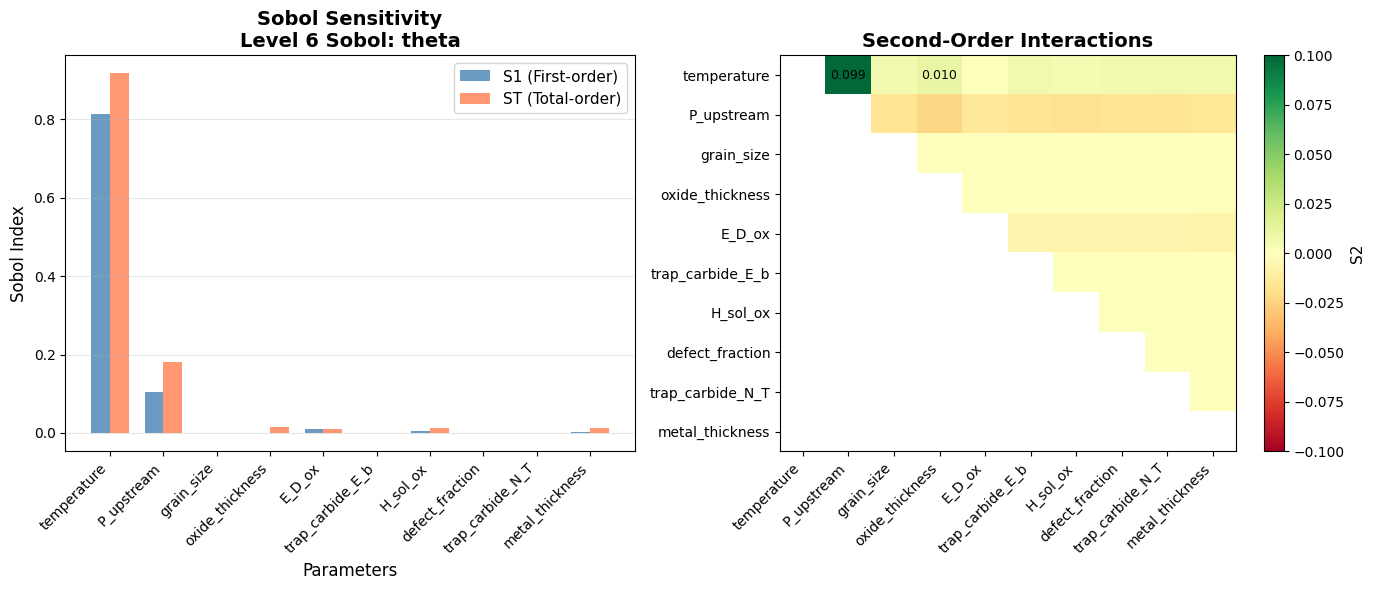


SOBOL SENSITIVITY RESULTS - Level 6 Sobol: theta
       Parameter            S1      S1_conf           ST      ST_conf  Interactions
     temperature  8.130399e-01 7.077883e-02 9.173340e-01 8.188658e-02  1.042941e-01
      P_upstream  1.037091e-01 5.320830e-02 1.818521e-01 2.576088e-02  7.814296e-02
      grain_size -2.275909e-04 4.500330e-04 1.616201e-04 3.195834e-04  3.892110e-04
 oxide_thickness -1.640844e-04 9.639887e-03 1.415359e-02 8.643851e-03  1.431767e-02
          E_D_ox  9.273221e-03 8.008368e-03 1.095312e-02 6.577070e-03  1.679900e-03
trap_carbide_E_b  2.831223e-04 1.308764e-03 5.307263e-04 1.001811e-03  2.476040e-04
        H_sol_ox  4.415434e-03 8.837939e-03 1.363908e-02 8.585940e-03  9.223644e-03
 defect_fraction  3.844440e-09 7.377056e-09 7.351913e-15 1.406335e-14 -3.844433e-09
trap_carbide_N_T -1.121205e-03 1.507836e-03 3.351416e-04 4.654079e-04  1.456346e-03
 metal_thickness  2.132896e-03 1.149365e-02 1.375140e-02 7.828513e-03  1.161850e-02

Interpretation:
  S1 : Fi

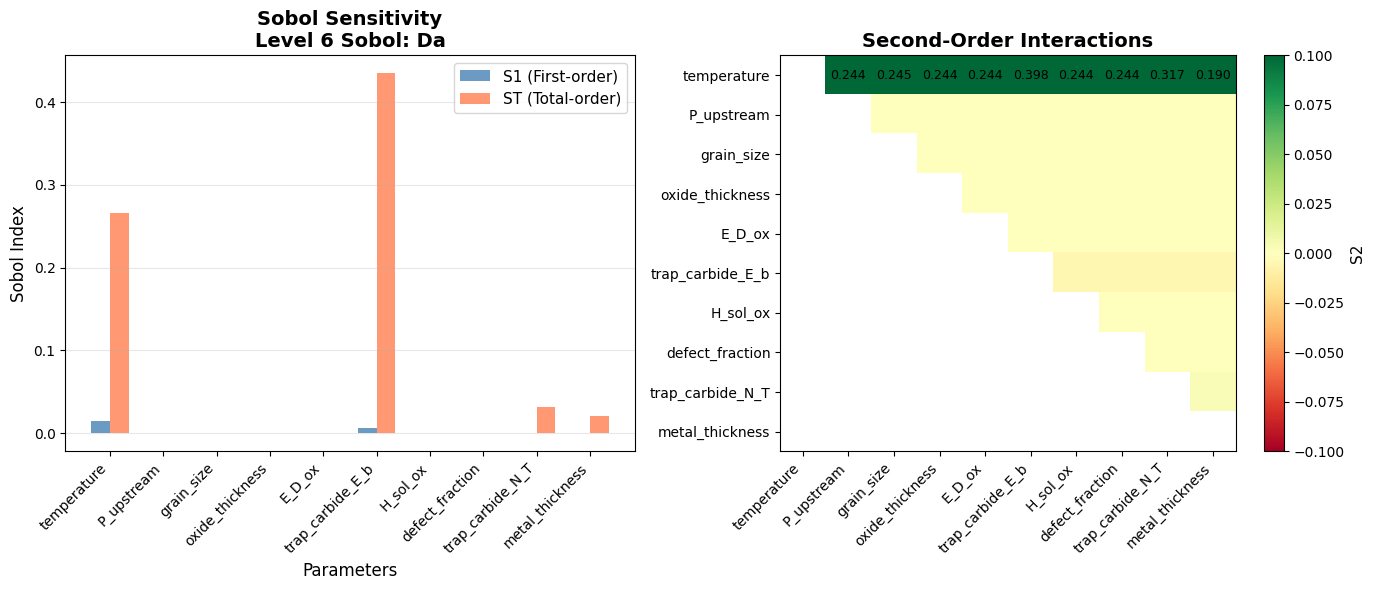


SOBOL SENSITIVITY RESULTS - Level 6 Sobol: Da
       Parameter        S1  S1_conf       ST  ST_conf  Interactions
     temperature  0.014863 0.044120 0.265421 0.660597      0.250558
      P_upstream  0.000000 0.000000 0.000000 0.000000      0.000000
      grain_size  0.000004 0.000109 0.000050 0.000221      0.000047
 oxide_thickness  0.000000 0.000000 0.000000 0.000000      0.000000
          E_D_ox  0.000000 0.000000 0.000000 0.000000      0.000000
trap_carbide_E_b  0.005943 0.035246 0.434721 1.983345      0.428778
        H_sol_ox  0.000000 0.000000 0.000000 0.000000      0.000000
 defect_fraction  0.000000 0.000000 0.000000 0.000000      0.000000
trap_carbide_N_T -0.000369 0.001587 0.030875 0.082507      0.031244
 metal_thickness -0.000007 0.003867 0.020539 0.112476      0.020546

Interpretation:
  S1 : First-order effect (direct influence)
  ST : Total-order effect (direct + interactions)
  ST-S1 : Pure interaction effects

Top 3 Most Influential Parameters:
  trap_carbide_E_b: ST

In [21]:
# =============================================================================
# PLOT SOBOL RESULTS FOR ALL OUTPUTS
# =============================================================================

for output_metric in VALID_OUTPUT_METRICS_L5L6:
    print(f"\n{'='*70}")
    print(f"OUTPUT: {output_metric}")
    print(f"{'='*70}")
    
    Si = sobol_results[output_metric]['Si']
    problem = sobol_results[output_metric]['problem']
    
    plot_sobol_results(Si, problem, f'Level 6 Sobol: {output_metric}')